# 02 _ EDA and Business Analysis

**Project:** Corporacion Favorita Store Sales Forecasting  
**Project type:** Data Science / MLOps Portfolio Project  
**Notebook:** `notebooks/02_eda_business_analysis.ipynb`

---

## 1.Purpose

This notebook explores historical sales behavior to identify demand patterns relevant for short-term store replenishment forecasting.

The analysis translates cleaned data into business findings about temporal demand, stores, product families, promotions, holidays, oil prices, transactions, and anomaly patterns.


# 2.Notebook Objective

The objective of this notebook is to build a clear analytical and business understanding of the demand patterns that matter before feature engineering and model training.

The notebook will:

- Analyze historical sales trends and seasonality.
- Identify store-level and family-level demand concentration.
- Review the relationship between promotions and sales.
- Explore holiday, event, oil price, and transaction signals.
- Detect anomaly candidates and operational risk areas.
- Save figures, tables, summaries, and modeling implications for later notebooks.


# 3.Scope.

## Scope.

This notebook uses the cleaned datasets generated by notebook 01.

It includes:

- Historical sales trend analysis.
- Calendar and seasonality analysis.
- Store-level demand analysis.
- Product family demand analysis.
- Promotion analysis.
- Holiday and event analysis.
- Oil price exploratory analysis.
- Transaction exploratory analysis.
- Anomaly and outlier review.
- Business findings and modeling implications.

It does not include:

- Advanced feature engineering.
- Lag or rolling feature creation.
- Train-validation split.
- Model training.
- LightGBM or Prophet modeling.
- MLflow tracking.
- API or Docker development.


# 4.Imports and Path Setup

This section imports the required libraries, detects the project root, defines input/output paths, and configures plotting defaults.

The EDA reads from `data/interim/` and `data/processed/`, then writes tables, figures, and summaries under `reports/eda_business_analysis/`.


In [ ]:
from pathlib import Path
from datetime import datetime
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)

SEED = 42
np.random.seed(SEED)

# Plot settings
sns.set_theme(style="whitegrid", context="notebook")

# Project root

def find_project_root(start_path=None, required_dirs=("data", "notebooks", "reports")):
    """Find the project root by walking upward from the current directory."""
    current_path = Path.cwd() if start_path is None else Path(start_path)
    current_path = current_path.resolve()

    for candidate_path in [current_path, *current_path.parents]:
        if all((candidate_path / directory).exists() for directory in required_dirs):
            return candidate_path

    raise FileNotFoundError(
        "Project root could not be detected. "
        f"Expected a parent directory containing: {required_dirs}. "
        f"Current working directory: {current_path}"
    )


PROJECT_ROOT = find_project_root()

# Data directories
DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

# Report directories
REPORTS_DIR = PROJECT_ROOT / "reports"
EDA_DIR = REPORTS_DIR / "eda_business_analysis"
EDA_TABLES_DIR = EDA_DIR / "tables"
EDA_FIGURES_DIR = EDA_DIR / "figures"
EDA_SUMMARIES_DIR = EDA_DIR / "summaries"

for directory in [
    EDA_DIR,
    EDA_TABLES_DIR,
    EDA_FIGURES_DIR,
    EDA_SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

dependency_versions = pd.DataFrame(
    [
        {"package": "pandas", "version": pd.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "matplotlib", "version": plt.matplotlib.__version__},
        {"package": "seaborn", "version": sns.__version__},
    ]
)

display(dependency_versions)

print(f"Project root: {PROJECT_ROOT}")
print(f"Interim data directory: {INTERIM_DIR}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"EDA reports directory: {EDA_DIR}")


# 5.Setup and Input Validation

This section validates that the cleaned datasets generated by the previous notebook are available before starting the exploratory business analysis.

The EDA will mainly use the processed base tables:

- `train_base.parquet`
- `test_base.parquet`

Additional cleaned tables will be used for complementary analysis:

- `transactions_clean.parquet`
- `stores_clean.parquet`
- `oil_daily_clean.parquet`
- `holidays_daily_clean.parquet`

Transactions will be treated as historical-only information because they are not directly available for the future forecasting period.


In [2]:
expected_input_files = [
    {
        "file_name": "train_base.parquet",
        "expected_location": "data/processed",
        "path": PROCESSED_DIR / "train_base.parquet",
        "required_for": "main EDA table",
    },
    {
        "file_name": "test_base.parquet",
        "expected_location": "data/processed",
        "path": PROCESSED_DIR / "test_base.parquet",
        "required_for": "future horizon structure review",
    },
    {
        "file_name": "transactions_clean.parquet",
        "expected_location": "data/interim",
        "path": INTERIM_DIR / "transactions_clean.parquet",
        "required_for": "historical transactions analysis",
    },
    {
        "file_name": "stores_clean.parquet",
        "expected_location": "data/interim",
        "path": INTERIM_DIR / "stores_clean.parquet",
        "required_for": "store-level metadata review",
    },
    {
        "file_name": "oil_daily_clean.parquet",
        "expected_location": "data/interim",
        "path": INTERIM_DIR / "oil_daily_clean.parquet",
        "required_for": "oil price contextual analysis",
    },
    {
        "file_name": "holidays_daily_clean.parquet",
        "expected_location": "data/interim",
        "path": INTERIM_DIR / "holidays_daily_clean.parquet",
        "required_for": "holiday and event analysis",
    },
]

input_validation_rows = []

for file_info in expected_input_files:
    file_path = file_info["path"]
    exists = file_path.exists()

    input_validation_rows.append(
        {
            "file_name": file_info["file_name"],
            "expected_location": file_info["expected_location"],
            "exists": exists,
            "file_size_mb": (
                round(file_path.stat().st_size / (1024**2), 2) if exists else None
            ),
            "required_for": file_info["required_for"],
            "path": str(file_path),
        }
    )

eda_input_validation_summary = pd.DataFrame(input_validation_rows)

display(eda_input_validation_summary)

eda_input_validation_summary.to_csv(
    EDA_TABLES_DIR / "eda_input_validation_summary.csv",
    index=False,
)

missing_files = eda_input_validation_summary.loc[
    ~eda_input_validation_summary["exists"], "file_name"
].tolist()

if missing_files:
    raise FileNotFoundError("Missing required input files: " + ", ".join(missing_files))

print("All required input files are available.")


,file_name,expected_location,exists,file_size_mb,required_for,path
0,train_base.parquet,data/processed,True,21.42,main EDA table,....
1,test_base.parquet,data/processed,True,0.20,future horizon structure review,....
2,transactions_clean.parquet,data/interim,True,0.17,historical transactions analysis,....
3,stores_clean.parquet,data/interim,True,0.00,store-level metadata review,....
4,oil_daily_clean.parquet,data/interim,True,0.02,oil price contextual analysis,....
5,holidays_daily_clean.parquet,data/interim,True,0.03,holiday and event analysis,....


All required input files are available.


In [3]:
train_base = pd.read_parquet(PROCESSED_DIR / "train_base.parquet")
test_base = pd.read_parquet(PROCESSED_DIR / "test_base.parquet")

transactions_clean = pd.read_parquet(INTERIM_DIR / "transactions_clean.parquet")
stores_clean = pd.read_parquet(INTERIM_DIR / "stores_clean.parquet")
oil_daily_clean = pd.read_parquet(INTERIM_DIR / "oil_daily_clean.parquet")
holidays_daily_clean = pd.read_parquet(INTERIM_DIR / "holidays_daily_clean.parquet")

datasets = {
    "train_base": train_base,
    "test_base": test_base,
    "transactions_clean": transactions_clean,
    "stores_clean": stores_clean,
    "oil_daily_clean": oil_daily_clean,
    "holidays_daily_clean": holidays_daily_clean,
}

dataset_overview_rows = []

for dataset_name, dataset in datasets.items():
    date_min = dataset["date"].min() if "date" in dataset.columns else None
    date_max = dataset["date"].max() if "date" in dataset.columns else None

    dataset_overview_rows.append(
        {
            "dataset": dataset_name,
            "rows": len(dataset),
            "columns": dataset.shape[1],
            "date_min": date_min,
            "date_max": date_max,
            "memory_mb": round(dataset.memory_usage(deep=True).sum() / (1024**2), 2),
        }
    )

eda_dataset_overview_summary = pd.DataFrame(dataset_overview_rows)

display(eda_dataset_overview_summary)

eda_dataset_overview_summary.to_csv(
    EDA_TABLES_DIR / "eda_dataset_overview_summary.csv",
    index=False,
)


,dataset,rows,columns,date_min,date_max,memory_mb
0,train_base,3000888,30,2013-01-01,2017-08-15,645.40
1,test_base,28512,29,2017-08-16,2017-08-31,5.91
2,transactions_clean,83488,3,2013-01-01,2017-08-15,1.91
3,stores_clean,54,5,NaT,NaT,0.00
4,oil_daily_clean,1704,5,2013-01-01,2017-08-31,0.03
5,holidays_daily_clean,1704,17,2013-01-01,2017-08-31,0.19


### Business conclusion

The required cleaned datasets are available and the EDA can start from a reproducible data foundation.

The main analytical table is `train_base`, while `test_base` will be used only to understand the future prediction structure. Transactions are loaded for historical business analysis, but they must not be treated as directly available future information.


# 6.Dataset Overview for Business Analysis

This section summarizes the analytical structure of the forecasting problem from a business perspective.

The main grain of the problem is expected to be:

`date + store_nbr + family`

This means that each row should represent the daily sales of one product family in one store.

The objective of this section is to understand:

- the historical period available for analysis;
- the future forecasting horizon;
- the number of stores and product families;
- the sales and promotion coverage;
- whether the dataset structure is consistent with a store replenishment forecasting problem.


In [4]:
# Ensure date columns are correctly typed
for dataset in [train_base, test_base]:
    if "date" in dataset.columns:
        dataset["date"] = pd.to_datetime(dataset["date"])

required_train_columns = ["date", "store_nbr", "family", "sales", "onpromotion"]
required_test_columns = ["date", "store_nbr", "family", "onpromotion"]

missing_train_columns = [
    col for col in required_train_columns if col not in train_base.columns
]
missing_test_columns = [
    col for col in required_test_columns if col not in test_base.columns
]

if missing_train_columns:
    raise ValueError(f"Missing required columns in train_base: {missing_train_columns}")

if missing_test_columns:
    raise ValueError(f"Missing required columns in test_base: {missing_test_columns}")

sales_overview_summary = pd.DataFrame(
    [
        {
            "dataset": "train_base",
            "rows": len(train_base),
            "date_min": train_base["date"].min(),
            "date_max": train_base["date"].max(),
            "unique_dates": train_base["date"].nunique(),
            "unique_stores": train_base["store_nbr"].nunique(),
            "unique_families": train_base["family"].nunique(),
            "total_sales": train_base["sales"].sum(),
            "mean_sales_per_row": train_base["sales"].mean(),
            "median_sales_per_row": train_base["sales"].median(),
            "max_sales_per_row": train_base["sales"].max(),
            "zero_sales_rows": (train_base["sales"] == 0).sum(),
            "zero_sales_pct": (train_base["sales"] == 0).mean(),
            "rows_with_promotion": (train_base["onpromotion"] > 0).sum(),
            "rows_with_promotion_pct": (train_base["onpromotion"] > 0).mean(),
            "total_promotion_units": train_base["onpromotion"].sum(),
        },
        {
            "dataset": "test_base",
            "rows": len(test_base),
            "date_min": test_base["date"].min(),
            "date_max": test_base["date"].max(),
            "unique_dates": test_base["date"].nunique(),
            "unique_stores": test_base["store_nbr"].nunique(),
            "unique_families": test_base["family"].nunique(),
            "total_sales": np.nan,
            "mean_sales_per_row": np.nan,
            "median_sales_per_row": np.nan,
            "max_sales_per_row": np.nan,
            "zero_sales_rows": np.nan,
            "zero_sales_pct": np.nan,
            "rows_with_promotion": (test_base["onpromotion"] > 0).sum(),
            "rows_with_promotion_pct": (test_base["onpromotion"] > 0).mean(),
            "total_promotion_units": test_base["onpromotion"].sum(),
        },
    ]
)

display(sales_overview_summary)

sales_overview_summary.to_csv(
    EDA_TABLES_DIR / "sales_overview_summary.csv",
    index=False,
)


,dataset,rows,date_min,date_max,unique_dates,unique_stores,unique_families,total_sales,mean_sales_per_row,median_sales_per_row,max_sales_per_row,zero_sales_rows,zero_sales_pct,rows_with_promotion,rows_with_promotion_pct,total_promotion_units
0,train_base,3000888,2013-01-01,2017-08-15,1684,54,33,1.073645e+09,357.775749,11.0,124717.0,939130.0,0.312951,611329,0.203716,7810622
1,test_base,28512,2017-08-16,2017-08-31,16,54,33,NaN,NaN,NaN,NaN,NaN,NaN,12569,0.440832,198597


In [5]:
grain_columns = ["date", "store_nbr", "family"]

train_duplicate_grain_rows = train_base.duplicated(grain_columns).sum()
test_duplicate_grain_rows = test_base.duplicated(grain_columns).sum()

train_expected_rows_from_observed_grid = (
    train_base["date"].nunique()
    * train_base["store_nbr"].nunique()
    * train_base["family"].nunique()
)

test_expected_rows_from_observed_grid = (
    test_base["date"].nunique()
    * test_base["store_nbr"].nunique()
    * test_base["family"].nunique()
)

grain_validation_summary = pd.DataFrame(
    [
        {
            "dataset": "train_base",
            "grain": "date + store_nbr + family",
            "actual_rows": len(train_base),
            "expected_rows_from_observed_grid": train_expected_rows_from_observed_grid,
            "duplicate_grain_rows": train_duplicate_grain_rows,
            "is_balanced_observed_grid": len(train_base)
            == train_expected_rows_from_observed_grid,
        },
        {
            "dataset": "test_base",
            "grain": "date + store_nbr + family",
            "actual_rows": len(test_base),
            "expected_rows_from_observed_grid": test_expected_rows_from_observed_grid,
            "duplicate_grain_rows": test_duplicate_grain_rows,
            "is_balanced_observed_grid": len(test_base)
            == test_expected_rows_from_observed_grid,
        },
    ]
)

display(grain_validation_summary)

grain_validation_summary.to_csv(
    EDA_TABLES_DIR / "grain_validation_summary.csv",
    index=False,
)


,dataset,grain,actual_rows,expected_rows_from_observed_grid,duplicate_grain_rows,is_balanced_observed_grid
0,train_base,date + store_nbr + family,3000888,3000888,0,True
1,test_base,date + store_nbr + family,28512,28512,0,True


In [6]:
future_horizon_summary = pd.DataFrame(
    [
        {
            "forecast_start_date": test_base["date"].min(),
            "forecast_end_date": test_base["date"].max(),
            "forecast_horizon_days": test_base["date"].nunique(),
            "future_rows": len(test_base),
            "future_stores": test_base["store_nbr"].nunique(),
            "future_families": test_base["family"].nunique(),
            "future_rows_with_promotion": (test_base["onpromotion"] > 0).sum(),
            "future_rows_with_promotion_pct": (test_base["onpromotion"] > 0).mean(),
            "future_total_promotion_units": test_base["onpromotion"].sum(),
        }
    ]
)

display(future_horizon_summary)

future_horizon_summary.to_csv(
    EDA_TABLES_DIR / "future_horizon_summary.csv",
    index=False,
)


,forecast_start_date,forecast_end_date,forecast_horizon_days,future_rows,future_stores,future_families,future_rows_with_promotion,future_rows_with_promotion_pct,future_total_promotion_units
0,2017-08-16,2017-08-31,16,28512,54,33,12569,0.440832,198597


In [7]:
business_dimension_rows = []

dimension_candidates = {
    "city": ["city"],
    "state": ["state"],
    "store_type": ["store_type", "type"],
    "cluster": ["cluster"],
    "family": ["family"],
}

for dimension_name, possible_columns in dimension_candidates.items():
    available_column = next(
        (column for column in possible_columns if column in train_base.columns), None
    )

    if available_column is not None:
        business_dimension_rows.append(
            {
                "dimension": dimension_name,
                "source_column": available_column,
                "unique_values": train_base[available_column].nunique(),
                "top_values": ", ".join(
                    train_base[available_column]
                    .value_counts()
                    .head(5)
                    .index.astype(str)
                ),
            }
        )

business_dimension_summary = pd.DataFrame(business_dimension_rows)

display(business_dimension_summary)

business_dimension_summary.to_csv(
    EDA_TABLES_DIR / "business_dimension_summary.csv",
    index=False,
)


,dimension,source_column,unique_values,top_values
0,city,city,22,"Quito, Guayaquil, Santo Domingo, Cuenca, Latac..."
1,state,state,16,"Pichincha, Guayas, Santo Domingo de los Tsachi..."
2,store_type,store_type,5,"D, C, A, B, E"
3,cluster,cluster,17,"3, 6, 10, 15, 13"
4,family,family,33,"AUTOMOTIVE, BABY CARE, BEAUTY, BEVERAGES, BOOKS"


### Business conclusion

The forecasting problem is structured as a daily store-family demand prediction task.

The historical dataset provides sales observations at the `date + store_nbr + family` level, while the test dataset represents a 16-day future horizon with the same operational granularity.

This confirms that the business problem is not only about forecasting total sales, but about supporting replenishment decisions across many store and product-family combinations.

Promotions are available in both historical and future data, which makes them a strong candidate for future modeling. Transactions, however, remain historical-only and must be handled carefully to avoid leakage.


# 7.Historical Sales Trend

This section analyzes the historical evolution of total sales over time.

The objective is to identify long-term trends, relevant demand shifts, seasonality, abnormal peaks, and periods of lower commercial activity.

For a store replenishment problem, this step helps determine whether future demand can be reasonably estimated from recent historical behavior or whether the system must account for strong temporal variation.


In [8]:
# Daily sales aggregation
daily_sales = train_base.groupby("date", as_index=False).agg(
    total_sales=("sales", "sum"),
    mean_sales_per_row=("sales", "mean"),
    median_sales_per_row=("sales", "median"),
    max_sales_per_row=("sales", "max"),
    total_promotion_units=("onpromotion", "sum"),
    rows_with_promotion=("onpromotion", lambda x: (x > 0).sum()),
    zero_sales_rows=("sales", lambda x: (x == 0).sum()),
    total_rows=("sales", "size"),
)

daily_sales["rows_with_promotion_pct"] = (
    daily_sales["rows_with_promotion"] / daily_sales["total_rows"]
)

daily_sales["zero_sales_pct"] = (
    daily_sales["zero_sales_rows"] / daily_sales["total_rows"]
)

# Weekly sales aggregation
weekly_sales = (
    daily_sales.set_index("date")
    .resample("W")
    .agg(
        total_sales=("total_sales", "sum"),
        mean_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        total_promotion_units=("total_promotion_units", "sum"),
        mean_rows_with_promotion_pct=("rows_with_promotion_pct", "mean"),
        mean_zero_sales_pct=("zero_sales_pct", "mean"),
    )
    .reset_index()
)

# Monthly sales aggregation
monthly_sales = (
    daily_sales.set_index("date")
    .resample("MS")
    .agg(
        total_sales=("total_sales", "sum"),
        mean_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        total_promotion_units=("total_promotion_units", "sum"),
        mean_rows_with_promotion_pct=("rows_with_promotion_pct", "mean"),
        mean_zero_sales_pct=("zero_sales_pct", "mean"),
    )
    .reset_index()
)

daily_sales.to_csv(
    EDA_TABLES_DIR / "daily_sales_summary.csv",
    index=False,
)

weekly_sales.to_csv(
    EDA_TABLES_DIR / "weekly_sales_summary.csv",
    index=False,
)

monthly_sales.to_csv(
    EDA_TABLES_DIR / "monthly_sales_summary.csv",
    index=False,
)

display(daily_sales.head())
display(weekly_sales.head())
display(monthly_sales.head())


,date,total_sales,mean_sales_per_row,median_sales_per_row,max_sales_per_row,total_promotion_units,rows_with_promotion,zero_sales_rows,total_rows,rows_with_promotion_pct,zero_sales_pct
0,2013-01-01,2511.618999,1.409438,0.0,810.0,0,0,1765,1782,0.0,0.990460
1,2013-01-02,496092.417944,278.390807,0.0,11422.0,0,0,918,1782,0.0,0.515152
2,2013-01-03,361461.231124,202.840197,0.0,7342.0,0,0,931,1782,0.0,0.522447
3,2013-01-04,354459.677093,198.911154,0.0,7527.0,0,0,923,1782,0.0,0.517957
4,2013-01-05,477350.121229,267.873244,0.0,10827.0,0,0,905,1782,0.0,0.507856


,date,total_sales,mean_daily_sales,median_daily_sales,total_promotion_units,mean_rows_with_promotion_pct,mean_zero_sales_pct
0,2013-01-06,2.211570e+06,368595.077913,419405.676176,0,0.0,0.598017
1,2013-01-13,2.373618e+06,339088.262315,318347.777981,0,0.0,0.521324
2,2013-01-20,2.368007e+06,338286.775721,299129.549954,0,0.0,0.523729
3,2013-01-27,2.272165e+06,324594.952871,296214.728983,0,0.0,0.527818
4,2013-02-03,2.476891e+06,353841.524461,285460.169953,0,0.0,0.523008


,date,total_sales,mean_daily_sales,median_daily_sales,total_promotion_units,mean_rows_with_promotion_pct,mean_zero_sales_pct
0,2013-01-01,1.032762e+07,333149.185062,302530.809018,0,0.0,0.538721
1,2013-02-01,9.658960e+06,344962.849194,319883.406937,0,0.0,0.522848
2,2013-03-01,1.142850e+07,368661.194758,332189.993189,0,0.0,0.508472
3,2013-04-01,1.099346e+07,366448.824600,334211.199495,0,0.0,0.502394
4,2013-05-01,1.159770e+07,374119.484098,335937.441949,0,0.0,0.495257


In [9]:
historical_sales_trend_summary = pd.DataFrame(
    [
        {
            "metric": "historical_start_date",
            "value": daily_sales["date"].min(),
        },
        {
            "metric": "historical_end_date",
            "value": daily_sales["date"].max(),
        },
        {
            "metric": "historical_days",
            "value": daily_sales["date"].nunique(),
        },
        {
            "metric": "total_historical_sales",
            "value": daily_sales["total_sales"].sum(),
        },
        {
            "metric": "mean_daily_sales",
            "value": daily_sales["total_sales"].mean(),
        },
        {
            "metric": "median_daily_sales",
            "value": daily_sales["total_sales"].median(),
        },
        {
            "metric": "max_daily_sales",
            "value": daily_sales["total_sales"].max(),
        },
        {
            "metric": "min_daily_sales",
            "value": daily_sales["total_sales"].min(),
        },
        {
            "metric": "mean_daily_zero_sales_pct",
            "value": daily_sales["zero_sales_pct"].mean(),
        },
        {
            "metric": "mean_daily_promotion_rows_pct",
            "value": daily_sales["rows_with_promotion_pct"].mean(),
        },
    ]
)

display(historical_sales_trend_summary)

historical_sales_trend_summary.to_csv(
    EDA_TABLES_DIR / "historical_sales_trend_summary.csv",
    index=False,
)


,metric,value
0,historical_start_date,2013-01-01 00:00:00
1,historical_end_date,2017-08-15 00:00:00
2,historical_days,1684
3,total_historical_sales,1073644952.203069
4,mean_daily_sales,637556.384919
5,median_daily_sales,632188.86392
6,max_daily_sales,1463083.962459
7,min_daily_sales,2511.618999
8,mean_daily_zero_sales_pct,0.312951
9,mean_daily_promotion_rows_pct,0.203716


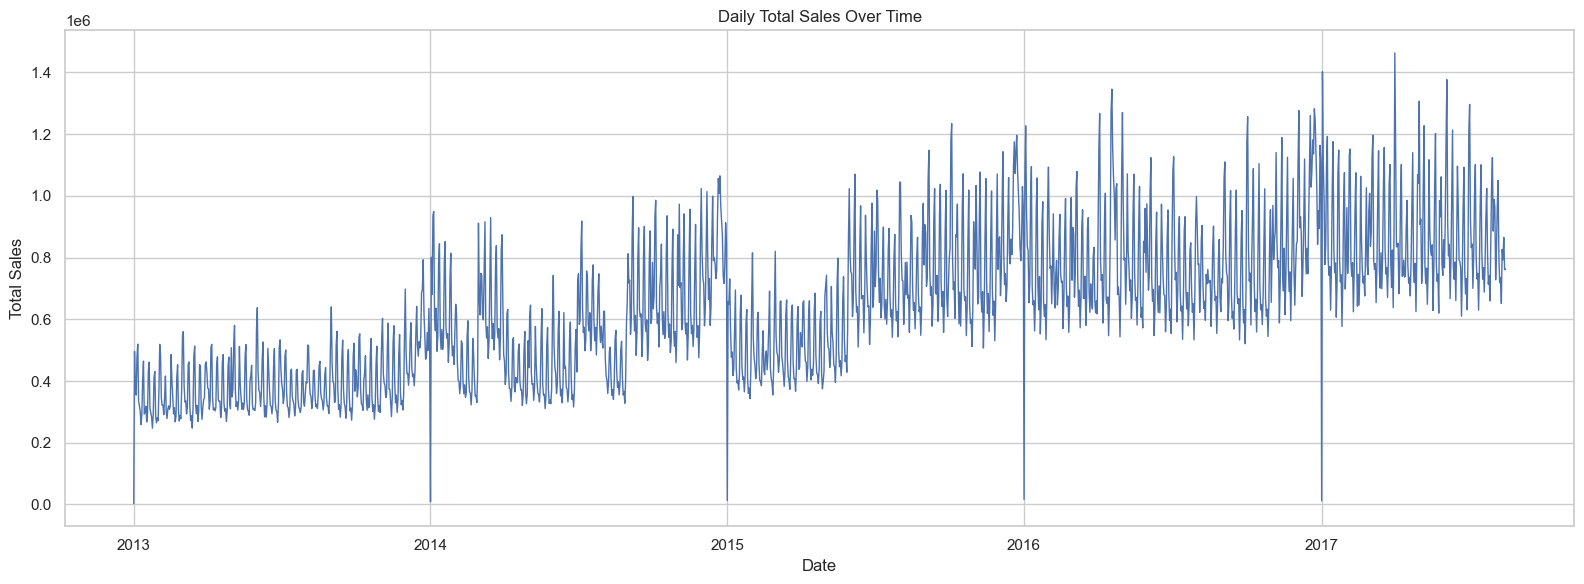

In [10]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=daily_sales,
    x="date",
    y="total_sales",
    linewidth=1,
)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_trend.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


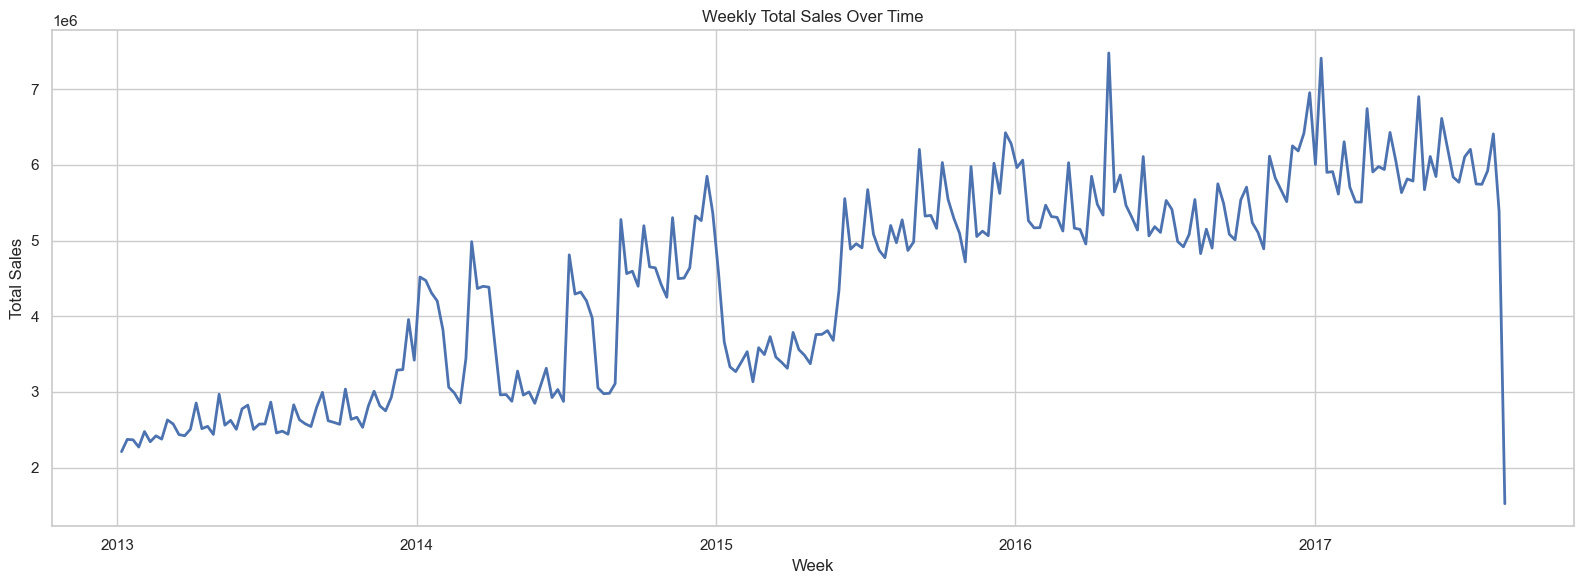

In [11]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=weekly_sales,
    x="date",
    y="total_sales",
    linewidth=2,
)

plt.title("Weekly Total Sales Over Time")
plt.xlabel("Week")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "weekly_sales_trend.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


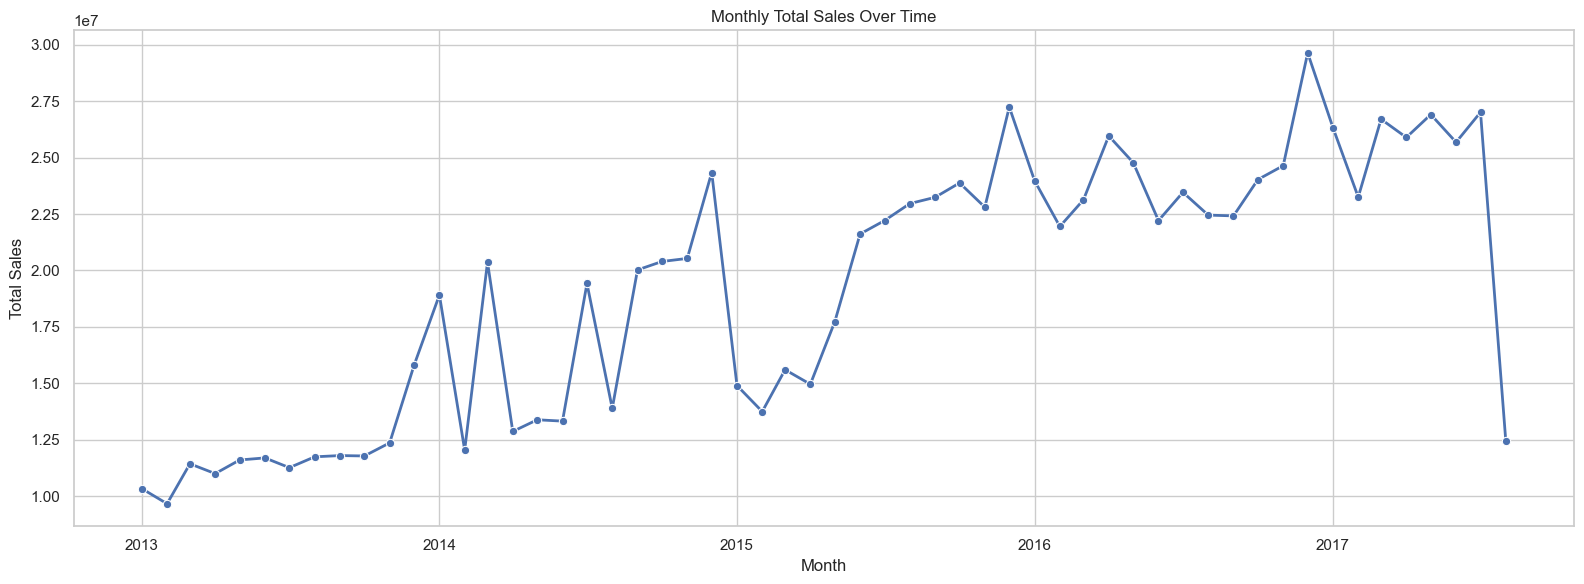

In [12]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_sales,
    x="date",
    y="total_sales",
    marker="o",
    linewidth=2,
)

plt.title("Monthly Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "monthly_sales_trend.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [13]:
monthly_sales_completeness = (
    daily_sales.assign(
        year=daily_sales["date"].dt.year,
        month=daily_sales["date"].dt.month,
        year_month=daily_sales["date"].dt.to_period("M").astype(str),
    )
    .groupby(["year", "month", "year_month"], as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        total_sales=("total_sales", "sum"),
        mean_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        total_promotion_units=("total_promotion_units", "sum"),
        mean_zero_sales_pct=("zero_sales_pct", "mean"),
    )
)

monthly_sales_completeness["calendar_days_in_month"] = pd.to_datetime(
    monthly_sales_completeness["year_month"]
).dt.days_in_month

monthly_sales_completeness["is_complete_month"] = (
    monthly_sales_completeness["observed_days"]
    == monthly_sales_completeness["calendar_days_in_month"]
)

display(monthly_sales_completeness.tail(12))

monthly_sales_completeness.to_csv(
    EDA_TABLES_DIR / "monthly_sales_completeness_summary.csv",
    index=False,
)


,year,month,year_month,observed_days,total_sales,mean_daily_sales,median_daily_sales,total_promotion_units,mean_zero_sales_pct,calendar_days_in_month,is_complete_month
44,2016,9,2016-09,30,2.241745e+07,747248.269900,686535.971721,296361,0.204153,30,True
45,2016,10,2016-10,31,2.403039e+07,775173.865042,710456.424002,370514,0.196553,31,True
46,2016,11,2016-11,30,2.464264e+07,821421.339913,782019.559934,438358,0.184287,30,True
47,2016,12,2016-12,30,2.964029e+07,988009.585980,942040.049890,517498,0.161392,31,False
48,2017,1,2017-01,31,2.632816e+07,849295.481797,782656.024672,363428,0.183972,31,True
49,2017,2,2017-02,28,2.325011e+07,830361.156248,779657.182581,297254,0.160514,28,True
50,2017,3,2017-03,31,2.670402e+07,861419.925512,812306.774270,339291,0.152873,31,True
51,2017,4,2017-04,30,2.589531e+07,863176.949652,793779.103378,371042,0.144426,30,True
52,2017,5,2017-05,31,2.691185e+07,868124.104858,807803.895078,414646,0.130499,31,True
53,2017,6,2017-06,30,2.568282e+07,856094.070833,793131.264900,394582,0.142181,30,True


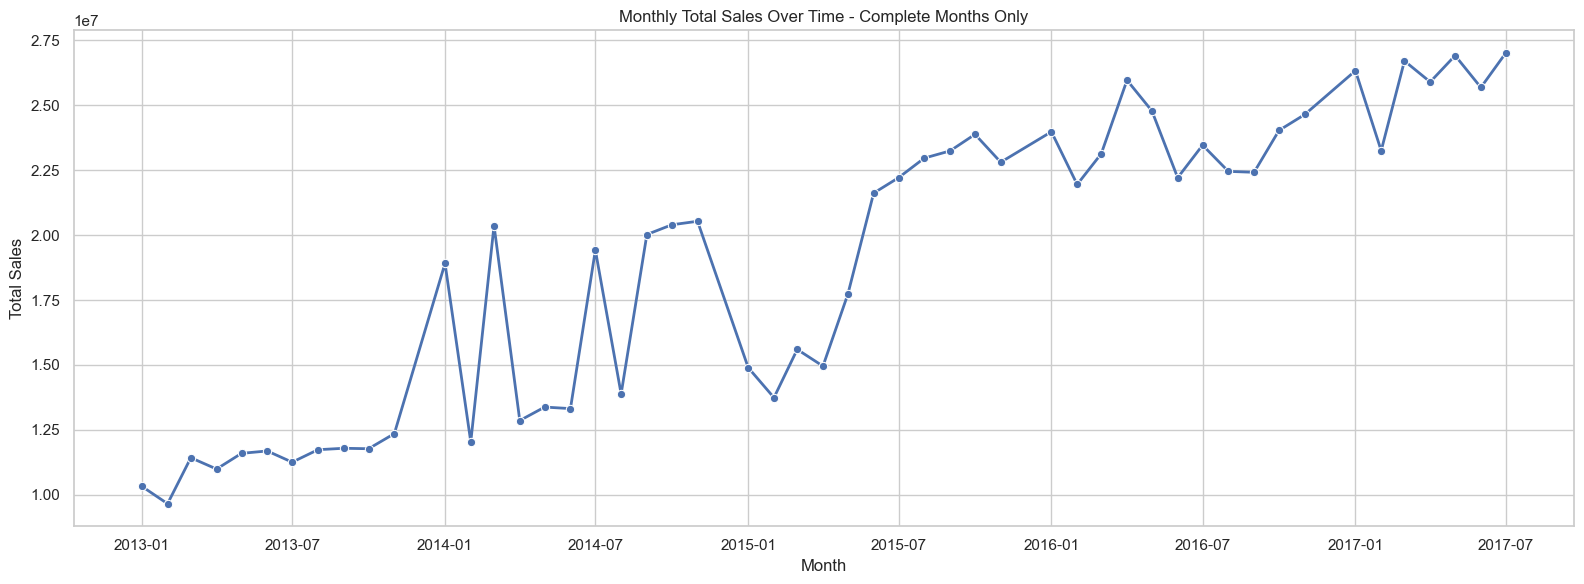

In [14]:
complete_monthly_sales = monthly_sales_completeness.loc[
    monthly_sales_completeness["is_complete_month"]
].copy()

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=complete_monthly_sales,
    x=pd.to_datetime(complete_monthly_sales["year_month"]),
    y="total_sales",
    marker="o",
    linewidth=2,
)

plt.title("Monthly Total Sales Over Time - Complete Months Only")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "monthly_sales_trend_complete_months_only.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [15]:
top_sales_days = (
    daily_sales.sort_values("total_sales", ascending=False)
    .head(15)
    .loc[
        :,
        [
            "date",
            "total_sales",
            "total_promotion_units",
            "rows_with_promotion_pct",
            "zero_sales_pct",
        ],
    ]
)

lowest_sales_days = (
    daily_sales.sort_values("total_sales", ascending=True)
    .head(15)
    .loc[
        :,
        [
            "date",
            "total_sales",
            "total_promotion_units",
            "rows_with_promotion_pct",
            "zero_sales_pct",
        ],
    ]
)

top_sales_days.to_csv(
    EDA_TABLES_DIR / "top_sales_days.csv",
    index=False,
)

lowest_sales_days.to_csv(
    EDA_TABLES_DIR / "lowest_sales_days.csv",
    index=False,
)

display(top_sales_days)
display(lowest_sales_days)


,date,total_sales,total_promotion_units,rows_with_promotion_pct,zero_sales_pct
1547,2017-04-01,1.463084e+06,7450,0.400673,0.156004
1458,2017-01-02,1.402306e+06,11812,0.479798,0.135802
1611,2017-06-04,1.376512e+06,10512,0.439955,0.119529
1200,2016-04-18,1.345921e+06,4075,0.322110,0.173401
1577,2017-05-01,1.306699e+06,12733,0.497755,0.109428
1639,2017-07-02,1.296379e+06,13882,0.451178,0.115600
1449,2016-12-23,1.282146e+06,21531,0.533109,0.152076
1430,2016-12-04,1.276195e+06,15186,0.466330,0.141414
1199,2016-04-17,1.271834e+06,4986,0.314815,0.191919
1213,2016-05-01,1.270121e+06,12056,0.383838,0.175084


,date,total_sales,total_promotion_units,rows_with_promotion_pct,zero_sales_pct
0,2013-01-01,2511.618999,0,0.000000,0.990460
364,2014-01-01,8602.065404,0,0.000000,0.971942
1457,2017-01-01,12082.500997,170,0.008418,0.984287
728,2015-01-01,12773.616980,12,0.002806,0.987093
1092,2016-01-01,16433.394000,159,0.005612,0.983726
23,2013-01-24,247245.690995,0,0.000000,0.528620
72,2013-03-14,247541.420096,0,0.000000,0.516835
9,2013-01-10,258982.003049,0,0.000000,0.518519
28,2013-01-29,264488.818077,0,0.000000,0.524130
177,2013-06-27,266525.458966,0,0.000000,0.498316


### Business conclusion

Historical sales show a clear upward trend from 2013 to 2017, which means that future replenishment forecasts should not rely only on long-term static averages.

Daily sales are highly volatile, with recurrent demand peaks above one million total sales. These peaks are operationally relevant because underestimating them could increase stockout risk.

The lowest-sales days are mainly January 1st observations, where most store-family combinations report zero sales. These days should be interpreted as calendar or operational closure effects, not as regular demand behavior.

The apparent decline at the end of the weekly and monthly charts is caused by the incomplete August 2017 training period. It should not be interpreted as a structural demand drop.

Overall, demand forecasting for replenishment must account for trend, calendar effects, promotions, and exceptional low-activity days.


# 8.Seasonality and Calendar Patterns

This section analyzes recurring calendar patterns in historical sales.

The objective is to understand whether demand changes systematically by day of week, month, or year.

For store replenishment, calendar patterns are important because they can create predictable demand pressure even before considering promotions, holidays, or store-specific behavior.


In [16]:
daily_sales_calendar = daily_sales.copy()

daily_sales_calendar["year"] = daily_sales_calendar["date"].dt.year
daily_sales_calendar["month"] = daily_sales_calendar["date"].dt.month
daily_sales_calendar["month_name"] = daily_sales_calendar["date"].dt.month_name()
daily_sales_calendar["day_of_week"] = daily_sales_calendar["date"].dt.day_name()
daily_sales_calendar["day_of_week_num"] = daily_sales_calendar["date"].dt.dayofweek
daily_sales_calendar["is_year_start"] = (daily_sales_calendar["date"].dt.month == 1) & (
    daily_sales_calendar["date"].dt.day == 1
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

display(daily_sales_calendar.head())


,date,total_sales,mean_sales_per_row,median_sales_per_row,max_sales_per_row,total_promotion_units,rows_with_promotion,zero_sales_rows,total_rows,rows_with_promotion_pct,zero_sales_pct,year,month,month_name,day_of_week,day_of_week_num,is_year_start
0,2013-01-01,2511.618999,1.409438,0.0,810.0,0,0,1765,1782,0.0,0.990460,2013,1,January,Tuesday,1,True
1,2013-01-02,496092.417944,278.390807,0.0,11422.0,0,0,918,1782,0.0,0.515152,2013,1,January,Wednesday,2,False
2,2013-01-03,361461.231124,202.840197,0.0,7342.0,0,0,931,1782,0.0,0.522447,2013,1,January,Thursday,3,False
3,2013-01-04,354459.677093,198.911154,0.0,7527.0,0,0,923,1782,0.0,0.517957,2013,1,January,Friday,4,False
4,2013-01-05,477350.121229,267.873244,0.0,10827.0,0,0,905,1782,0.0,0.507856,2013,1,January,Saturday,5,False


In [17]:
day_of_week_sales_summary = (
    daily_sales_calendar.loc[~daily_sales_calendar["is_year_start"]]
    .groupby(["day_of_week_num", "day_of_week"], as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        mean_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        min_daily_sales=("total_sales", "min"),
        max_daily_sales=("total_sales", "max"),
        mean_promotion_rows_pct=("rows_with_promotion_pct", "mean"),
        mean_zero_sales_pct=("zero_sales_pct", "mean"),
    )
    .sort_values("day_of_week_num")
)

display(day_of_week_sales_summary)

day_of_week_sales_summary.to_csv(
    EDA_TABLES_DIR / "day_of_week_sales_summary.csv",
    index=False,
)


,day_of_week_num,day_of_week,observed_days,mean_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,mean_promotion_rows_pct,mean_zero_sales_pct
0,0,Monday,241,617542.713052,651800.509461,278627.588926,1.402306e+06,0.188489,0.310172
1,1,Tuesday,241,572280.504806,603427.946974,264488.818077,1.152089e+06,0.193260,0.311872
2,2,Wednesday,239,595690.756351,633413.890570,281061.127052,1.196146e+06,0.215080,0.312277
3,3,Thursday,239,507329.852094,532423.558194,247245.690995,1.135849e+06,0.200802,0.314247
4,4,Friday,239,581930.599441,626674.025055,285679.869131,1.282146e+06,0.236420,0.313561
5,5,Saturday,241,772205.593943,816064.644983,403258.212011,1.463084e+06,0.200358,0.297377
6,6,Sunday,239,828620.362670,865639.677471,300951.328993,1.376512e+06,0.196038,0.317285


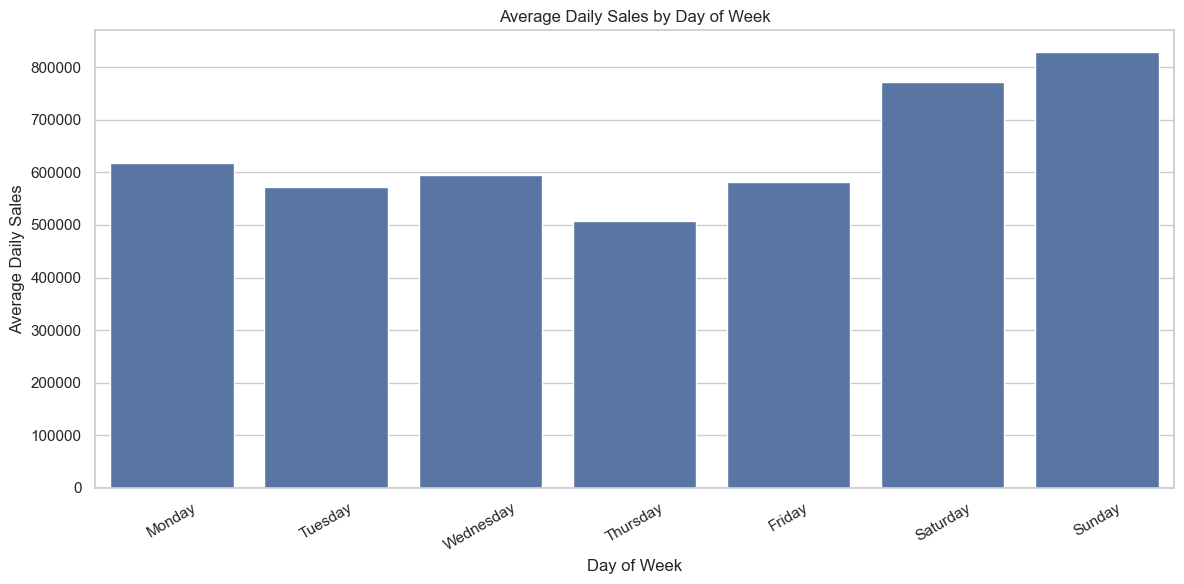

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=day_of_week_sales_summary,
    x="day_of_week",
    y="mean_daily_sales",
    order=day_order,
)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "average_sales_by_day_of_week.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


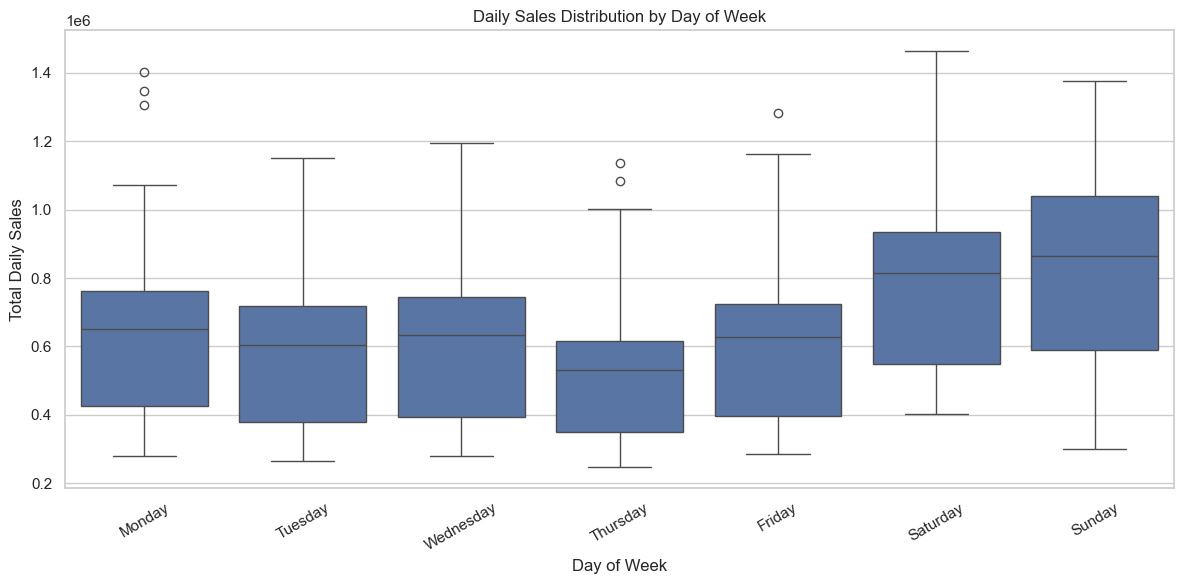

In [19]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=daily_sales_calendar.loc[~daily_sales_calendar["is_year_start"]],
    x="day_of_week",
    y="total_sales",
    order=day_order,
)

plt.title("Daily Sales Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Daily Sales")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_distribution_by_day_of_week.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [20]:
monthly_seasonality_summary = (
    daily_sales_calendar.loc[~daily_sales_calendar["is_year_start"]]
    .groupby(["month", "month_name"], as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        mean_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        min_daily_sales=("total_sales", "min"),
        max_daily_sales=("total_sales", "max"),
        mean_promotion_rows_pct=("rows_with_promotion_pct", "mean"),
        mean_zero_sales_pct=("zero_sales_pct", "mean"),
    )
    .sort_values("month")
)

display(monthly_seasonality_summary)

monthly_seasonality_summary.to_csv(
    EDA_TABLES_DIR / "monthly_seasonality_summary.csv",
    index=False,
)


,month,month_name,observed_days,mean_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,mean_promotion_rows_pct,mean_zero_sales_pct
0,1,January,150,629264.994135,604609.154444,247245.690995,1.402306e+06,0.176259,0.316988
1,2,February,141,571895.244225,530128.059914,267711.109015,1.151988e+06,0.165469,0.353125
2,3,March,155,627280.562239,622695.836995,247541.420096,1.196984e+06,0.163332,0.307929
3,4,April,150,604454.117050,522357.650030,268790.618996,1.463084e+06,0.189106,0.345387
4,5,May,155,609026.690473,573412.210160,289261.058026,1.306699e+06,0.231092,0.336584
5,6,June,150,630111.355279,637526.407289,266525.458966,1.376512e+06,0.237329,0.312679
6,7,July,155,666858.456059,654821.051531,281750.931023,1.296379e+06,0.238387,0.272894
7,8,August,139,600520.696680,625898.205888,294518.685943,1.049559e+06,0.210268,0.326397
8,9,September,120,645613.999338,641160.480437,273057.879859,1.147643e+06,0.203278,0.294987
9,10,October,124,645809.509319,627955.292988,276059.080002,1.256480e+06,0.201590,0.289875


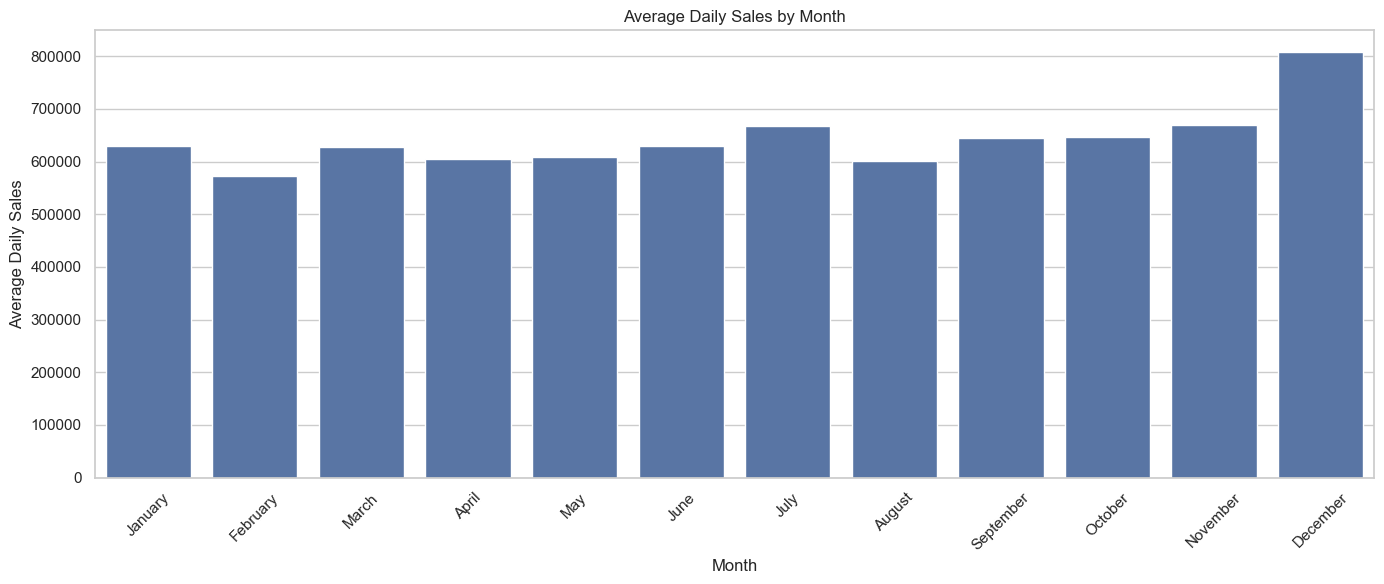

In [21]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=monthly_seasonality_summary,
    x="month_name",
    y="mean_daily_sales",
    order=month_order,
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "average_sales_by_month.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


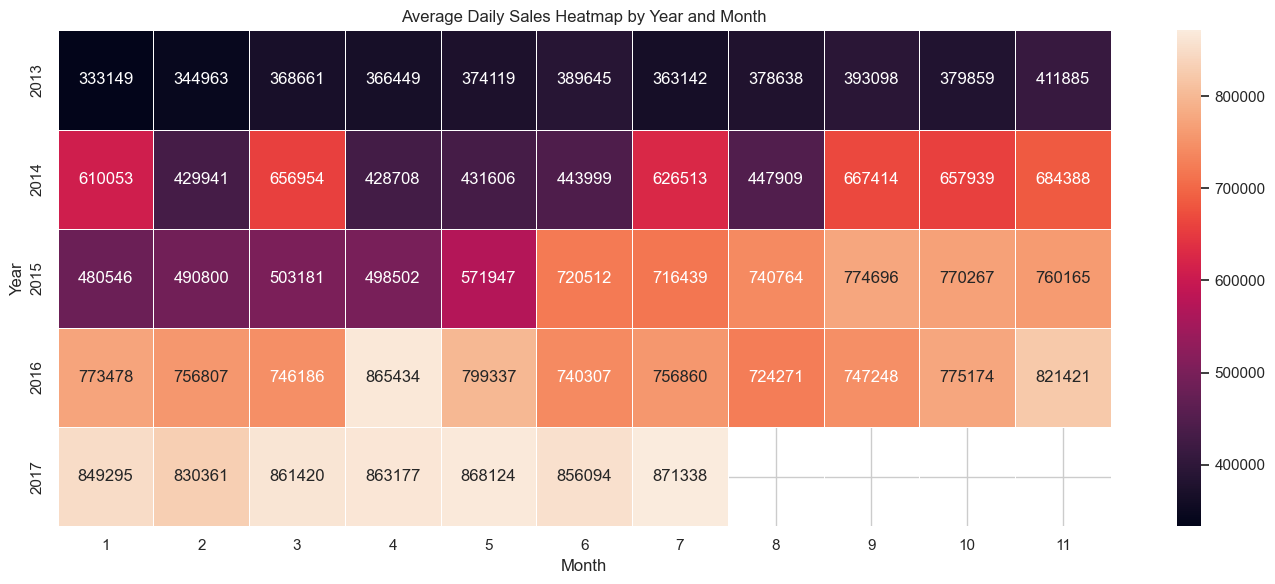

In [22]:
year_month_pivot = monthly_sales_completeness.loc[
    monthly_sales_completeness["is_complete_month"]
].pivot_table(
    index="year",
    columns="month",
    values="mean_daily_sales",
    aggfunc="mean",
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    year_month_pivot,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
)

plt.title("Average Daily Sales Heatmap by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "monthly_sales_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [23]:
calendar_pattern_summary = pd.DataFrame(
    [
        {
            "pattern": "highest_average_sales_day_of_week",
            "value": day_of_week_sales_summary.sort_values(
                "mean_daily_sales",
                ascending=False,
            ).iloc[0]["day_of_week"],
            "metric_value": day_of_week_sales_summary["mean_daily_sales"].max(),
        },
        {
            "pattern": "lowest_average_sales_day_of_week",
            "value": day_of_week_sales_summary.sort_values(
                "mean_daily_sales",
                ascending=True,
            ).iloc[0]["day_of_week"],
            "metric_value": day_of_week_sales_summary["mean_daily_sales"].min(),
        },
        {
            "pattern": "highest_average_sales_month",
            "value": monthly_seasonality_summary.sort_values(
                "mean_daily_sales",
                ascending=False,
            ).iloc[0]["month_name"],
            "metric_value": monthly_seasonality_summary["mean_daily_sales"].max(),
        },
        {
            "pattern": "lowest_average_sales_month",
            "value": monthly_seasonality_summary.sort_values(
                "mean_daily_sales",
                ascending=True,
            ).iloc[0]["month_name"],
            "metric_value": monthly_seasonality_summary["mean_daily_sales"].min(),
        },
        {
            "pattern": "year_start_days_excluded_from_seasonality",
            "value": int(daily_sales_calendar["is_year_start"].sum()),
            "metric_value": daily_sales_calendar.loc[
                daily_sales_calendar["is_year_start"],
                "zero_sales_pct",
            ].mean(),
        },
    ]
)

display(calendar_pattern_summary)

calendar_pattern_summary.to_csv(
    EDA_TABLES_DIR / "calendar_pattern_summary.csv",
    index=False,
)


,pattern,value,metric_value
0,highest_average_sales_day_of_week,Sunday,828620.362670
1,lowest_average_sales_day_of_week,Thursday,507329.852094
2,highest_average_sales_month,December,808565.339708
3,lowest_average_sales_month,February,571895.244225
4,year_start_days_excluded_from_seasonality,5,0.983502


# 9.Store-Level Demand Analysis

This section analyzes historical sales behavior at store level.

The objective is to identify which stores concentrate the highest demand, which stores are more volatile, and whether store metadata such as city, state, store type, or cluster helps explain demand differences.

For replenishment planning, store-level differences are critical because two stores may require very different inventory strategies even when selling the same product families.


In [24]:
store_type_column = None

for candidate_column in ["store_type", "type"]:
    if candidate_column in train_base.columns:
        store_type_column = candidate_column
        break

store_metadata_columns = ["store_nbr"]

for column in ["city", "state", store_type_column, "cluster"]:
    if column is not None and column in train_base.columns:
        store_metadata_columns.append(column)

store_metadata = (
    train_base[store_metadata_columns]
    .drop_duplicates()
    .sort_values("store_nbr")
    .reset_index(drop=True)
)

display(store_metadata.head())

store_metadata.to_csv(
    EDA_TABLES_DIR / "store_metadata_summary.csv",
    index=False,
)


,store_nbr,city,state,store_type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [25]:
store_daily_sales = train_base.groupby(["date", "store_nbr"], as_index=False).agg(
    total_sales=("sales", "sum"),
    mean_family_sales=("sales", "mean"),
    median_family_sales=("sales", "median"),
    max_family_sales=("sales", "max"),
    total_promotion_units=("onpromotion", "sum"),
    promoted_families=("onpromotion", lambda x: (x > 0).sum()),
    zero_sales_families=("sales", lambda x: (x == 0).sum()),
    total_families=("family", "nunique"),
)

store_daily_sales["promoted_families_pct"] = (
    store_daily_sales["promoted_families"] / store_daily_sales["total_families"]
)

store_daily_sales["zero_sales_families_pct"] = (
    store_daily_sales["zero_sales_families"] / store_daily_sales["total_families"]
)

store_daily_sales = store_daily_sales.merge(
    store_metadata,
    on="store_nbr",
    how="left",
)

display(store_daily_sales.head())

store_daily_sales.to_csv(
    EDA_TABLES_DIR / "store_daily_sales_summary.csv",
    index=False,
)


,date,store_nbr,total_sales,mean_family_sales,median_family_sales,max_family_sales,total_promotion_units,promoted_families,zero_sales_families,total_families,promoted_families_pct,zero_sales_families_pct,city,state,store_type,cluster
0,2013-01-01,1,0.0,0.0,0.0,0.0,0,0,33,33,0.0,1.0,Quito,Pichincha,D,13
1,2013-01-01,2,0.0,0.0,0.0,0.0,0,0,33,33,0.0,1.0,Quito,Pichincha,D,13
2,2013-01-01,3,0.0,0.0,0.0,0.0,0,0,33,33,0.0,1.0,Quito,Pichincha,D,8
3,2013-01-01,4,0.0,0.0,0.0,0.0,0,0,33,33,0.0,1.0,Quito,Pichincha,D,9
4,2013-01-01,5,0.0,0.0,0.0,0.0,0,0,33,33,0.0,1.0,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [26]:
store_sales_summary = store_daily_sales.groupby("store_nbr", as_index=False).agg(
    observed_days=("date", "nunique"),
    total_sales=("total_sales", "sum"),
    mean_daily_sales=("total_sales", "mean"),
    median_daily_sales=("total_sales", "median"),
    std_daily_sales=("total_sales", "std"),
    min_daily_sales=("total_sales", "min"),
    max_daily_sales=("total_sales", "max"),
    total_promotion_units=("total_promotion_units", "sum"),
    mean_promoted_families_pct=("promoted_families_pct", "mean"),
    mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
)

store_sales_summary["daily_sales_cv"] = (
    store_sales_summary["std_daily_sales"] / store_sales_summary["mean_daily_sales"]
)

store_sales_summary["sales_share_pct"] = (
    store_sales_summary["total_sales"] / store_sales_summary["total_sales"].sum()
)

store_sales_summary = store_sales_summary.merge(
    store_metadata,
    on="store_nbr",
    how="left",
)

store_sales_summary = store_sales_summary.sort_values(
    "total_sales",
    ascending=False,
).reset_index(drop=True)

display(store_sales_summary.head(15))

store_sales_summary.to_csv(
    EDA_TABLES_DIR / "store_sales_summary.csv",
    index=False,
)


,store_nbr,observed_days,total_sales,mean_daily_sales,median_daily_sales,std_daily_sales,min_daily_sales,max_daily_sales,total_promotion_units,mean_promoted_families_pct,mean_zero_sales_families_pct,daily_sales_cv,sales_share_pct,city,state,store_type,cluster
0,44,1684,6.208755e+07,36869.093379,35423.185000,14704.525437,0.0,90557.925090,192449,0.255668,0.179479,0.398831,0.057829,Quito,Pichincha,A,5
1,45,1684,5.449801e+07,32362.238965,30826.398010,13689.660271,0.0,114144.378000,191503,0.260221,0.193587,0.423013,0.050760,Quito,Pichincha,A,11
2,47,1684,5.094831e+07,30254.340891,28914.909500,12523.214939,0.0,75297.955500,192725,0.265134,0.189538,0.413931,0.047454,Quito,Pichincha,A,14
3,3,1684,5.048191e+07,29977.381345,29515.494500,11324.234287,0.0,69516.386030,177075,0.246869,0.181404,0.377759,0.047019,Quito,Pichincha,D,8
4,49,1684,4.342010e+07,25783.904860,26135.745500,11904.519735,0.0,65048.295000,184736,0.249478,0.193479,0.461704,0.040442,Quito,Pichincha,A,11
5,46,1684,4.189606e+07,24878.896747,22200.025980,11084.244855,0.0,72375.146000,190697,0.272007,0.193209,0.445528,0.039022,Quito,Pichincha,A,14
6,48,1684,3.593313e+07,21337.963346,18446.099500,10317.644670,0.0,62877.964000,185566,0.269848,0.213219,0.483535,0.033468,Quito,Pichincha,A,14
7,51,1684,3.291149e+07,19543.639868,19185.193998,6439.520989,0.0,41745.408956,162576,0.230476,0.201216,0.329494,0.030654,Guayaquil,Guayas,A,17
8,8,1684,3.049429e+07,18108.246394,17711.088485,6757.231185,0.0,41095.617000,169671,0.237998,0.199309,0.373158,0.028403,Quito,Pichincha,D,8
9,50,1684,2.865302e+07,17014.857853,16010.620998,6198.947027,0.0,43368.656000,174115,0.255074,0.206525,0.364326,0.026688,Ambato,Tungurahua,A,14


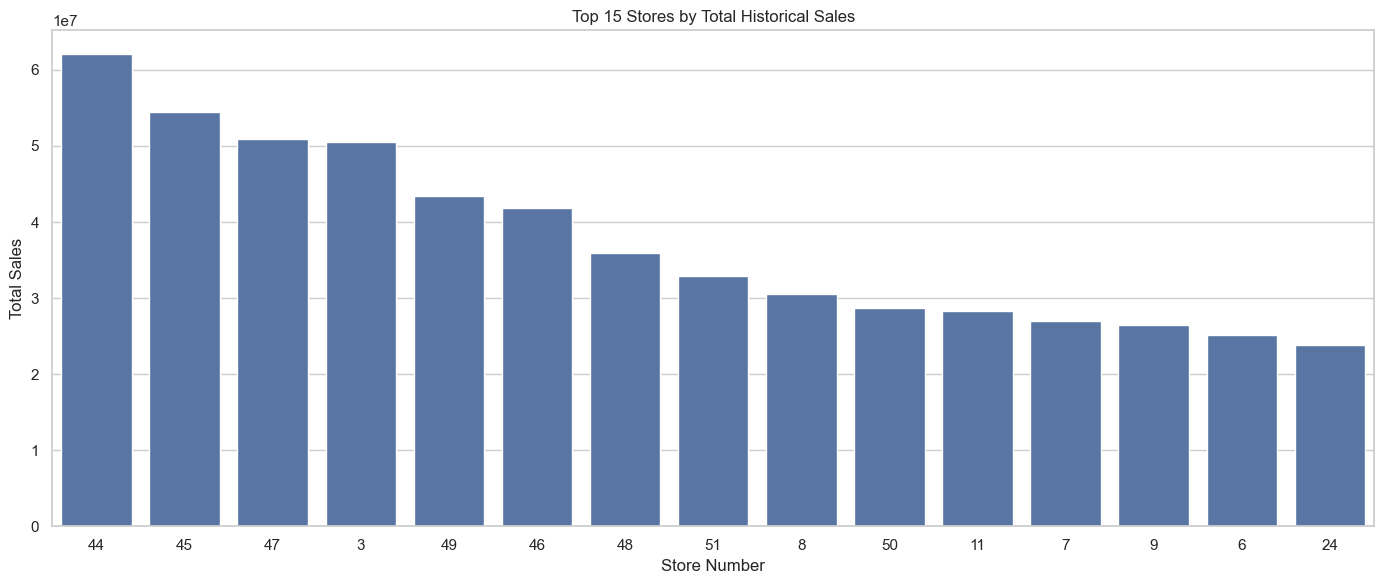

In [27]:
top_store_sales = store_sales_summary.head(15).copy()

plt.figure(figsize=(14, 6))

sns.barplot(
    data=top_store_sales,
    x="store_nbr",
    y="total_sales",
    order=top_store_sales["store_nbr"].astype(str),
)

plt.title("Top 15 Stores by Total Historical Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "top_15_stores_by_total_sales.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


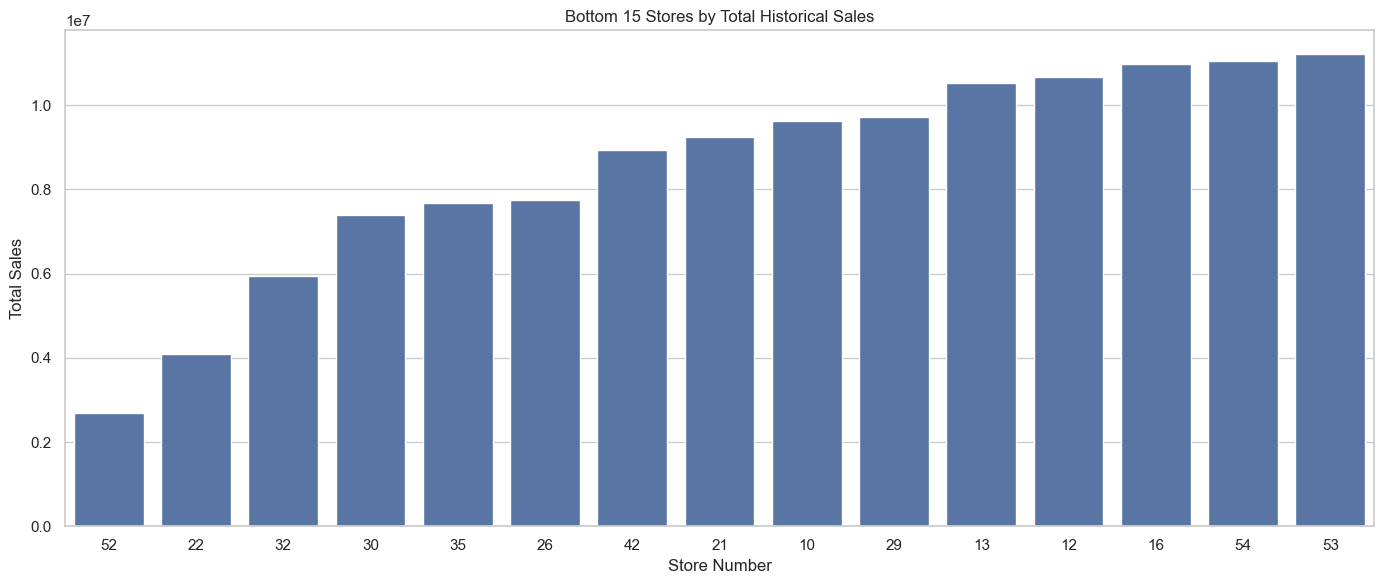

In [28]:
bottom_store_sales = (
    store_sales_summary.sort_values("total_sales", ascending=True).head(15).copy()
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=bottom_store_sales,
    x="store_nbr",
    y="total_sales",
    order=bottom_store_sales["store_nbr"].astype(str),
)

plt.title("Bottom 15 Stores by Total Historical Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "bottom_15_stores_by_total_sales.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [29]:
store_volatility_summary = (
    store_sales_summary.sort_values("daily_sales_cv", ascending=False)
    .loc[
        :,
        [
            "store_nbr",
            "total_sales",
            "mean_daily_sales",
            "std_daily_sales",
            "daily_sales_cv",
            "mean_promoted_families_pct",
            "mean_zero_sales_families_pct",
        ]
        + [
            column
            for column in ["city", "state", store_type_column, "cluster"]
            if column in store_sales_summary.columns
        ],
    ]
    .head(15)
)

display(store_volatility_summary)

store_volatility_summary.to_csv(
    EDA_TABLES_DIR / "store_volatility_summary.csv",
    index=False,
)


,store_nbr,total_sales,mean_daily_sales,std_daily_sales,daily_sales_cv,mean_promoted_families_pct,mean_zero_sales_families_pct,city,state,store_type,cluster
53,52,2.696170e+06,1601.050910,5984.923475,3.738122,0.035144,0.935399,Manta,Manabi,A,11
52,22,4.090202e+06,2428.860891,3168.574394,1.304552,0.133071,0.685489,Puyo,Pastaza,C,7
46,21,9.255506e+06,5496.143652,6768.344067,1.231471,0.163032,0.613007,Santo Domingo,Santo Domingo de los Tsachilas,B,6
47,42,8.945768e+06,5312.213709,6464.389163,1.216892,0.161088,0.622166,Cuenca,Azuay,D,2
34,20,1.292095e+07,7672.775886,8763.811483,1.142196,0.185759,0.544717,Quito,Pichincha,B,6
44,29,9.725158e+06,5775.034261,6106.545473,1.057404,0.176366,0.572177,Guayaquil,Guayas,E,10
39,53,1.121617e+07,6660.431878,5838.502362,0.876595,0.234507,0.432376,Manta,Manabi,D,13
37,25,1.142100e+07,6782.065245,4758.897552,0.701689,0.192669,0.297398,Salinas,Santa Elena,D,1
48,26,7.755122e+06,4605.179271,2417.975853,0.525056,0.203664,0.309238,Guayaquil,Guayas,D,10
49,35,7.676679e+06,4558.598231,2353.910190,0.516367,0.191769,0.391168,Playas,Guayas,C,3


In [30]:
if store_type_column is not None:
    store_type_sales_summary = (
        store_daily_sales.groupby(store_type_column, as_index=False)
        .agg(
            stores=("store_nbr", "nunique"),
            observed_store_days=("date", "count"),
            total_sales=("total_sales", "sum"),
            mean_daily_store_sales=("total_sales", "mean"),
            median_daily_store_sales=("total_sales", "median"),
            std_daily_store_sales=("total_sales", "std"),
            mean_promoted_families_pct=("promoted_families_pct", "mean"),
            mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
        )
        .sort_values("total_sales", ascending=False)
    )

    display(store_type_sales_summary)

    store_type_sales_summary.to_csv(
        EDA_TABLES_DIR / "store_type_sales_summary.csv",
        index=False,
    )
else:
    print("No store type column found in train_base.")


,store_type,stores,observed_store_days,total_sales,mean_daily_store_sales,median_daily_store_sales,std_daily_store_sales,mean_promoted_families_pct,mean_zero_sales_families_pct
0,A,9,15156,3.530438e+08,23293.998535,21407.110985,14523.110533,0.232561,0.278406
3,D,18,30312,3.510833e+08,11582.320430,10176.853500,7870.787336,0.222519,0.266766
2,C,15,25260,1.644347e+08,6509.688938,6020.804000,3510.996725,0.171693,0.359604
1,B,8,13472,1.452606e+08,10782.410565,10551.440500,6700.391857,0.195717,0.333005
4,E,4,6736,5.982244e+07,8881.002945,9034.682500,5256.311590,0.190285,0.383448


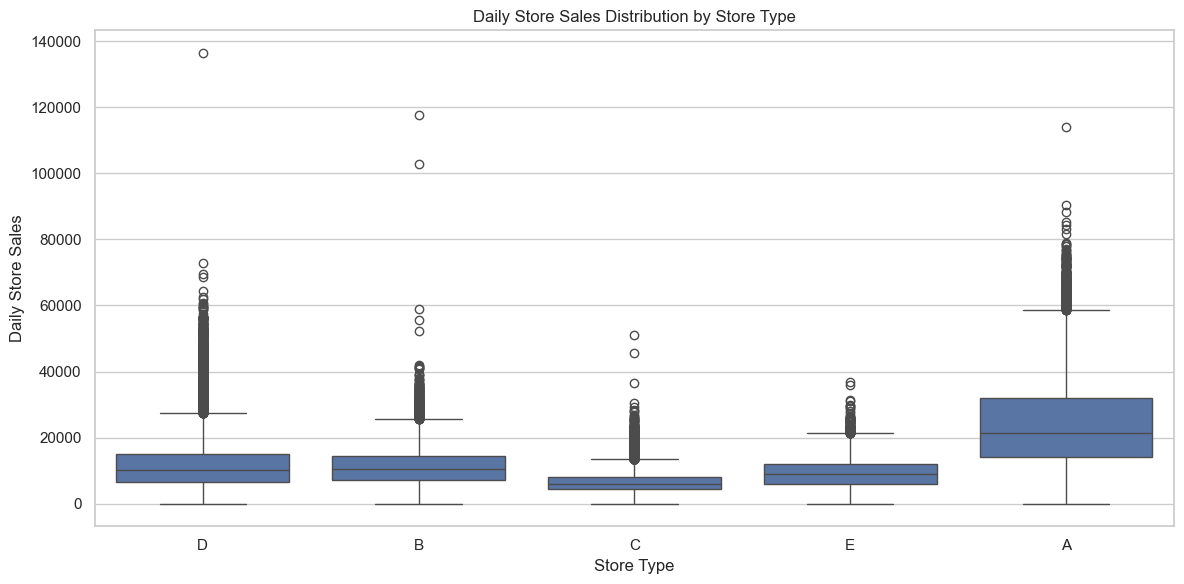

In [31]:
if store_type_column is not None:
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        data=store_daily_sales,
        x=store_type_column,
        y="total_sales",
    )

    plt.title("Daily Store Sales Distribution by Store Type")
    plt.xlabel("Store Type")
    plt.ylabel("Daily Store Sales")
    plt.tight_layout()

    plt.savefig(
        EDA_FIGURES_DIR / "daily_store_sales_distribution_by_store_type.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
else:
    print("No store type column found in train_base.")


In [32]:
if "cluster" in store_daily_sales.columns:
    cluster_sales_summary = (
        store_daily_sales.groupby("cluster", as_index=False)
        .agg(
            stores=("store_nbr", "nunique"),
            observed_store_days=("date", "count"),
            total_sales=("total_sales", "sum"),
            mean_daily_store_sales=("total_sales", "mean"),
            median_daily_store_sales=("total_sales", "median"),
            std_daily_store_sales=("total_sales", "std"),
            mean_promoted_families_pct=("promoted_families_pct", "mean"),
            mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
        )
        .sort_values("total_sales", ascending=False)
    )

    display(cluster_sales_summary)

    cluster_sales_summary.to_csv(
        EDA_TABLES_DIR / "cluster_sales_summary.csv",
        index=False,
    )
else:
    print("No cluster column found in train_base.")


,cluster,stores,observed_store_days,total_sales,mean_daily_store_sales,median_daily_store_sales,std_daily_store_sales,mean_promoted_families_pct,mean_zero_sales_families_pct
13,14,4,6736,1.574305e+08,23371.514709,20372.005490,11386.229758,0.265516,0.200623
5,6,6,10104,1.142544e+08,11307.837168,11330.155005,7248.329593,0.201636,0.347369
7,8,3,5052,1.079282e+08,21363.469259,19483.795005,10328.762168,0.232797,0.196346
10,11,3,5052,1.006143e+08,19915.731578,19487.053500,17220.933208,0.181614,0.440822
9,10,6,10104,8.532443e+07,8444.619006,8327.406989,5073.207170,0.193494,0.350749
2,3,7,11788,7.562870e+07,6415.736635,5497.695000,3584.232583,0.182425,0.351804
12,13,4,6736,7.210225e+07,10704.015557,10480.190000,6208.809805,0.232932,0.276439
4,5,1,1684,6.208755e+07,36869.093379,35423.185000,14704.525437,0.255668,0.179479
14,15,5,8420,5.529695e+07,6567.333654,6353.004500,2260.188647,0.164461,0.318884
0,1,3,5052,5.437675e+07,10763.410918,10081.122999,5954.328514,0.213951,0.260257


In [33]:
if "city" in store_daily_sales.columns:
    city_sales_summary = (
        store_daily_sales.groupby("city", as_index=False)
        .agg(
            stores=("store_nbr", "nunique"),
            observed_store_days=("date", "count"),
            total_sales=("total_sales", "sum"),
            mean_daily_store_sales=("total_sales", "mean"),
            median_daily_store_sales=("total_sales", "median"),
            std_daily_store_sales=("total_sales", "std"),
        )
        .sort_values("total_sales", ascending=False)
    )

    display(city_sales_summary.head(15))

    city_sales_summary.to_csv(
        EDA_TABLES_DIR / "city_sales_summary.csv",
        index=False,
    )
else:
    print("No city column found in train_base.")


,city,stores,observed_store_days,total_sales,mean_daily_store_sales,median_daily_store_sales,std_daily_store_sales
18,Quito,18,30312,5.567418e+08,18367.043970,15024.022550,12805.438200
8,Guayaquil,8,13472,1.229673e+08,9127.617316,7733.466995,6889.056549
3,Cuenca,3,5052,4.916860e+07,9732.501194,10535.174000,6044.867258
0,Ambato,2,3368,4.030440e+07,11966.864994,9559.178001,6805.805698
21,Santo Domingo,3,5052,3.583432e+07,7093.096405,7212.879500,4615.577499
13,Machala,2,3368,3.338680e+07,9912.944342,9559.510500,4280.484844
2,Cayambe,1,1684,2.832556e+07,16820.402899,16191.817979,5044.996402
10,Latacunga,2,3368,2.118226e+07,6289.270717,6200.538000,2120.388662
4,Daule,1,1684,1.918802e+07,11394.311984,11141.273500,4704.777363
12,Loja,1,1684,1.886000e+07,11199.524502,10576.697000,4129.172021


In [34]:
store_analysis_key_findings = pd.DataFrame(
    [
        {
            "finding": "highest_total_sales_store",
            "value": store_sales_summary.iloc[0]["store_nbr"],
            "metric": "total_sales",
            "metric_value": store_sales_summary.iloc[0]["total_sales"],
        },
        {
            "finding": "lowest_total_sales_store",
            "value": store_sales_summary.sort_values(
                "total_sales", ascending=True
            ).iloc[0]["store_nbr"],
            "metric": "total_sales",
            "metric_value": store_sales_summary["total_sales"].min(),
        },
        {
            "finding": "highest_volatility_store",
            "value": store_sales_summary.sort_values(
                "daily_sales_cv", ascending=False
            ).iloc[0]["store_nbr"],
            "metric": "daily_sales_cv",
            "metric_value": store_sales_summary["daily_sales_cv"].max(),
        },
        {
            "finding": "top_5_stores_sales_share_pct",
            "value": "top_5_stores",
            "metric": "sales_share_pct",
            "metric_value": store_sales_summary.head(5)["sales_share_pct"].sum(),
        },
        {
            "finding": "top_10_stores_sales_share_pct",
            "value": "top_10_stores",
            "metric": "sales_share_pct",
            "metric_value": store_sales_summary.head(10)["sales_share_pct"].sum(),
        },
    ]
)

display(store_analysis_key_findings)

store_analysis_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "store_analysis_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,highest_total_sales_store,44,total_sales,6.208755e+07
1,lowest_total_sales_store,52,total_sales,2.696170e+06
2,highest_volatility_store,52,daily_sales_cv,3.738122e+00
3,top_5_stores_sales_share_pct,top_5_stores,sales_share_pct,2.435031e-01
4,top_10_stores_sales_share_pct,top_10_stores,sales_share_pct,4.017379e-01


### Business conclusion

Historical demand is highly concentrated across stores.

Store 44 is the highest-volume store, while the top 10 stores account for more than 40% of total historical sales. This means that forecasting errors in a small group of high-volume stores can have a large operational impact on replenishment.

At the same time, some low-volume stores show very high volatility and a large share of zero-sales families. Store 52 is the clearest example: it has the lowest total sales but the highest daily sales coefficient of variation.

This creates two different business risks:

- high-volume stores create scale risk, where small percentage errors can translate into large absolute replenishment errors;
- low-volume and volatile stores create uncertainty risk, where demand is harder to predict consistently.

Store metadata such as city, state, store type, and cluster should be considered in future feature engineering because demand behavior differs structurally across store profiles.


# 10.Product Family Demand Analysis

This section analyzes historical sales behavior by product family.

The objective is to identify which product families concentrate the highest demand, which ones have more intermittent sales, and which families may create higher replenishment risk.

For forecasting, product families are important because demand patterns can differ substantially across categories. Some families may behave as stable high-volume products, while others may show sparse or irregular demand.


In [35]:
family_daily_sales = train_base.groupby(["date", "family"], as_index=False).agg(
    total_sales=("sales", "sum"),
    mean_store_sales=("sales", "mean"),
    median_store_sales=("sales", "median"),
    max_store_sales=("sales", "max"),
    total_promotion_units=("onpromotion", "sum"),
    promoted_stores=("onpromotion", lambda x: (x > 0).sum()),
    zero_sales_stores=("sales", lambda x: (x == 0).sum()),
    total_stores=("store_nbr", "nunique"),
)

family_daily_sales["promoted_stores_pct"] = (
    family_daily_sales["promoted_stores"] / family_daily_sales["total_stores"]
)

family_daily_sales["zero_sales_stores_pct"] = (
    family_daily_sales["zero_sales_stores"] / family_daily_sales["total_stores"]
)

display(family_daily_sales.head())

family_daily_sales.to_csv(
    EDA_TABLES_DIR / "family_daily_sales_summary.csv",
    index=False,
)


,date,family,total_sales,mean_store_sales,median_store_sales,max_store_sales,total_promotion_units,promoted_stores,zero_sales_stores,total_stores,promoted_stores_pct,zero_sales_stores_pct
0,2013-01-01,AUTOMOTIVE,0.0,0.000000,0.0,0.0,0,0,54,54,0.0,1.000000
1,2013-01-01,BABY CARE,0.0,0.000000,0.0,0.0,0,0,54,54,0.0,1.000000
2,2013-01-01,BEAUTY,2.0,0.037037,0.0,2.0,0,0,53,54,0.0,0.981481
3,2013-01-01,BEVERAGES,810.0,15.000000,0.0,810.0,0,0,53,54,0.0,0.981481
4,2013-01-01,BOOKS,0.0,0.000000,0.0,0.0,0,0,54,54,0.0,1.000000


In [36]:
family_sales_summary = family_daily_sales.groupby("family", as_index=False).agg(
    observed_days=("date", "nunique"),
    total_sales=("total_sales", "sum"),
    mean_daily_sales=("total_sales", "mean"),
    median_daily_sales=("total_sales", "median"),
    std_daily_sales=("total_sales", "std"),
    min_daily_sales=("total_sales", "min"),
    max_daily_sales=("total_sales", "max"),
    total_promotion_units=("total_promotion_units", "sum"),
    mean_promoted_stores_pct=("promoted_stores_pct", "mean"),
    mean_zero_sales_stores_pct=("zero_sales_stores_pct", "mean"),
)

family_sales_summary["daily_sales_cv"] = (
    family_sales_summary["std_daily_sales"] / family_sales_summary["mean_daily_sales"]
)

family_sales_summary["sales_share_pct"] = (
    family_sales_summary["total_sales"] / family_sales_summary["total_sales"].sum()
)

family_sales_summary = family_sales_summary.sort_values(
    "total_sales",
    ascending=False,
).reset_index(drop=True)

display(family_sales_summary)

family_sales_summary.to_csv(
    EDA_TABLES_DIR / "family_sales_summary.csv",
    index=False,
)


,family,observed_days,total_sales,mean_daily_sales,median_daily_sales,std_daily_sales,min_daily_sales,max_daily_sales,total_promotion_units,mean_promoted_stores_pct,mean_zero_sales_stores_pct,daily_sales_cv,sales_share_pct
0,GROCERY I,1684,3.434627e+08,203956.493400,194681.310000,61832.884741,700.000000,583222.480000,1914801,0.625561,0.080628,0.303167,0.319903
1,BEVERAGES,1684,2.169545e+08,128832.830166,128207.500000,63121.645563,810.000000,339352.000000,906958,0.568587,0.080617,0.489950,0.202073
2,PRODUCE,1684,1.227047e+08,72865.014653,96506.697605,61847.252856,0.000000,200580.759500,1117921,0.338524,0.283551,0.848792,0.114288
3,CLEANING,1684,9.752129e+07,57910.504157,55234.500000,15211.880756,186.000000,120902.000000,661157,0.548738,0.080617,0.262679,0.090832
4,DAIRY,1684,6.448771e+07,38294.364014,37896.000000,13725.805476,143.000000,85897.000000,728707,0.505685,0.080617,0.358429,0.060064
5,BREAD/BAKERY,1684,4.213395e+07,25020.157706,24415.176025,6511.795916,180.589000,46445.716980,331289,0.427729,0.080606,0.260262,0.039244
6,POULTRY,1684,3.187600e+07,18928.743748,18248.124513,6078.421638,42.637000,43734.450140,226421,0.216680,0.080760,0.321121,0.029690
7,MEATS,1684,3.108647e+07,18459.898102,17752.996433,4334.042954,110.801000,114430.285038,304028,0.236078,0.080617,0.234782,0.028954
8,PERSONAL CARE,1684,2.459205e+07,14603.355701,13518.000000,5361.252413,25.000000,39291.000000,246928,0.420417,0.080650,0.367125,0.022905
9,DELI,1684,2.411032e+07,14317.293628,13875.057000,4171.725802,71.090000,29189.300000,583316,0.434140,0.080617,0.291377,0.022457


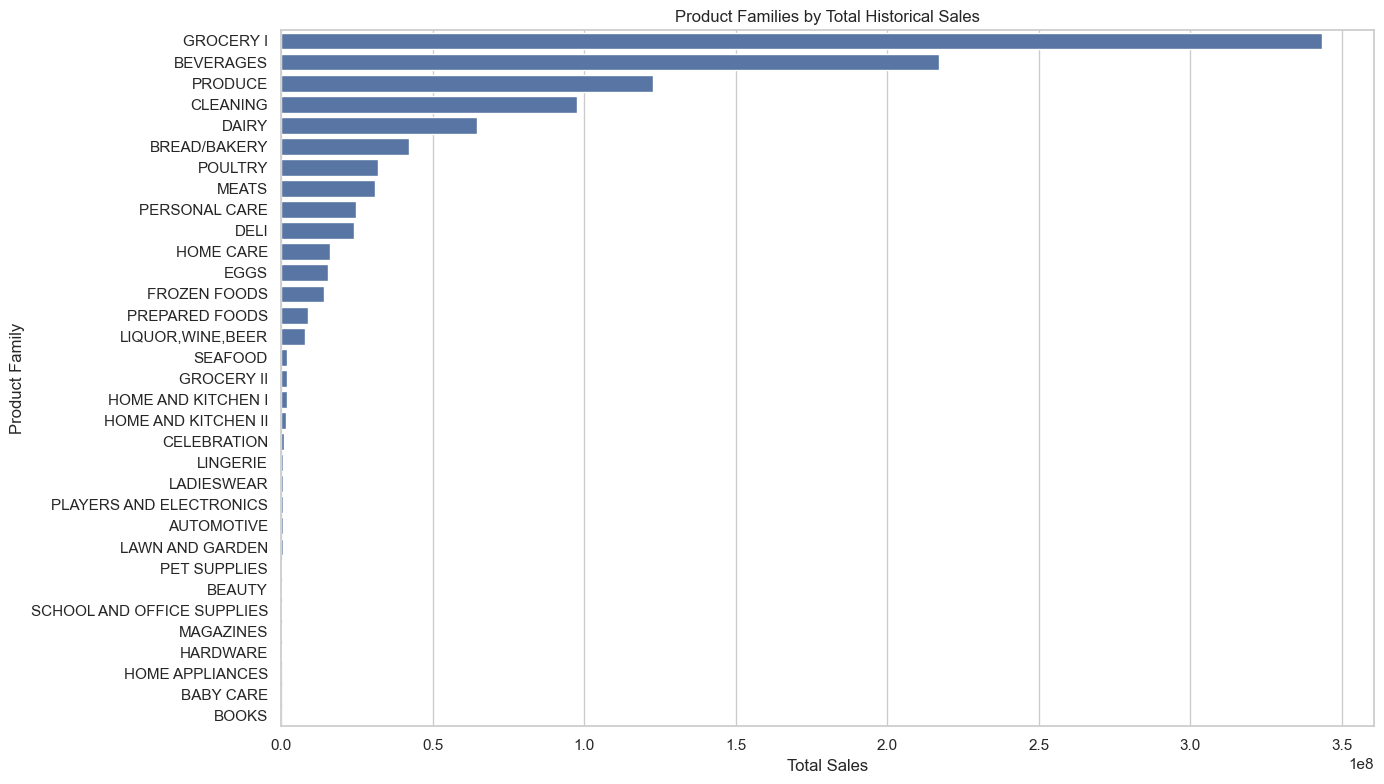

In [37]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=family_sales_summary,
    x="total_sales",
    y="family",
)

plt.title("Product Families by Total Historical Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Family")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "families_by_total_sales.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


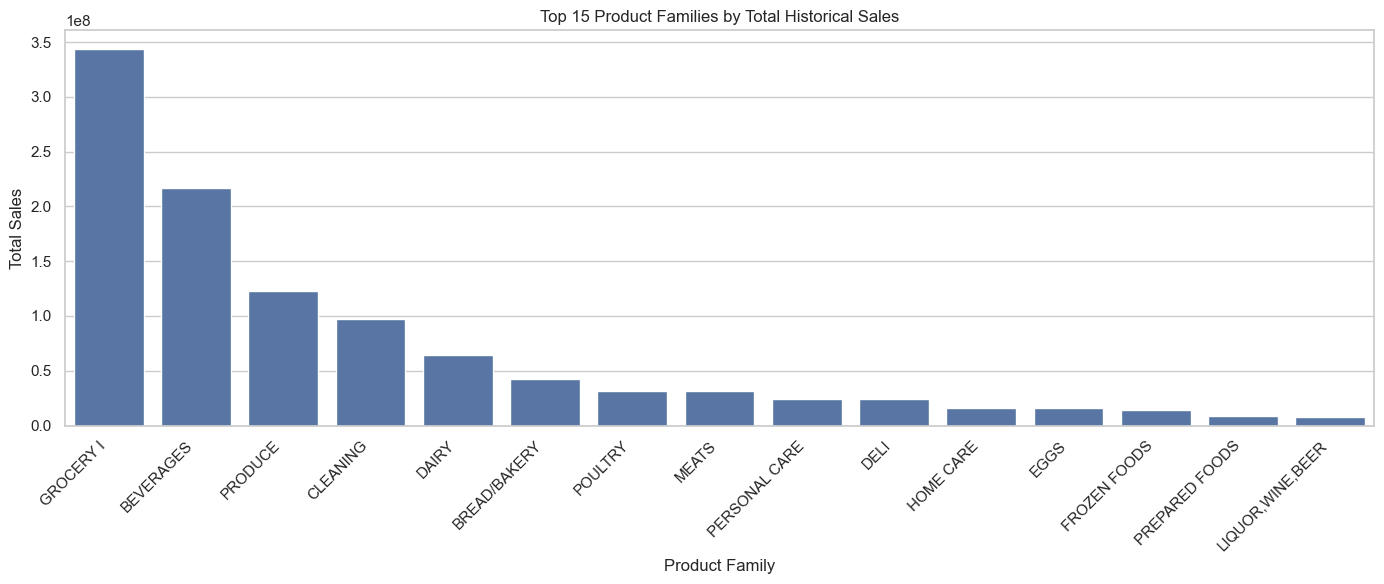

In [38]:
top_family_sales = family_sales_summary.head(15).copy()

plt.figure(figsize=(14, 6))

sns.barplot(
    data=top_family_sales,
    x="family",
    y="total_sales",
)

plt.title("Top 15 Product Families by Total Historical Sales")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "top_15_families_by_total_sales.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [39]:
family_zero_sales_summary = family_sales_summary.sort_values(
    "mean_zero_sales_stores_pct", ascending=False
).loc[
    :,
    [
        "family",
        "total_sales",
        "mean_daily_sales",
        "daily_sales_cv",
        "mean_zero_sales_stores_pct",
        "mean_promoted_stores_pct",
        "sales_share_pct",
    ],
]

display(family_zero_sales_summary)

family_zero_sales_summary.to_csv(
    EDA_TABLES_DIR / "family_zero_sales_summary.csv",
    index=False,
)


,family,total_sales,mean_daily_sales,daily_sales_cv,mean_zero_sales_stores_pct,mean_promoted_stores_pct,sales_share_pct
32,BOOKS,6.438000e+03,3.823040,3.392309,0.969550,0.000000,0.000006
31,BABY CARE,1.005100e+04,5.968527,1.331508,0.941310,0.000583,0.000009
27,SCHOOL AND OFFICE SUPPLIES,2.693160e+05,159.926366,2.683122,0.740829,0.044581,0.000251
30,HOME APPLIANCES,4.160100e+04,24.703682,0.563966,0.735176,0.000638,0.000039
21,LADIESWEAR,6.511590e+05,386.673990,0.985044,0.598465,0.005059,0.000606
28,MAGAZINES,2.663590e+05,158.170428,1.132860,0.565387,0.001748,0.000248
25,PET SUPPLIES,3.565840e+05,211.748219,0.930665,0.546153,0.033573,0.000332
29,HARDWARE,1.034700e+05,61.442993,0.326896,0.478622,0.001452,0.000096
24,LAWN AND GARDEN,5.488420e+05,325.915677,1.044778,0.467846,0.046538,0.000511
22,PLAYERS AND ELECTRONICS,5.626080e+05,334.090261,0.922816,0.448865,0.009336,0.000524


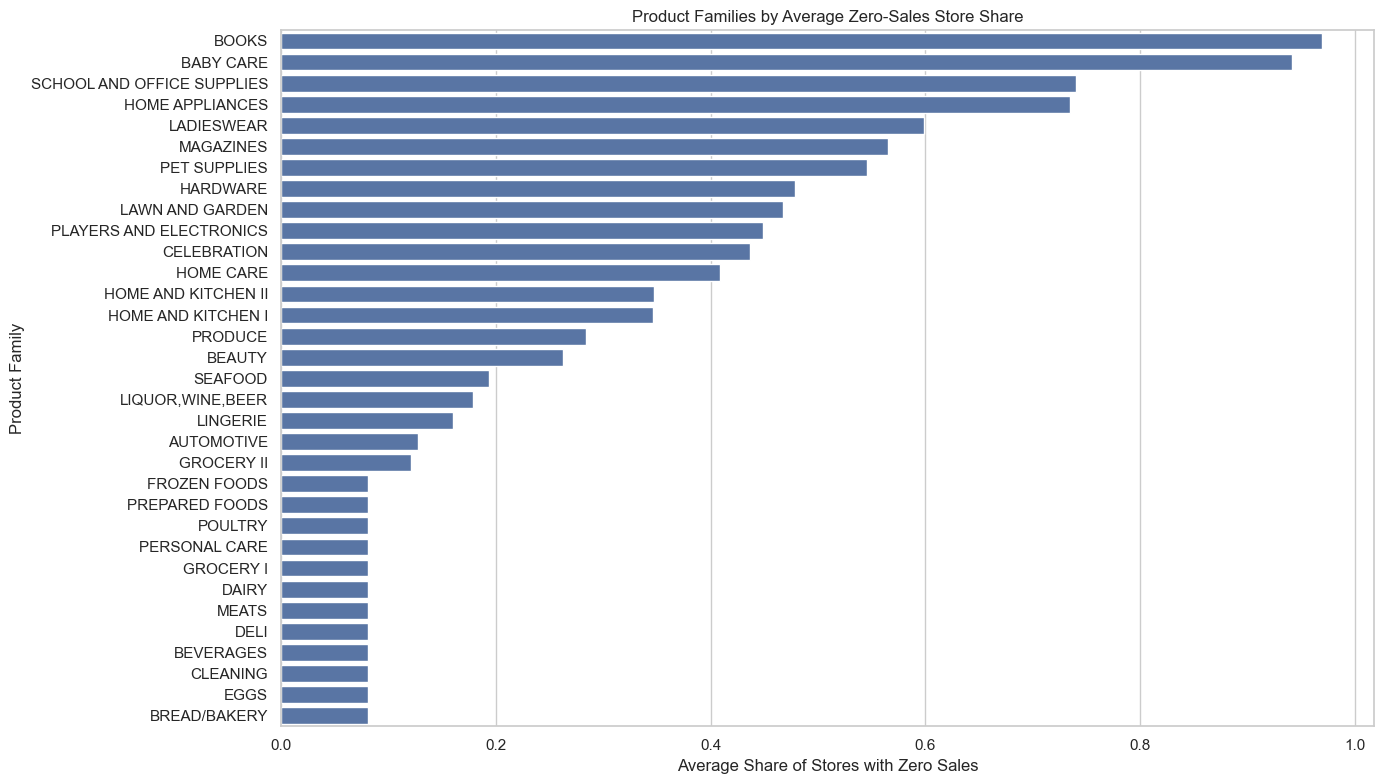

In [40]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=family_zero_sales_summary,
    x="mean_zero_sales_stores_pct",
    y="family",
)

plt.title("Product Families by Average Zero-Sales Store Share")
plt.xlabel("Average Share of Stores with Zero Sales")
plt.ylabel("Product Family")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "families_by_zero_sales_share.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [41]:
family_volatility_summary = family_sales_summary.sort_values(
    "daily_sales_cv", ascending=False
).loc[
    :,
    [
        "family",
        "total_sales",
        "mean_daily_sales",
        "std_daily_sales",
        "daily_sales_cv",
        "mean_zero_sales_stores_pct",
        "mean_promoted_stores_pct",
        "sales_share_pct",
    ],
]

display(family_volatility_summary)

family_volatility_summary.to_csv(
    EDA_TABLES_DIR / "family_volatility_summary.csv",
    index=False,
)


,family,total_sales,mean_daily_sales,std_daily_sales,daily_sales_cv,mean_zero_sales_stores_pct,mean_promoted_stores_pct,sales_share_pct
32,BOOKS,6.438000e+03,3.823040,12.968935,3.392309,0.969550,0.000000,0.000006
27,SCHOOL AND OFFICE SUPPLIES,2.693160e+05,159.926366,429.102006,2.683122,0.740829,0.044581,0.000251
31,BABY CARE,1.005100e+04,5.968527,7.947142,1.331508,0.941310,0.000583,0.000009
12,FROZEN FOODS,1.407389e+07,8357.415511,10318.131263,1.234608,0.080914,0.393903,0.013109
28,MAGAZINES,2.663590e+05,158.170428,179.184971,1.132860,0.565387,0.001748,0.000248
24,LAWN AND GARDEN,5.488420e+05,325.915677,340.509496,1.044778,0.467846,0.046538,0.000511
21,LADIESWEAR,6.511590e+05,386.673990,380.890911,0.985044,0.598465,0.005059,0.000606
25,PET SUPPLIES,3.565840e+05,211.748219,197.066718,0.930665,0.546153,0.033573,0.000332
22,PLAYERS AND ELECTRONICS,5.626080e+05,334.090261,308.303838,0.922816,0.448865,0.009336,0.000524
19,CELEBRATION,7.611770e+05,452.005344,408.812745,0.904442,0.436340,0.035311,0.000709


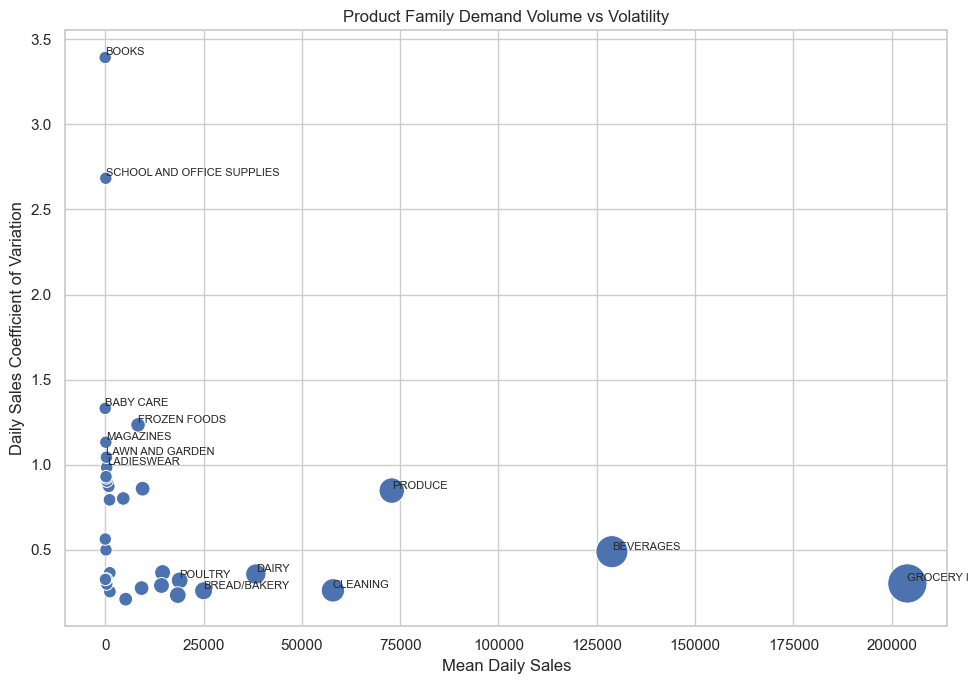

In [42]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=family_sales_summary,
    x="mean_daily_sales",
    y="daily_sales_cv",
    size="sales_share_pct",
    sizes=(80, 800),
    legend=False,
)

for _, row in family_sales_summary.iterrows():
    if row["sales_share_pct"] >= family_sales_summary["sales_share_pct"].quantile(
        0.80
    ) or row["daily_sales_cv"] >= family_sales_summary["daily_sales_cv"].quantile(0.80):
        plt.text(
            row["mean_daily_sales"],
            row["daily_sales_cv"],
            row["family"],
            fontsize=8,
            ha="left",
            va="bottom",
        )

plt.title("Product Family Demand Volume vs Volatility")
plt.xlabel("Mean Daily Sales")
plt.ylabel("Daily Sales Coefficient of Variation")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "family_volume_vs_volatility.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [43]:
family_analysis_key_findings = pd.DataFrame(
    [
        {
            "finding": "highest_total_sales_family",
            "value": family_sales_summary.iloc[0]["family"],
            "metric": "total_sales",
            "metric_value": family_sales_summary.iloc[0]["total_sales"],
        },
        {
            "finding": "lowest_total_sales_family",
            "value": family_sales_summary.sort_values(
                "total_sales", ascending=True
            ).iloc[0]["family"],
            "metric": "total_sales",
            "metric_value": family_sales_summary["total_sales"].min(),
        },
        {
            "finding": "highest_zero_sales_family",
            "value": family_sales_summary.sort_values(
                "mean_zero_sales_stores_pct", ascending=False
            ).iloc[0]["family"],
            "metric": "mean_zero_sales_stores_pct",
            "metric_value": family_sales_summary["mean_zero_sales_stores_pct"].max(),
        },
        {
            "finding": "highest_volatility_family",
            "value": family_sales_summary.sort_values(
                "daily_sales_cv", ascending=False
            ).iloc[0]["family"],
            "metric": "daily_sales_cv",
            "metric_value": family_sales_summary["daily_sales_cv"].max(),
        },
        {
            "finding": "top_5_families_sales_share_pct",
            "value": "top_5_families",
            "metric": "sales_share_pct",
            "metric_value": family_sales_summary.head(5)["sales_share_pct"].sum(),
        },
        {
            "finding": "top_10_families_sales_share_pct",
            "value": "top_10_families",
            "metric": "sales_share_pct",
            "metric_value": family_sales_summary.head(10)["sales_share_pct"].sum(),
        },
    ]
)

display(family_analysis_key_findings)

family_analysis_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "family_analysis_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,highest_total_sales_family,GROCERY I,total_sales,3.434627e+08
1,lowest_total_sales_family,BOOKS,total_sales,6.438000e+03
2,highest_zero_sales_family,BOOKS,mean_zero_sales_stores_pct,9.695500e-01
3,highest_volatility_family,BOOKS,daily_sales_cv,3.392309e+00
4,top_5_families_sales_share_pct,top_5_families,sales_share_pct,7.871605e-01
5,top_10_families_sales_share_pct,top_10_families,sales_share_pct,9.304097e-01


### Business conclusion

Historical demand is highly concentrated across product families.

GROCERY I and BEVERAGES dominate total sales, and the top 5 product families account for most of the historical demand. This creates a clear replenishment priority: forecast errors in high-volume families can generate large absolute inventory gaps.

At the same time, low-volume families such as BOOKS, BABY CARE, and SCHOOL AND OFFICE SUPPLIES show very high zero-sales shares and high relative volatility. These families create a different forecasting challenge because their demand is sparse and less regular.

This means that future modeling should not evaluate all families only through global average performance. High-volume families should be monitored for absolute replenishment impact, while intermittent families may require special attention due to instability and frequent zero-sales behavior.

Product family should be treated as a key driver for future feature engineering, model validation, and business interpretation.


# 11.Promotion Analysis

This section analyzes the relationship between promotions and historical sales.

The objective is to understand whether promoted observations tend to show different sales behavior and whether promotion intensity differs between the historical training period and the future forecasting horizon.

Promotions are especially relevant because `onpromotion` is available in both train and test data. However, this section only performs descriptive analysis and does not assume a causal effect.


In [44]:
promotion_train_test_summary = pd.DataFrame(
    [
        {
            "dataset": "train_base",
            "rows": len(train_base),
            "rows_with_promotion": (train_base["onpromotion"] > 0).sum(),
            "rows_with_promotion_pct": (train_base["onpromotion"] > 0).mean(),
            "total_promotion_units": train_base["onpromotion"].sum(),
            "mean_promotion_units_per_row": train_base["onpromotion"].mean(),
            "median_promotion_units_per_row": train_base["onpromotion"].median(),
            "max_promotion_units_per_row": train_base["onpromotion"].max(),
        },
        {
            "dataset": "test_base",
            "rows": len(test_base),
            "rows_with_promotion": (test_base["onpromotion"] > 0).sum(),
            "rows_with_promotion_pct": (test_base["onpromotion"] > 0).mean(),
            "total_promotion_units": test_base["onpromotion"].sum(),
            "mean_promotion_units_per_row": test_base["onpromotion"].mean(),
            "median_promotion_units_per_row": test_base["onpromotion"].median(),
            "max_promotion_units_per_row": test_base["onpromotion"].max(),
        },
    ]
)

display(promotion_train_test_summary)

promotion_train_test_summary.to_csv(
    EDA_TABLES_DIR / "promotion_train_test_summary.csv",
    index=False,
)


,dataset,rows,rows_with_promotion,rows_with_promotion_pct,total_promotion_units,mean_promotion_units_per_row,median_promotion_units_per_row,max_promotion_units_per_row
0,train_base,3000888,611329,0.203716,7810622,2.602770,0.0,741
1,test_base,28512,12569,0.440832,198597,6.965383,0.0,646


In [45]:
promotion_sales_summary = (
    train_base.assign(has_promotion=train_base["onpromotion"] > 0)
    .groupby("has_promotion", as_index=False)
    .agg(
        rows=("sales", "size"),
        total_sales=("sales", "sum"),
        mean_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        max_sales=("sales", "max"),
        zero_sales_rows=("sales", lambda x: (x == 0).sum()),
        total_promotion_units=("onpromotion", "sum"),
    )
)

promotion_sales_summary["rows_pct"] = (
    promotion_sales_summary["rows"] / promotion_sales_summary["rows"].sum()
)

promotion_sales_summary["sales_share_pct"] = (
    promotion_sales_summary["total_sales"]
    / promotion_sales_summary["total_sales"].sum()
)

promotion_sales_summary["zero_sales_pct"] = (
    promotion_sales_summary["zero_sales_rows"] / promotion_sales_summary["rows"]
)

display(promotion_sales_summary)

promotion_sales_summary.to_csv(
    EDA_TABLES_DIR / "promotion_sales_summary.csv",
    index=False,
)


,has_promotion,rows,total_sales,mean_sales,median_sales,max_sales,zero_sales_rows,total_promotion_units,rows_pct,sales_share_pct,zero_sales_pct
0,False,2389559,3.781398e+08,158.246681,3.0,89576.36,939113,0,0.796284,0.352202,0.393007
1,True,611329,6.955052e+08,1137.693730,373.0,124717.00,17,7810622,0.203716,0.647798,0.000028


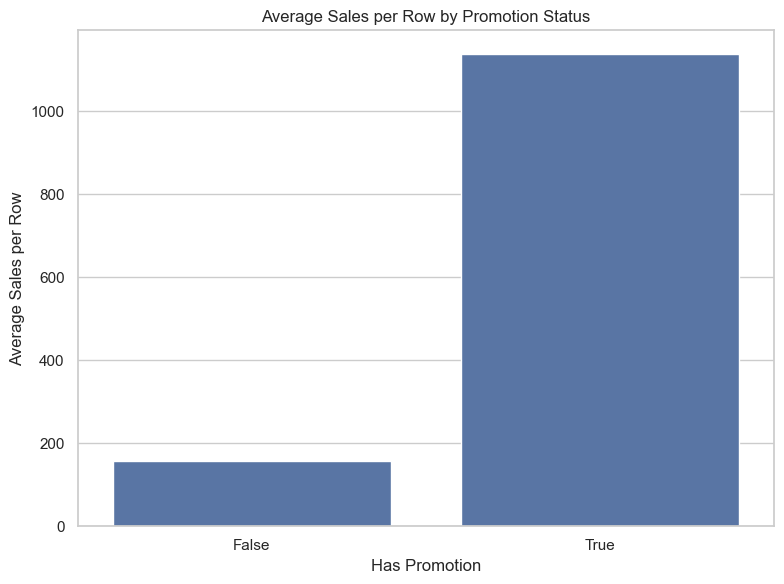

In [46]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=promotion_sales_summary,
    x="has_promotion",
    y="mean_sales",
)

plt.title("Average Sales per Row by Promotion Status")
plt.xlabel("Has Promotion")
plt.ylabel("Average Sales per Row")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "average_sales_by_promotion_status.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [47]:
promotion_family_summary = (
    train_base.assign(has_promotion=train_base["onpromotion"] > 0)
    .groupby("family", as_index=False)
    .agg(
        rows=("sales", "size"),
        total_sales=("sales", "sum"),
        mean_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        rows_with_promotion=("has_promotion", "sum"),
        total_promotion_units=("onpromotion", "sum"),
        promoted_sales=(
            "sales",
            lambda x: x[train_base.loc[x.index, "onpromotion"] > 0].sum(),
        ),
        non_promoted_sales=(
            "sales",
            lambda x: x[train_base.loc[x.index, "onpromotion"] == 0].sum(),
        ),
    )
)

promotion_family_summary["rows_with_promotion_pct"] = (
    promotion_family_summary["rows_with_promotion"] / promotion_family_summary["rows"]
)

promotion_family_summary["promotion_units_share_pct"] = (
    promotion_family_summary["total_promotion_units"]
    / promotion_family_summary["total_promotion_units"].sum()
)

promotion_family_summary["promoted_sales_share_within_family_pct"] = (
    promotion_family_summary["promoted_sales"] / promotion_family_summary["total_sales"]
)

promotion_family_summary = promotion_family_summary.sort_values(
    "total_promotion_units",
    ascending=False,
).reset_index(drop=True)

display(promotion_family_summary)

promotion_family_summary.to_csv(
    EDA_TABLES_DIR / "promotion_family_summary.csv",
    index=False,
)


,family,rows,total_sales,mean_sales,median_sales,rows_with_promotion,total_promotion_units,promoted_sales,non_promoted_sales,rows_with_promotion_pct,promotion_units_share_pct,promoted_sales_share_within_family_pct
0,GROCERY I,90936,3.434627e+08,3776.972100,3185.0000,56886,1914801,2.509243e+08,9.253839e+07,0.625561,0.245153,0.730572
1,PRODUCE,90936,1.227047e+08,1349.352123,398.2905,30784,1117921,7.505817e+07,4.764651e+07,0.338524,0.143128,0.611698
2,BEVERAGES,90936,2.169545e+08,2385.793151,1784.0000,51705,906958,1.662573e+08,5.069715e+07,0.568587,0.116119,0.766324
3,DAIRY,90936,6.448771e+07,709.154889,520.0000,45985,728707,4.291972e+07,2.156799e+07,0.505685,0.093297,0.665549
4,CLEANING,90936,9.752129e+07,1072.416744,938.0000,49900,661157,6.188652e+07,3.563477e+07,0.548738,0.084648,0.634595
5,DELI,90936,2.411032e+07,265.135067,218.9715,39479,583316,1.269904e+07,1.141128e+07,0.434140,0.074682,0.526706
6,BREAD/BAKERY,90936,4.213395e+07,463.336254,401.0000,38896,331289,2.238408e+07,1.974987e+07,0.427729,0.042415,0.531260
7,MEATS,90936,3.108647e+07,341.849965,224.9365,21468,304028,1.003203e+07,2.105444e+07,0.236078,0.038925,0.322714
8,PERSONAL CARE,90936,2.459205e+07,270.432513,222.0000,38231,246928,1.295062e+07,1.164143e+07,0.420417,0.031614,0.526618
9,POULTRY,90936,3.187600e+07,350.532292,205.7430,19704,226421,9.556560e+06,2.231944e+07,0.216680,0.028989,0.299804


In [ ]:
promotion_family_sales_comparison = (
    train_base.assign(has_promotion=train_base["onpromotion"] > 0)
    .groupby(["family", "has_promotion"], as_index=False)
    .agg(
        rows=("sales", "size"),
        mean_sales=("sales", "mean"),
        median_sales=("sales", "median"),
        total_sales=("sales", "sum"),
        zero_sales_pct=("sales", lambda x: (x == 0).mean()),
    )
)

promotion_family_sales_pivot = (
    promotion_family_sales_comparison.pivot(
        index="family",
        columns="has_promotion",
        values="mean_sales",
    )
    .reset_index()
    .rename(
        columns={
            False: "mean_sales_without_promotion",
            True: "mean_sales_with_promotion",
        }
    )
)

promotion_family_sales_pivot["promotion_mean_sales_ratio"] = (
    promotion_family_sales_pivot["mean_sales_with_promotion"]
    / promotion_family_sales_pivot["mean_sales_without_promotion"]
)

promotion_family_sales_pivot = promotion_family_sales_pivot.sort_values(
    "promotion_mean_sales_ratio",
    ascending=False,
)

display(promotion_family_sales_pivot)

promotion_family_sales_pivot.to_csv(
    EDA_TABLES_DIR / "promotion_family_sales_comparison.csv",
    index=False,
)


In [ ]:
promotion_family_support = (
    promotion_family_sales_comparison.pivot(
        index="family",
        columns="has_promotion",
        values="rows",
    )
    .reset_index()
    .rename(
        columns={
            False: "rows_without_promotion",
            True: "rows_with_promotion",
        }
    )
)

promotion_family_sales_pivot_with_support = promotion_family_sales_pivot.merge(
    promotion_family_support,
    on="family",
    how="left",
)

promotion_family_sales_pivot_with_support["has_enough_promotion_support"] = (
    promotion_family_sales_pivot_with_support["rows_with_promotion"] >= 500
)

display(
    promotion_family_sales_pivot_with_support.sort_values(
        "promotion_mean_sales_ratio",
        ascending=False,
    )
)

promotion_family_sales_pivot_with_support.to_csv(
    EDA_TABLES_DIR / "promotion_family_sales_comparison_with_support.csv",
    index=False,
)


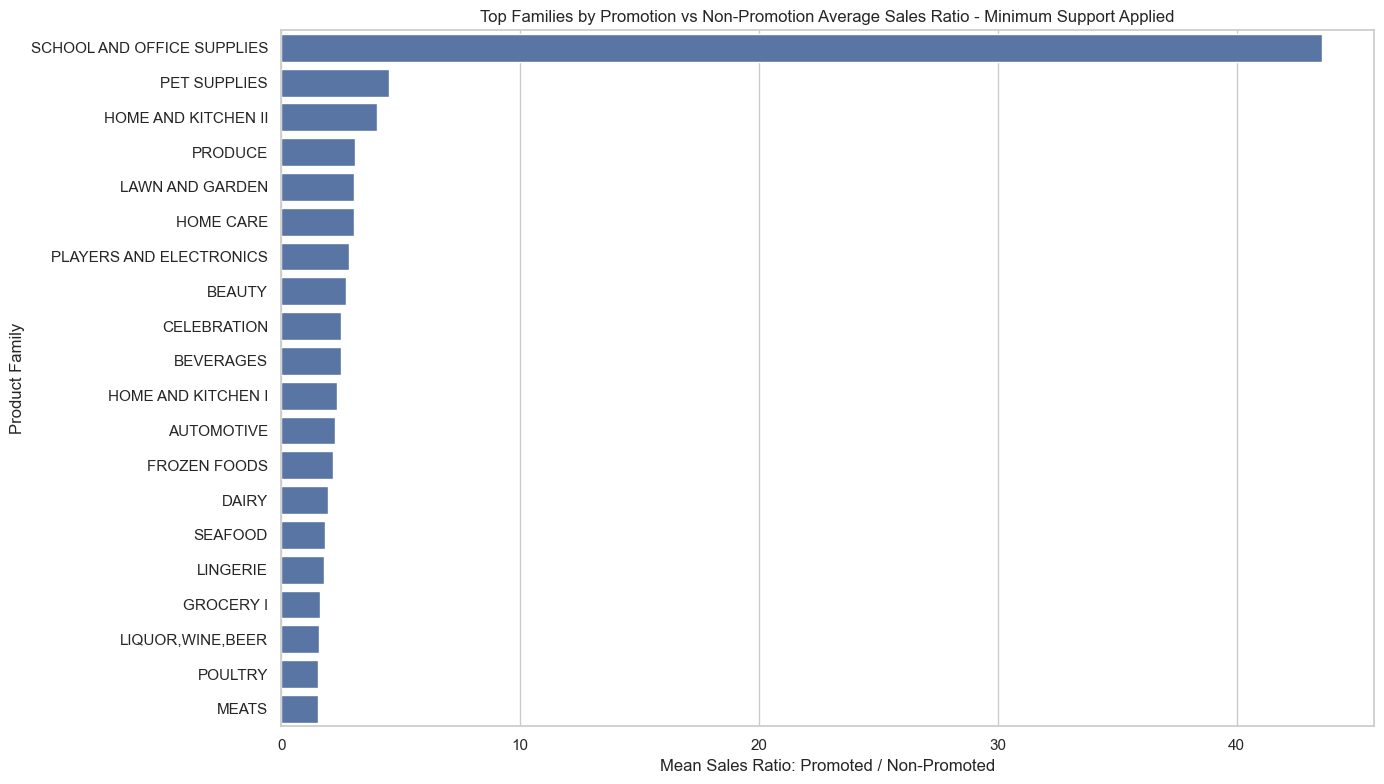

In [ ]:
plt.figure(figsize=(14, 8))

plot_data = (
    promotion_family_sales_pivot_with_support.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["promotion_mean_sales_ratio"])
    .loc[lambda df: df["has_enough_promotion_support"]]
    .sort_values("promotion_mean_sales_ratio", ascending=False)
    .head(20)
)

sns.barplot(
    data=plot_data,
    x="promotion_mean_sales_ratio",
    y="family",
)

plt.title(
    "Top Families by Promotion vs Non-Promotion Average Sales Ratio - Minimum Support Applied"
)
plt.xlabel("Mean Sales Ratio: Promoted / Non-Promoted")
plt.ylabel("Product Family")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "promotion_sales_ratio_by_family_minimum_support.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
daily_promotion_sales = train_base.groupby("date", as_index=False).agg(
    total_sales=("sales", "sum"),
    total_promotion_units=("onpromotion", "sum"),
    promoted_rows=("onpromotion", lambda x: (x > 0).sum()),
    total_rows=("onpromotion", "size"),
)

daily_promotion_sales["promoted_rows_pct"] = (
    daily_promotion_sales["promoted_rows"] / daily_promotion_sales["total_rows"]
)

display(daily_promotion_sales.head())

daily_promotion_sales.to_csv(
    EDA_TABLES_DIR / "daily_promotion_sales_summary.csv",
    index=False,
)


,date,total_sales,total_promotion_units,promoted_rows,total_rows,promoted_rows_pct
0,2013-01-01,2511.618999,0,0,1782,0.0
1,2013-01-02,496092.417944,0,0,1782,0.0
2,2013-01-03,361461.231124,0,0,1782,0.0
3,2013-01-04,354459.677093,0,0,1782,0.0
4,2013-01-05,477350.121229,0,0,1782,0.0


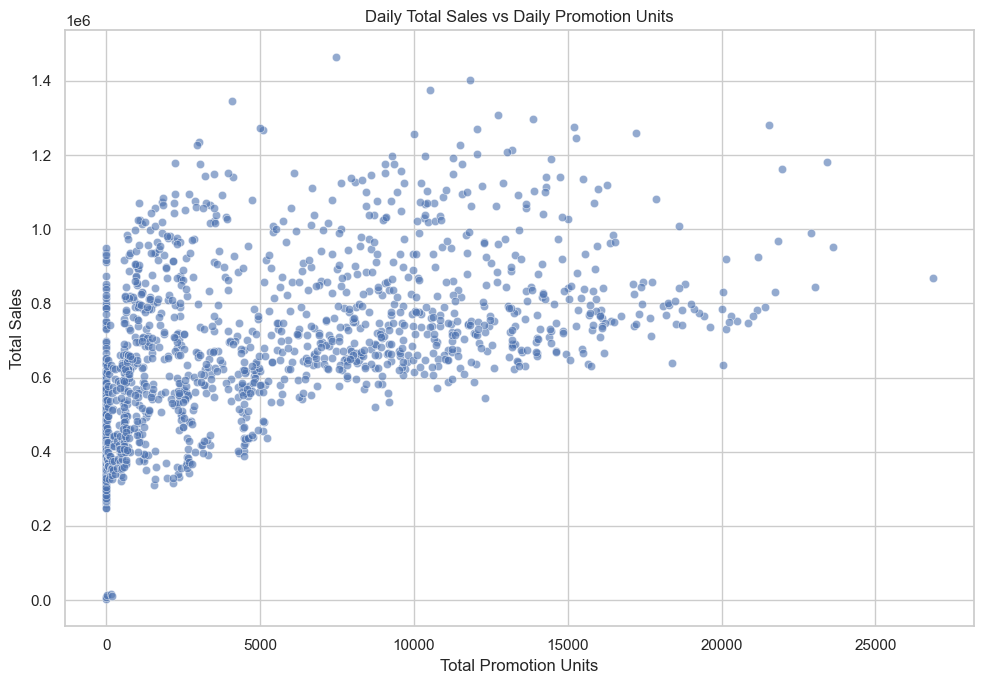

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=daily_promotion_sales,
    x="total_promotion_units",
    y="total_sales",
    alpha=0.6,
)

plt.title("Daily Total Sales vs Daily Promotion Units")
plt.xlabel("Total Promotion Units")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_vs_promotion_units.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
correlation_data = daily_promotion_sales[
    ["total_promotion_units", "total_sales"]
].dropna()

pearson_correlation = correlation_data["total_promotion_units"].corr(
    correlation_data["total_sales"],
    method="pearson",
)

# Spearman correlation without scipy:
# Spearman is Pearson correlation applied to ranked values.
spearman_correlation = (
    correlation_data["total_promotion_units"]
    .rank()
    .corr(
        correlation_data["total_sales"].rank(),
        method="pearson",
    )
)

promotion_correlation_summary = pd.DataFrame(
    [
        {
            "correlation_type": "pearson",
            "metric_x": "daily_total_promotion_units",
            "metric_y": "daily_total_sales",
            "correlation_value": pearson_correlation,
        },
        {
            "correlation_type": "spearman",
            "metric_x": "daily_total_promotion_units",
            "metric_y": "daily_total_sales",
            "correlation_value": spearman_correlation,
        },
    ]
)

display(promotion_correlation_summary)

promotion_correlation_summary.to_csv(
    EDA_TABLES_DIR / "promotion_correlation_summary.csv",
    index=False,
)


,correlation_type,metric_x,metric_y,correlation_value
0,pearson,daily_total_promotion_units,daily_total_sales,0.574943
1,spearman,daily_total_promotion_units,daily_total_sales,0.700717


In [ ]:
promotion_analysis_key_findings = pd.DataFrame(
    [
        {
            "finding": "train_rows_with_promotion_pct",
            "value": "train_base",
            "metric": "rows_with_promotion_pct",
            "metric_value": promotion_train_test_summary.loc[
                promotion_train_test_summary["dataset"] == "train_base",
                "rows_with_promotion_pct",
            ].iloc[0],
        },
        {
            "finding": "test_rows_with_promotion_pct",
            "value": "test_base",
            "metric": "rows_with_promotion_pct",
            "metric_value": promotion_train_test_summary.loc[
                promotion_train_test_summary["dataset"] == "test_base",
                "rows_with_promotion_pct",
            ].iloc[0],
        },
        {
            "finding": "highest_promotion_units_family",
            "value": promotion_family_summary.iloc[0]["family"],
            "metric": "total_promotion_units",
            "metric_value": promotion_family_summary.iloc[0]["total_promotion_units"],
        },
        {
            "finding": "highest_promotion_sales_ratio_family",
            "value": promotion_family_sales_pivot.replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["promotion_mean_sales_ratio"])
            .iloc[0]["family"],
            "metric": "promotion_mean_sales_ratio",
            "metric_value": promotion_family_sales_pivot.replace(
                [np.inf, -np.inf], np.nan
            )
            .dropna(subset=["promotion_mean_sales_ratio"])
            .iloc[0]["promotion_mean_sales_ratio"],
        },
        {
            "finding": "daily_promotion_sales_pearson_correlation",
            "value": "daily_level",
            "metric": "pearson_correlation",
            "metric_value": promotion_correlation_summary.loc[
                promotion_correlation_summary["correlation_type"] == "pearson",
                "correlation_value",
            ].iloc[0],
        },
    ]
)

display(promotion_analysis_key_findings)

promotion_analysis_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "promotion_analysis_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,train_rows_with_promotion_pct,train_base,rows_with_promotion_pct,2.037160e-01
1,test_rows_with_promotion_pct,test_base,rows_with_promotion_pct,4.408319e-01
2,highest_promotion_units_family,GROCERY I,total_promotion_units,1.914801e+06
3,highest_promotion_sales_ratio_family,SCHOOL AND OFFICE SUPPLIES,promotion_mean_sales_ratio,4.356977e+01
4,daily_promotion_sales_pearson_correlation,daily_level,pearson_correlation,5.749429e-01


### Business conclusion

Promotions are strongly associated with historical demand, but their effect should be interpreted carefully.

Promoted rows represent only around 20% of the historical training rows, but they account for a much larger share of total sales. Average sales per promoted row are also substantially higher than average sales per non-promoted row.

The future forecasting horizon has a much higher promotion share than the historical average. This is an important modeling risk because the model will need to forecast a period with stronger promotional pressure than the average historical period.

Promotion behavior also differs by product family. High-volume families such as GROCERY I, BEVERAGES, PRODUCE, DAIRY, and CLEANING concentrate much of the promotional activity, while some lower-volume families show very high relative promotion ratios.

Promotions should be included as a candidate feature in future modeling, but this EDA only provides descriptive evidence. It does not prove causal promotion uplift.


# 12.Holiday and Event Analysis

This section analyzes the relationship between calendar events and historical sales.

The objective is to understand whether holidays and events are associated with changes in demand patterns.

The holiday data was aggregated by date in the previous notebook to avoid row multiplication during joins. Therefore, this section analyzes calendar event pressure at date level rather than assigning every local or regional event to individual stores.

This analysis is descriptive and does not assume that holidays cause demand changes by themselves.


In [ ]:
holiday_core_columns = [
    "calendar_event_count",
    "transferred_event_count",
    "unique_locale_names",
    "non_transferred_event_count",
    "is_calendar_event",
    "has_non_transferred_event",
    "has_transferred_event",
]

holiday_type_columns = [
    column for column in train_base.columns if column.startswith("holiday_type_")
]

holiday_locale_columns = [
    column for column in train_base.columns if column.startswith("holiday_locale_")
]

available_holiday_core_columns = [
    column for column in holiday_core_columns if column in train_base.columns
]

holiday_columns_overview = pd.DataFrame(
    [
        {
            "column_group": "core",
            "column_name": column,
        }
        for column in available_holiday_core_columns
    ]
    + [
        {
            "column_group": "type",
            "column_name": column,
        }
        for column in holiday_type_columns
    ]
    + [
        {
            "column_group": "locale",
            "column_name": column,
        }
        for column in holiday_locale_columns
    ]
)

display(holiday_columns_overview)

holiday_columns_overview.to_csv(
    EDA_TABLES_DIR / "holiday_columns_overview.csv",
    index=False,
)


,column_group,column_name
0,core,calendar_event_count
1,core,transferred_event_count
2,core,unique_locale_names
3,core,non_transferred_event_count
4,core,is_calendar_event
5,core,has_non_transferred_event
6,core,has_transferred_event
7,type,holiday_type_additional
8,type,holiday_type_bridge
9,type,holiday_type_event


In [ ]:
holiday_feature_columns = (
    available_holiday_core_columns + holiday_type_columns + holiday_locale_columns
)

daily_holiday_features = (
    train_base[["date"] + holiday_feature_columns]
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

daily_holiday_sales = (
    train_base.groupby("date", as_index=False)
    .agg(
        total_sales=("sales", "sum"),
        mean_sales_per_row=("sales", "mean"),
        median_sales_per_row=("sales", "median"),
        total_promotion_units=("onpromotion", "sum"),
        rows_with_promotion=("onpromotion", lambda x: (x > 0).sum()),
        zero_sales_rows=("sales", lambda x: (x == 0).sum()),
        total_rows=("sales", "size"),
    )
    .merge(
        daily_holiday_features,
        on="date",
        how="left",
        validate="one_to_one",
    )
)

daily_holiday_sales["rows_with_promotion_pct"] = (
    daily_holiday_sales["rows_with_promotion"] / daily_holiday_sales["total_rows"]
)

daily_holiday_sales["zero_sales_pct"] = (
    daily_holiday_sales["zero_sales_rows"] / daily_holiday_sales["total_rows"]
)

daily_holiday_sales["is_year_start"] = (daily_holiday_sales["date"].dt.month == 1) & (
    daily_holiday_sales["date"].dt.day == 1
)

display(daily_holiday_sales.head())

daily_holiday_sales.to_csv(
    EDA_TABLES_DIR / "daily_holiday_sales_summary.csv",
    index=False,
)


,date,total_sales,mean_sales_per_row,median_sales_per_row,total_promotion_units,rows_with_promotion,zero_sales_rows,total_rows,calendar_event_count,transferred_event_count,unique_locale_names,non_transferred_event_count,is_calendar_event,has_non_transferred_event,has_transferred_event,holiday_type_additional,holiday_type_bridge,holiday_type_event,holiday_type_holiday,holiday_type_transfer,holiday_type_work_day,holiday_locale_local,holiday_locale_national,holiday_locale_regional,rows_with_promotion_pct,zero_sales_pct,is_year_start
0,2013-01-01,2511.618999,1.409438,0.0,0,0,1765,1782,1,0,1,1,True,True,False,0,0,0,1,0,0,0,1,0,0.0,0.990460,True
1,2013-01-02,496092.417944,278.390807,0.0,0,0,918,1782,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0,0.0,0.515152,False
2,2013-01-03,361461.231124,202.840197,0.0,0,0,931,1782,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0,0.0,0.522447,False
3,2013-01-04,354459.677093,198.911154,0.0,0,0,923,1782,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0,0.0,0.517957,False
4,2013-01-05,477350.121229,267.873244,0.0,0,0,905,1782,1,0,1,1,True,True,False,0,0,0,0,0,1,0,1,0,0.0,0.507856,False


In [ ]:
holiday_flag_columns = [
    column
    for column in [
        "is_calendar_event",
        "has_non_transferred_event",
        "has_transferred_event",
    ]
    if column in daily_holiday_sales.columns
]

holiday_event_sales_rows = []

for flag_column in holiday_flag_columns:
    for exclude_year_start in [False, True]:
        analysis_data = daily_holiday_sales.copy()

        if exclude_year_start:
            analysis_data = analysis_data.loc[~analysis_data["is_year_start"]]

        summary = analysis_data.groupby(flag_column, as_index=False).agg(
            observed_days=("date", "nunique"),
            mean_daily_sales=("total_sales", "mean"),
            median_daily_sales=("total_sales", "median"),
            min_daily_sales=("total_sales", "min"),
            max_daily_sales=("total_sales", "max"),
            mean_promotion_rows_pct=("rows_with_promotion_pct", "mean"),
            mean_zero_sales_pct=("zero_sales_pct", "mean"),
        )

        summary["holiday_flag"] = flag_column
        summary["exclude_year_start"] = exclude_year_start

        holiday_event_sales_rows.append(summary)

holiday_event_sales_summary = pd.concat(
    holiday_event_sales_rows,
    ignore_index=True,
)

display(holiday_event_sales_summary)

holiday_event_sales_summary.to_csv(
    EDA_TABLES_DIR / "holiday_event_sales_summary.csv",
    index=False,
)


,is_calendar_event,observed_days,mean_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,mean_promotion_rows_pct,mean_zero_sales_pct,holiday_flag,exclude_year_start,has_non_transferred_event,has_transferred_event
0,False,1432,627547.659762,624853.747793,247245.690995,1.376512e+06,0.199540,0.314626,is_calendar_event,False,NaN,NaN
1,True,252,694431.362793,680788.371908,2511.618999,1.463084e+06,0.227449,0.303429,is_calendar_event,False,NaN,NaN
2,False,1432,627547.659762,624853.747793,247245.690995,1.376512e+06,0.199540,0.314626,is_calendar_event,True,NaN,NaN
3,True,247,708276.519140,689746.212316,278627.588926,1.463084e+06,0.231985,0.289662,is_calendar_event,True,NaN,NaN
4,NaN,1441,627095.802719,624910.026095,12082.500997,1.376512e+06,0.200246,0.314605,has_non_transferred_event,False,False,NaN
5,NaN,243,699588.067841,685673.074740,2511.618999,1.463084e+06,0.224296,0.303143,has_non_transferred_event,False,True,NaN
6,NaN,1440,627522.895289,625091.010024,247245.690995,1.376512e+06,0.200379,0.314139,has_non_transferred_event,True,False,NaN
7,NaN,239,711127.948912,693010.486981,278627.588926,1.463084e+06,0.228015,0.291760,has_non_transferred_event,True,True,NaN
8,NaN,1675,637998.895083,631888.250898,2511.618999,1.463084e+06,0.203131,0.312960,has_transferred_event,False,NaN,False
9,NaN,9,555200.326495,651386.911970,12082.500997,7.917623e+05,0.312570,0.311136,has_transferred_event,False,NaN,True


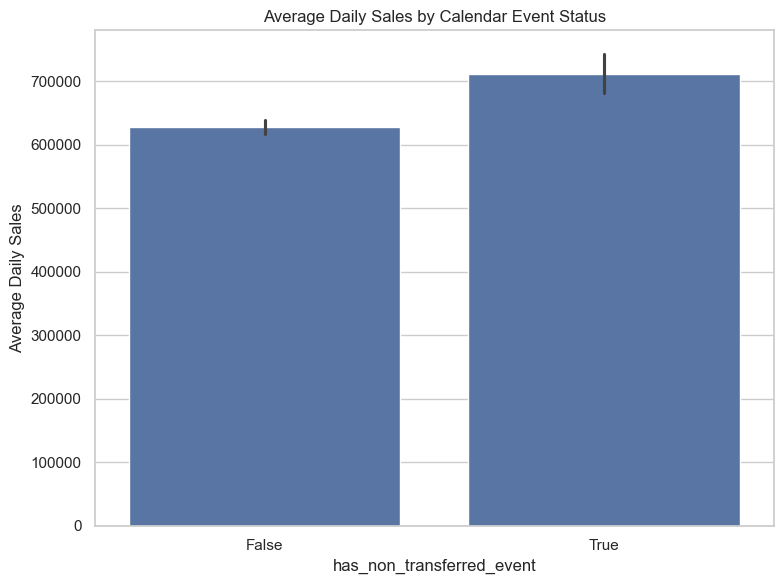

In [ ]:
event_plot_flag = (
    "has_non_transferred_event"
    if "has_non_transferred_event" in daily_holiday_sales.columns
    else "is_calendar_event"
)

plot_data = daily_holiday_sales.loc[~daily_holiday_sales["is_year_start"]].copy()

plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x=event_plot_flag,
    y="total_sales",
)

plt.title("Average Daily Sales by Calendar Event Status")
plt.xlabel(event_plot_flag)
plt.ylabel("Average Daily Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "average_daily_sales_by_calendar_event_status.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
holiday_type_summary_rows = []

for type_column in holiday_type_columns:
    event_days = daily_holiday_sales.loc[
        (daily_holiday_sales[type_column] > 0) & (~daily_holiday_sales["is_year_start"])
    ]

    non_event_days = daily_holiday_sales.loc[
        (daily_holiday_sales[type_column] == 0)
        & (~daily_holiday_sales["is_year_start"])
    ]

    if len(event_days) == 0:
        continue

    holiday_type_summary_rows.append(
        {
            "holiday_type_column": type_column,
            "event_days": event_days["date"].nunique(),
            "mean_daily_sales_when_present": event_days["total_sales"].mean(),
            "median_daily_sales_when_present": event_days["total_sales"].median(),
            "mean_daily_sales_when_absent": non_event_days["total_sales"].mean(),
            "mean_promotion_rows_pct_when_present": event_days[
                "rows_with_promotion_pct"
            ].mean(),
            "mean_zero_sales_pct_when_present": event_days["zero_sales_pct"].mean(),
        }
    )

holiday_type_sales_summary = pd.DataFrame(holiday_type_summary_rows)

if not holiday_type_sales_summary.empty:
    holiday_type_sales_summary["sales_ratio_vs_absent"] = (
        holiday_type_sales_summary["mean_daily_sales_when_present"]
        / holiday_type_sales_summary["mean_daily_sales_when_absent"]
    )

    holiday_type_sales_summary = holiday_type_sales_summary.sort_values(
        "mean_daily_sales_when_present",
        ascending=False,
    )

display(holiday_type_sales_summary)

holiday_type_sales_summary.to_csv(
    EDA_TABLES_DIR / "holiday_type_sales_summary.csv",
    index=False,
)


,holiday_type_column,event_days,mean_daily_sales_when_present,median_daily_sales_when_present,mean_daily_sales_when_absent,mean_promotion_rows_pct_when_present,mean_zero_sales_pct_when_present,sales_ratio_vs_absent
0,holiday_type_additional,38,868954.744636,921775.064868,634108.634193,0.236901,0.271915,1.370356
4,holiday_type_transfer,9,833536.042171,826373.722022,638377.679417,0.393565,0.200150,1.305710
1,holiday_type_bridge,3,796110.021751,858468.216477,639143.328724,0.328283,0.281332,1.245589
2,holiday_type_event,55,757393.537965,737819.484836,635428.512573,0.286236,0.248281,1.191941
5,holiday_type_work_day,5,663184.707506,569956.908010,639352.822861,0.180247,0.372615,1.037275
3,holiday_type_holiday,150,655881.379565,632642.687554,637809.249230,0.205316,0.309712,1.028335


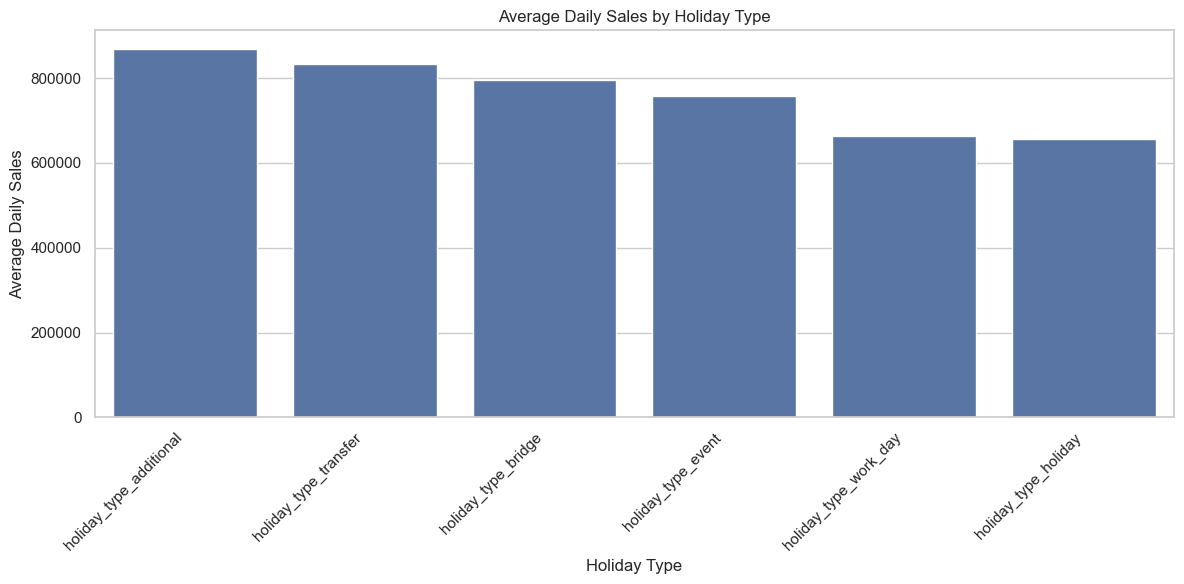

In [ ]:
if not holiday_type_sales_summary.empty:
    plot_data = holiday_type_sales_summary.loc[
        holiday_type_sales_summary["event_days"] >= 3
    ].sort_values("mean_daily_sales_when_present", ascending=False)

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=plot_data,
        x="holiday_type_column",
        y="mean_daily_sales_when_present",
    )

    plt.title("Average Daily Sales by Holiday Type")
    plt.xlabel("Holiday Type")
    plt.ylabel("Average Daily Sales")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(
        EDA_FIGURES_DIR / "average_daily_sales_by_holiday_type.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()
else:
    print("No holiday type columns available.")


In [ ]:
holiday_locale_summary_rows = []

for locale_column in holiday_locale_columns:
    event_days = daily_holiday_sales.loc[
        (daily_holiday_sales[locale_column] > 0)
        & (~daily_holiday_sales["is_year_start"])
    ]

    non_event_days = daily_holiday_sales.loc[
        (daily_holiday_sales[locale_column] == 0)
        & (~daily_holiday_sales["is_year_start"])
    ]

    if len(event_days) == 0:
        continue

    holiday_locale_summary_rows.append(
        {
            "holiday_locale_column": locale_column,
            "event_days": event_days["date"].nunique(),
            "mean_daily_sales_when_present": event_days["total_sales"].mean(),
            "median_daily_sales_when_present": event_days["total_sales"].median(),
            "mean_daily_sales_when_absent": non_event_days["total_sales"].mean(),
            "mean_promotion_rows_pct_when_present": event_days[
                "rows_with_promotion_pct"
            ].mean(),
            "mean_zero_sales_pct_when_present": event_days["zero_sales_pct"].mean(),
        }
    )

holiday_locale_sales_summary = pd.DataFrame(holiday_locale_summary_rows)

if not holiday_locale_sales_summary.empty:
    holiday_locale_sales_summary["sales_ratio_vs_absent"] = (
        holiday_locale_sales_summary["mean_daily_sales_when_present"]
        / holiday_locale_sales_summary["mean_daily_sales_when_absent"]
    )

    holiday_locale_sales_summary = holiday_locale_sales_summary.sort_values(
        "mean_daily_sales_when_present",
        ascending=False,
    )

display(holiday_locale_sales_summary)

holiday_locale_sales_summary.to_csv(
    EDA_TABLES_DIR / "holiday_locale_sales_summary.csv",
    index=False,
)


,holiday_locale_column,event_days,mean_daily_sales_when_present,median_daily_sales_when_present,mean_daily_sales_when_absent,mean_promotion_rows_pct_when_present,mean_zero_sales_pct_when_present,sales_ratio_vs_absent
1,holiday_locale_national,138,761470.791884,742923.217484,628494.211374,0.248922,0.278201,1.211580
2,holiday_locale_regional,18,689644.310719,575724.319392,638879.561357,0.200804,0.307488,1.079459
0,holiday_locale_local,106,646984.178050,635344.699148,638914.320492,0.218591,0.301643,1.012631


In [ ]:
future_holiday_features = (
    test_base[["date"] + holiday_feature_columns]
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

future_holiday_summary = pd.DataFrame(
    [
        {
            "forecast_start_date": future_holiday_features["date"].min(),
            "forecast_end_date": future_holiday_features["date"].max(),
            "forecast_horizon_days": future_holiday_features["date"].nunique(),
            "future_calendar_event_days": (
                future_holiday_features["is_calendar_event"].sum()
                if "is_calendar_event" in future_holiday_features.columns
                else np.nan
            ),
            "future_non_transferred_event_days": (
                future_holiday_features["has_non_transferred_event"].sum()
                if "has_non_transferred_event" in future_holiday_features.columns
                else np.nan
            ),
            "future_transferred_event_days": (
                future_holiday_features["has_transferred_event"].sum()
                if "has_transferred_event" in future_holiday_features.columns
                else np.nan
            ),
            "future_total_calendar_event_count": (
                future_holiday_features["calendar_event_count"].sum()
                if "calendar_event_count" in future_holiday_features.columns
                else np.nan
            ),
            "future_total_non_transferred_event_count": (
                future_holiday_features["non_transferred_event_count"].sum()
                if "non_transferred_event_count" in future_holiday_features.columns
                else np.nan
            ),
        }
    ]
)

display(future_holiday_features)
display(future_holiday_summary)

future_holiday_features.to_csv(
    EDA_TABLES_DIR / "future_holiday_features.csv",
    index=False,
)

future_holiday_summary.to_csv(
    EDA_TABLES_DIR / "future_holiday_summary.csv",
    index=False,
)


,date,calendar_event_count,transferred_event_count,unique_locale_names,non_transferred_event_count,is_calendar_event,has_non_transferred_event,has_transferred_event,holiday_type_additional,holiday_type_bridge,holiday_type_event,holiday_type_holiday,holiday_type_transfer,holiday_type_work_day,holiday_locale_local,holiday_locale_national,holiday_locale_regional
0,2017-08-16,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
1,2017-08-17,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
2,2017-08-18,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
3,2017-08-19,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
4,2017-08-20,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
5,2017-08-21,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
6,2017-08-22,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
7,2017-08-23,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0
8,2017-08-24,1,0,1,1,True,True,False,0,0,0,1,0,0,1,0,0
9,2017-08-25,0,0,0,0,False,False,False,0,0,0,0,0,0,0,0,0


,forecast_start_date,forecast_end_date,forecast_horizon_days,future_calendar_event_days,future_non_transferred_event_days,future_transferred_event_days,future_total_calendar_event_count,future_total_non_transferred_event_count
0,2017-08-16,2017-08-31,16,1,1,0,1,1


In [ ]:
holiday_analysis_key_findings_rows = []

if "has_non_transferred_event" in holiday_event_sales_summary["holiday_flag"].unique():
    event_summary = holiday_event_sales_summary.loc[
        (holiday_event_sales_summary["holiday_flag"] == "has_non_transferred_event")
        & (holiday_event_sales_summary["exclude_year_start"])
    ].copy()

    if set(event_summary["has_non_transferred_event"].astype(bool)) == {False, True}:
        event_mean_sales = event_summary.loc[
            event_summary["has_non_transferred_event"].astype(bool),
            "mean_daily_sales",
        ].iloc[0]

        non_event_mean_sales = event_summary.loc[
            ~event_summary["has_non_transferred_event"].astype(bool),
            "mean_daily_sales",
        ].iloc[0]

        holiday_analysis_key_findings_rows.append(
            {
                "finding": "non_transferred_event_sales_ratio",
                "value": "event_days_vs_non_event_days",
                "metric": "mean_daily_sales_ratio",
                "metric_value": event_mean_sales / non_event_mean_sales,
            }
        )

if not holiday_type_sales_summary.empty:
    top_holiday_type = (
        holiday_type_sales_summary.loc[holiday_type_sales_summary["event_days"] >= 3]
        .sort_values("mean_daily_sales_when_present", ascending=False)
        .head(1)
    )

    if not top_holiday_type.empty:
        holiday_analysis_key_findings_rows.append(
            {
                "finding": "highest_average_sales_holiday_type",
                "value": top_holiday_type.iloc[0]["holiday_type_column"],
                "metric": "mean_daily_sales_when_present",
                "metric_value": top_holiday_type.iloc[0][
                    "mean_daily_sales_when_present"
                ],
            }
        )

if not holiday_locale_sales_summary.empty:
    top_holiday_locale = holiday_locale_sales_summary.sort_values(
        "mean_daily_sales_when_present", ascending=False
    ).head(1)

    holiday_analysis_key_findings_rows.append(
        {
            "finding": "highest_average_sales_holiday_locale",
            "value": top_holiday_locale.iloc[0]["holiday_locale_column"],
            "metric": "mean_daily_sales_when_present",
            "metric_value": top_holiday_locale.iloc[0]["mean_daily_sales_when_present"],
        }
    )

holiday_analysis_key_findings_rows.append(
    {
        "finding": "future_non_transferred_event_days",
        "value": "test_base",
        "metric": "days",
        "metric_value": future_holiday_summary[
            "future_non_transferred_event_days"
        ].iloc[0],
    }
)

holiday_analysis_key_findings = pd.DataFrame(holiday_analysis_key_findings_rows)

display(holiday_analysis_key_findings)

holiday_analysis_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "holiday_analysis_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,non_transferred_event_sales_ratio,event_days_vs_non_event_days,mean_daily_sales_ratio,1.133230
1,highest_average_sales_holiday_type,holiday_type_additional,mean_daily_sales_when_present,868954.744636
2,highest_average_sales_holiday_locale,holiday_locale_national,mean_daily_sales_when_present,761470.791884
3,future_non_transferred_event_days,test_base,days,1.000000


### Business conclusion

Calendar events are associated with different historical sales behavior.

After excluding January 1st, non-transferred event days show higher average daily sales than regular days. This suggests that event-related calendar signals may be useful for future demand forecasting.

The strongest descriptive effects appear in additional, transfer, bridge, and event-type holidays. National events also show higher average sales than local or regional events, although the current date-level aggregation does not fully assign local events to individual stores.

The future 16-day forecasting horizon includes one non-transferred calendar event. This means that holiday variables may still matter for the final forecast, even if the test period has limited event exposure.

These findings support the inclusion of holiday and event variables in future feature engineering, but they should be treated as contextual signals rather than standalone explanations of demand.


# 13.Oil Price Analysis

This section explores the relationship between oil prices and historical sales.

Oil price is treated as a contextual macroeconomic variable. The goal is to assess whether it may provide useful signal for future forecasting.

This analysis is descriptive and does not assume a direct causal relationship between oil prices and store sales.


In [ ]:
oil_columns = [
    column
    for column in train_base.columns
    if "oil" in column.lower() or "dcoil" in column.lower()
]

oil_columns


['dcoilwtico',
 'oil_row_exists_in_raw',
 'dcoilwtico_missing_before_imputation',
 'dcoilwtico_was_imputed']

In [ ]:
oil_value_column = "dcoilwtico"

if oil_value_column not in train_base.columns:
    raise ValueError(f"Expected oil column not found: {oil_value_column}")

daily_oil_sales = train_base.groupby("date", as_index=False).agg(
    total_sales=("sales", "sum"),
    total_promotion_units=("onpromotion", "sum"),
    rows_with_promotion=("onpromotion", lambda x: (x > 0).sum()),
    total_rows=("sales", "size"),
    oil_price=(oil_value_column, "first"),
)

daily_oil_sales["rows_with_promotion_pct"] = (
    daily_oil_sales["rows_with_promotion"] / daily_oil_sales["total_rows"]
)

daily_oil_sales["year"] = daily_oil_sales["date"].dt.year
daily_oil_sales["month"] = daily_oil_sales["date"].dt.month

display(daily_oil_sales.head())

daily_oil_sales.to_csv(
    EDA_TABLES_DIR / "daily_oil_sales_summary.csv",
    index=False,
)


,date,total_sales,total_promotion_units,rows_with_promotion,total_rows,oil_price,rows_with_promotion_pct,year,month
0,2013-01-01,2511.618999,0,0,1782,93.14,0.0,2013,1
1,2013-01-02,496092.417944,0,0,1782,93.14,0.0,2013,1
2,2013-01-03,361461.231124,0,0,1782,92.97,0.0,2013,1
3,2013-01-04,354459.677093,0,0,1782,93.12,0.0,2013,1
4,2013-01-05,477350.121229,0,0,1782,93.12,0.0,2013,1


In [ ]:
oil_sales_summary = pd.DataFrame(
    [
        {
            "metric": "oil_price_min",
            "value": daily_oil_sales["oil_price"].min(),
        },
        {
            "metric": "oil_price_max",
            "value": daily_oil_sales["oil_price"].max(),
        },
        {
            "metric": "oil_price_mean",
            "value": daily_oil_sales["oil_price"].mean(),
        },
        {
            "metric": "oil_price_median",
            "value": daily_oil_sales["oil_price"].median(),
        },
        {
            "metric": "oil_price_missing_days",
            "value": daily_oil_sales["oil_price"].isna().sum(),
        },
        {
            "metric": "pearson_daily_oil_sales_correlation",
            "value": daily_oil_sales["oil_price"].corr(
                daily_oil_sales["total_sales"],
                method="pearson",
            ),
        },
        {
            "metric": "spearman_daily_oil_sales_correlation",
            "value": daily_oil_sales["oil_price"]
            .rank()
            .corr(
                daily_oil_sales["total_sales"].rank(),
                method="pearson",
            ),
        },
    ]
)

display(oil_sales_summary)

oil_sales_summary.to_csv(
    EDA_TABLES_DIR / "oil_sales_summary.csv",
    index=False,
)


,metric,value
0,oil_price_min,26.190000
1,oil_price_max,110.620000
2,oil_price_mean,67.924899
3,oil_price_median,53.410000
4,oil_price_missing_days,0.000000
5,pearson_daily_oil_sales_correlation,-0.626889
6,spearman_daily_oil_sales_correlation,-0.608241


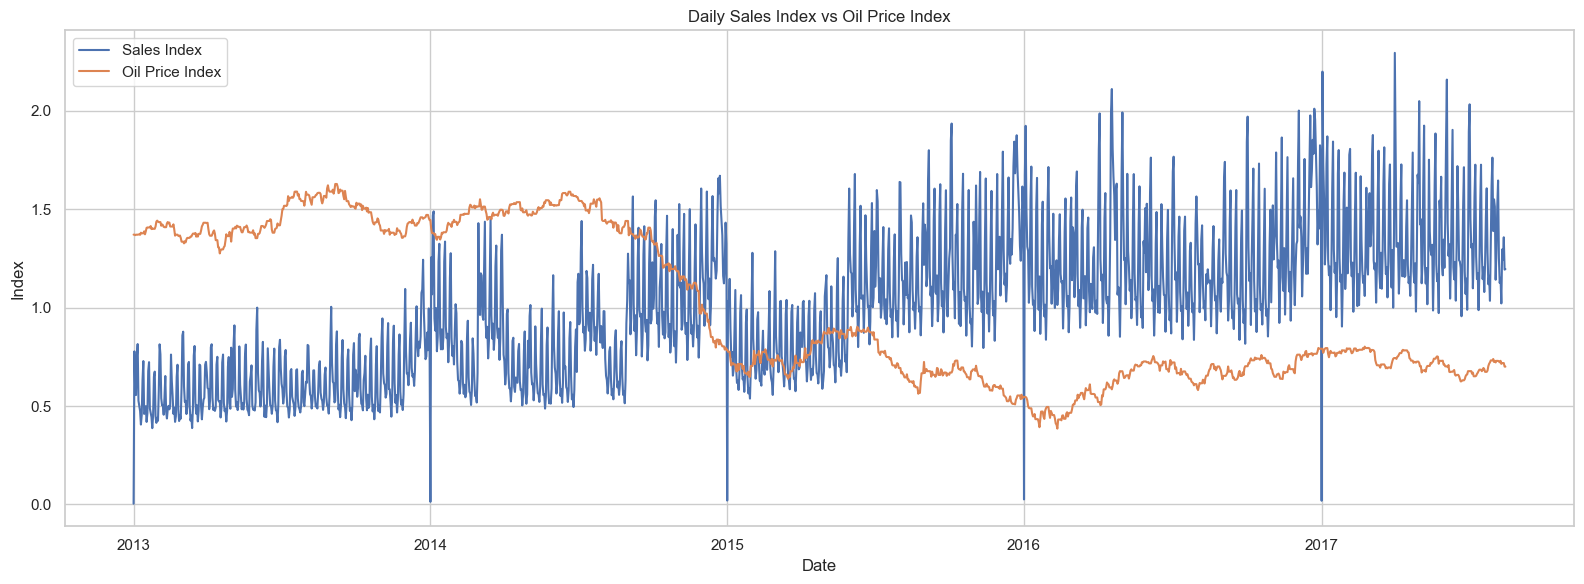

In [ ]:
daily_oil_sales_plot = daily_oil_sales.copy()

daily_oil_sales_plot["sales_index"] = (
    daily_oil_sales_plot["total_sales"] / daily_oil_sales_plot["total_sales"].mean()
)

daily_oil_sales_plot["oil_price_index"] = (
    daily_oil_sales_plot["oil_price"] / daily_oil_sales_plot["oil_price"].mean()
)

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=daily_oil_sales_plot,
    x="date",
    y="sales_index",
    label="Sales Index",
    linewidth=1.5,
)

sns.lineplot(
    data=daily_oil_sales_plot,
    x="date",
    y="oil_price_index",
    label="Oil Price Index",
    linewidth=1.5,
)

plt.title("Daily Sales Index vs Oil Price Index")
plt.xlabel("Date")
plt.ylabel("Index")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_index_vs_oil_price_index.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


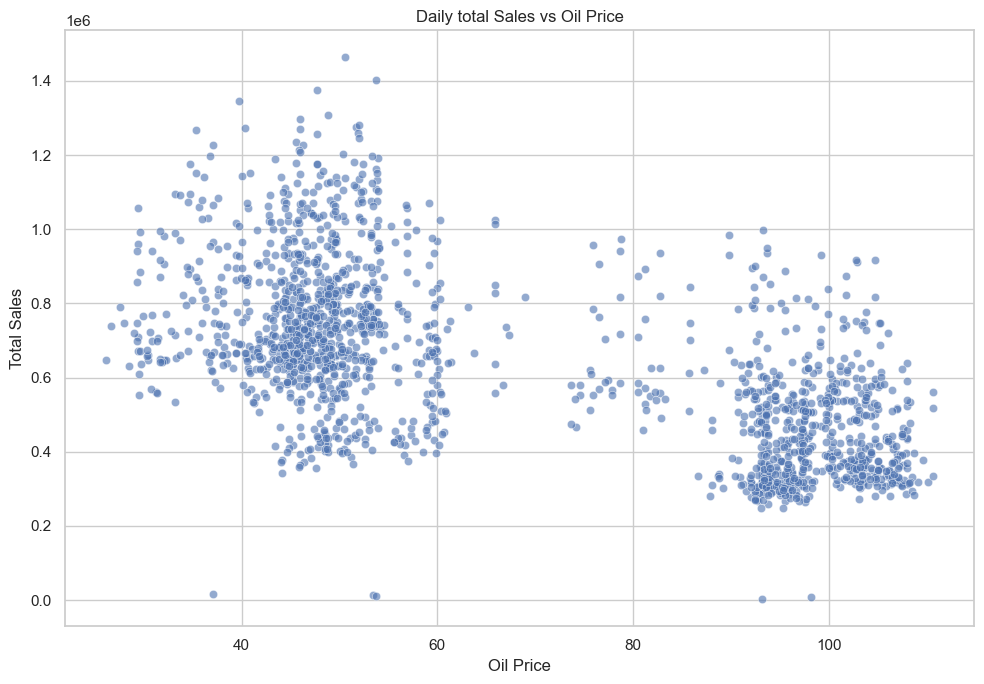

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=daily_oil_sales,
    x="oil_price",
    y="total_sales",
    alpha=0.6,
)

plt.title("Daily total Sales vs Oil Price")
plt.xlabel("Oil Price")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_vs_oil_price.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
monthly_oil_sales = (
    daily_oil_sales.set_index("date")
    .resample("MS")
    .agg(
        total_sales=("total_sales", "sum"),
        mean_daily_sales=("total_sales", "mean"),
        median_daily_sales=("total_sales", "median"),
        mean_oil_price=("oil_price", "mean"),
        median_oil_price=("oil_price", "median"),
        total_promotion_units=("total_promotion_units", "sum"),
        mean_promotion_rows_pct=("rows_with_promotion_pct", "mean"),
    )
    .reset_index()
)

monthly_oil_sales["sales_index"] = (
    monthly_oil_sales["mean_daily_sales"] / monthly_oil_sales["mean_daily_sales"].mean()
)

monthly_oil_sales["oil_price_index"] = (
    monthly_oil_sales["mean_oil_price"] / monthly_oil_sales["mean_oil_price"].mean()
)

display(monthly_oil_sales.head())

monthly_oil_sales.to_csv(
    EDA_TABLES_DIR / "monthly_oil_sales_summary.csv",
    index=False,
)


,date,total_sales,mean_daily_sales,median_daily_sales,mean_oil_price,median_oil_price,total_promotion_units,mean_promotion_rows_pct,sales_index,oil_price_index
0,2013-01-01,1.032762e+07,333149.185062,302530.809018,94.632258,94.28,0,0.0,0.521326,1.396731
1,2013-02-01,9.658960e+06,344962.849194,319883.406937,95.403571,95.95,0,0.0,0.539813,1.408115
2,2013-03-01,1.142850e+07,368661.194758,332189.993189,93.217097,93.03,0,0.0,0.576897,1.375844
3,2013-04-01,1.099346e+07,366448.824600,334211.199495,91.793000,92.63,0,0.0,0.573435,1.354825
4,2013-05-01,1.159770e+07,374119.484098,335937.441949,94.654516,94.85,0,0.0,0.585438,1.397059


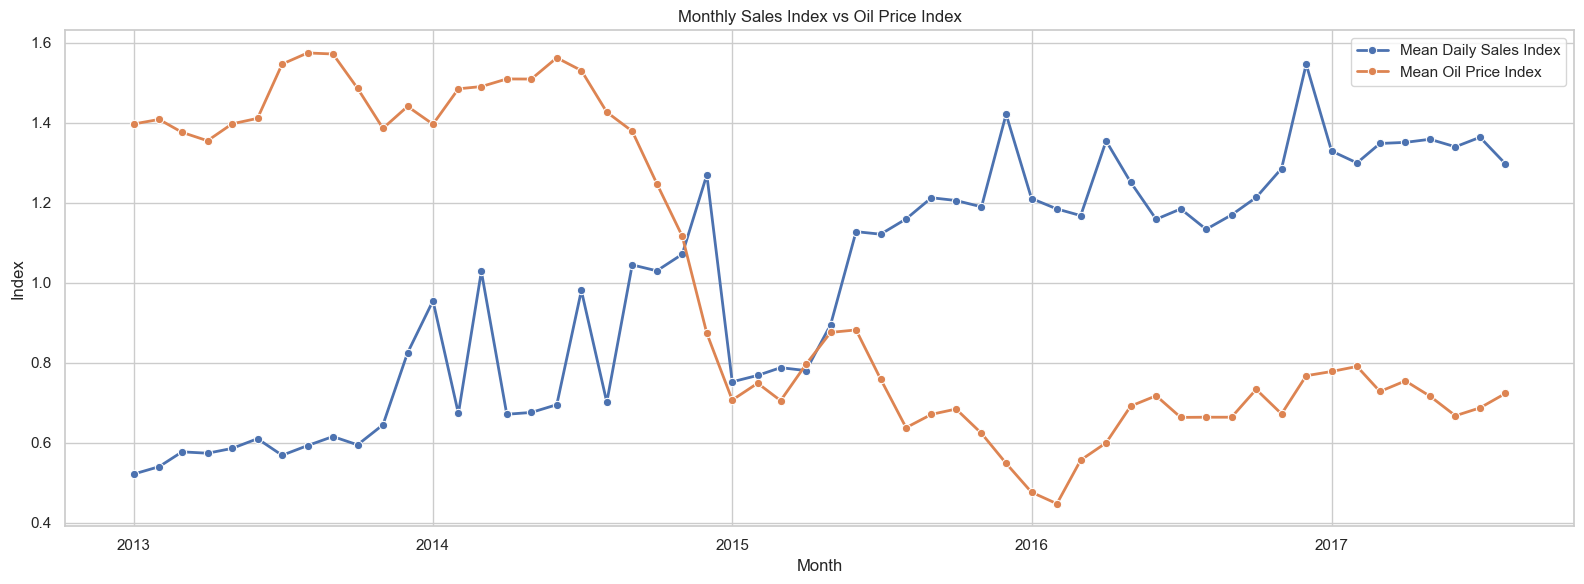

In [ ]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=monthly_oil_sales,
    x="date",
    y="sales_index",
    label="Mean Daily Sales Index",
    marker="o",
    linewidth=2,
)

sns.lineplot(
    data=monthly_oil_sales,
    x="date",
    y="oil_price_index",
    label="Mean Oil Price Index",
    marker="o",
    linewidth=2,
)

plt.title("Monthly Sales Index vs Oil Price Index")
plt.xlabel("Month")
plt.ylabel("Index")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "monthly_sales_index_vs_oil_price_index.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
future_oil_summary = test_base.groupby("date", as_index=False).agg(
    oil_price=(oil_value_column, "first"),
    total_promotion_units=("onpromotion", "sum"),
    rows_with_promotion=("onpromotion", lambda x: (x > 0).sum()),
    total_rows=("onpromotion", "size"),
)

future_oil_summary["rows_with_promotion_pct"] = (
    future_oil_summary["rows_with_promotion"] / future_oil_summary["total_rows"]
)

display(future_oil_summary)

future_oil_summary.to_csv(
    EDA_TABLES_DIR / "future_oil_summary.csv",
    index=False,
)


,date,oil_price,total_promotion_units,rows_with_promotion,total_rows,rows_with_promotion_pct
0,2017-08-16,46.80,30539,1005,1782,0.563973
1,2017-08-17,47.07,7505,695,1782,0.390011
2,2017-08-18,48.59,13777,866,1782,0.485971
3,2017-08-19,48.59,8614,789,1782,0.442761
4,2017-08-20,48.59,9513,746,1782,0.418631
5,2017-08-21,47.39,8100,714,1782,0.400673
6,2017-08-22,47.65,10295,725,1782,0.406846
7,2017-08-23,48.45,16500,750,1782,0.420875
8,2017-08-24,47.24,8268,745,1782,0.418070
9,2017-08-25,47.65,13991,853,1782,0.478676


In [ ]:
oil_analysis_key_findings = pd.DataFrame(
    [
        {
            "finding": "oil_price_min",
            "value": "train_period",
            "metric": "oil_price",
            "metric_value": daily_oil_sales["oil_price"].min(),
        },
        {
            "finding": "oil_price_max",
            "value": "train_period",
            "metric": "oil_price",
            "metric_value": daily_oil_sales["oil_price"].max(),
        },
        {
            "finding": "daily_oil_sales_pearson_correlation",
            "value": "daily_level",
            "metric": "pearson_correlation",
            "metric_value": daily_oil_sales["oil_price"].corr(
                daily_oil_sales["total_sales"],
                method="pearson",
            ),
        },
        {
            "finding": "daily_oil_sales_spearman_correlation",
            "value": "daily_level",
            "metric": "spearman_correlation",
            "metric_value": daily_oil_sales["oil_price"]
            .rank()
            .corr(
                daily_oil_sales["total_sales"].rank(),
                method="pearson",
            ),
        },
        {
            "finding": "future_oil_missing_days",
            "value": "test_base",
            "metric": "missing_days",
            "metric_value": future_oil_summary["oil_price"].isna().sum(),
        },
    ]
)

display(oil_analysis_key_findings)

oil_analysis_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "oil_analysis_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,oil_price_min,train_period,oil_price,26.190000
1,oil_price_max,train_period,oil_price,110.620000
2,daily_oil_sales_pearson_correlation,daily_level,pearson_correlation,-0.626889
3,daily_oil_sales_spearman_correlation,daily_level,spearman_correlation,-0.608241
4,future_oil_missing_days,test_base,missing_days,0.000000


### Analytical note: oil price interpretation

The oil variable represents the international WTI oil price, not necessarily the effective domestic fuel price paid by households, transport operators, or retailers in Ecuador.

This distinction matters because Ecuador has historically used fuel subsidies, which may weaken the direct pass-through between international oil prices and domestic transportation or consumer costs.

The observed negative correlation between oil price and sales should therefore not be interpreted as a direct causal relationship. It may reflect broader macroeconomic conditions, fiscal policy, long-term business growth, changes in promotion intensity, or time trend effects.

For this project, oil price should be treated as a contextual macroeconomic signal rather than a direct operational demand driver.


### Business conclusion

Oil price shows a clear negative historical correlation with aggregated sales during the training period. However, this relationship should be interpreted with strong caution.

The oil variable represents international WTI prices, not necessarily domestic fuel or transportation costs faced by consumers and businesses in Ecuador. Given the country's historical use of fuel subsidies, the pass-through from international oil prices to local economic behavior may be indirect or partially absorbed by public policy.

The negative correlation may also be influenced by long-term time trends: sales increased over the historical period while oil prices declined sharply after 2014.

For future modeling, oil price can be considered as a candidate contextual feature because it is available in the forecasting horizon and has no missing values. However, its usefulness should be validated through time-based model evaluation rather than assumed from exploratory correlation.

Oil should be interpreted as a macroeconomic context variable, not as a standalone causal explanation of store-level demand.


# 14.Transactions Analysis

This section analyzes historical store transactions and their relationship with sales.

Transactions can be interpreted as a proxy for store traffic or commercial activity. However, transactions are only available for the historical period and are not directly available for the future forecasting horizon.

For this reason, transactions are analyzed as historical business context. They must be handled carefully in future modeling to avoid leakage.


In [ ]:
transactions_clean["date"] = pd.to_datetime(transactions_clean["date"])

transactions_availability_summary = pd.DataFrame(
    [
        {
            "dataset": "transactions_clean",
            "rows": len(transactions_clean),
            "date_min": transactions_clean["date"].min(),
            "date_max": transactions_clean["date"].max(),
            "unique_dates": transactions_clean["date"].nunique(),
            "unique_stores": transactions_clean["store_nbr"].nunique(),
            "total_transactions": transactions_clean["transactions"].sum(),
            "mean_transactions_per_record": transactions_clean["transactions"].mean(),
            "median_transactions_per_record": transactions_clean[
                "transactions"
            ].median(),
            "max_transactions_per_record": transactions_clean["transactions"].max(),
        },
        {
            "dataset": "train_base",
            "rows": len(train_base),
            "date_min": train_base["date"].min(),
            "date_max": train_base["date"].max(),
            "unique_dates": train_base["date"].nunique(),
            "unique_stores": train_base["store_nbr"].nunique(),
            "total_transactions": np.nan,
            "mean_transactions_per_record": np.nan,
            "median_transactions_per_record": np.nan,
            "max_transactions_per_record": np.nan,
        },
        {
            "dataset": "test_base",
            "rows": len(test_base),
            "date_min": test_base["date"].min(),
            "date_max": test_base["date"].max(),
            "unique_dates": test_base["date"].nunique(),
            "unique_stores": test_base["store_nbr"].nunique(),
            "total_transactions": np.nan,
            "mean_transactions_per_record": np.nan,
            "median_transactions_per_record": np.nan,
            "max_transactions_per_record": np.nan,
        },
    ]
)

display(transactions_availability_summary)

transactions_availability_summary.to_csv(
    EDA_TABLES_DIR / "transactions_availability_summary.csv",
    index=False,
)


,dataset,rows,date_min,date_max,unique_dates,unique_stores,total_transactions,mean_transactions_per_record,median_transactions_per_record,max_transactions_per_record
0,transactions_clean,83488,2013-01-01,2017-08-15,1682,54,141478945.0,1694.602158,1393.0,8359.0
1,train_base,3000888,2013-01-01,2017-08-15,1684,54,NaN,NaN,NaN,NaN
2,test_base,28512,2017-08-16,2017-08-31,16,54,NaN,NaN,NaN,NaN


In [ ]:
store_day_sales = train_base.groupby(["date", "store_nbr"], as_index=False).agg(
    total_sales=("sales", "sum"),
    total_promotion_units=("onpromotion", "sum"),
    promoted_families=("onpromotion", lambda x: (x > 0).sum()),
    zero_sales_families=("sales", lambda x: (x == 0).sum()),
    total_families=("family", "nunique"),
)

store_day_sales["promoted_families_pct"] = (
    store_day_sales["promoted_families"] / store_day_sales["total_families"]
)

store_day_sales["zero_sales_families_pct"] = (
    store_day_sales["zero_sales_families"] / store_day_sales["total_families"]
)

store_day_sales_transactions = store_day_sales.merge(
    transactions_clean,
    on=["date", "store_nbr"],
    how="left",
    validate="one_to_one",
)

store_day_sales_transactions["has_transaction_record"] = store_day_sales_transactions[
    "transactions"
].notna()

store_day_sales_transactions["sales_per_transaction"] = np.where(
    store_day_sales_transactions["transactions"] > 0,
    store_day_sales_transactions["total_sales"]
    / store_day_sales_transactions["transactions"],
    np.nan,
)

display(store_day_sales_transactions.head())

store_day_sales_transactions.to_csv(
    EDA_TABLES_DIR / "store_day_sales_transactions_summary.csv",
    index=False,
)


,date,store_nbr,total_sales,total_promotion_units,promoted_families,zero_sales_families,total_families,promoted_families_pct,zero_sales_families_pct,transactions,has_transaction_record,sales_per_transaction
0,2013-01-01,1,0.0,0,0,33,33,0.0,1.0,NaN,False,NaN
1,2013-01-01,2,0.0,0,0,33,33,0.0,1.0,NaN,False,NaN
2,2013-01-01,3,0.0,0,0,33,33,0.0,1.0,NaN,False,NaN
3,2013-01-01,4,0.0,0,0,33,33,0.0,1.0,NaN,False,NaN
4,2013-01-01,5,0.0,0,0,33,33,0.0,1.0,NaN,False,NaN


In [51]:
transaction_record_coverage_summary = pd.DataFrame(
    [
        {
            "metric": "store_day_rows",
            "value": len(store_day_sales_transactions),
        },
        {
            "metric": "store_day_rows_with_transaction_record",
            "value": store_day_sales_transactions["has_transaction_record"].sum(),
        },
        {
            "metric": "store_day_rows_with_transaction_record_pct",
            "value": store_day_sales_transactions["has_transaction_record"].mean(),
        },
        {
            "metric": "store_day_rows_without_transaction_record",
            "value": (~store_day_sales_transactions["has_transaction_record"]).sum(),
        },
        {
            "metric": "store_day_rows_without_transaction_record_pct",
            "value": (~store_day_sales_transactions["has_transaction_record"]).mean(),
        },
    ]
)

display(transaction_record_coverage_summary)

transaction_record_coverage_summary.to_csv(
    EDA_TABLES_DIR / "transaction_record_coverage_summary.csv",
    index=False,
)


,metric,value
0,store_day_rows,90936.000000
1,store_day_rows_with_transaction_record,83488.000000
2,store_day_rows_with_transaction_record_pct,0.918096
3,store_day_rows_without_transaction_record,7448.000000
4,store_day_rows_without_transaction_record_pct,0.081904


In [ ]:
daily_transactions_sales = store_day_sales_transactions.groupby(
    "date", as_index=False
).agg(
    total_sales=("total_sales", "sum"),
    total_transactions=("transactions", "sum"),
    stores_with_transaction_record=("has_transaction_record", "sum"),
    total_store_rows=("store_nbr", "nunique"),
    total_promotion_units=("total_promotion_units", "sum"),
    mean_promoted_families_pct=("promoted_families_pct", "mean"),
    mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
)

daily_transactions_sales["stores_with_transaction_record_pct"] = (
    daily_transactions_sales["stores_with_transaction_record"]
    / daily_transactions_sales["total_store_rows"]
)

daily_transactions_sales["sales_per_transaction"] = np.where(
    daily_transactions_sales["total_transactions"] > 0,
    daily_transactions_sales["total_sales"]
    / daily_transactions_sales["total_transactions"],
    np.nan,
)

display(daily_transactions_sales.head())

daily_transactions_sales.to_csv(
    EDA_TABLES_DIR / "daily_transactions_sales_summary.csv",
    index=False,
)


,date,total_sales,total_transactions,stores_with_transaction_record,total_store_rows,total_promotion_units,mean_promoted_families_pct,mean_zero_sales_families_pct,stores_with_transaction_record_pct,sales_per_transaction
0,2013-01-01,2511.618999,770.0,1,54,0,0.0,0.990460,0.018519,3.261843
1,2013-01-02,496092.417944,93215.0,46,54,0,0.0,0.515152,0.851852,5.322023
2,2013-01-03,361461.231124,78504.0,46,54,0,0.0,0.522447,0.851852,4.604367
3,2013-01-04,354459.677093,78494.0,46,54,0,0.0,0.517957,0.851852,4.515755
4,2013-01-05,477350.121229,93573.0,46,54,0,0.0,0.507856,0.851852,5.101366


In [ ]:
transactions_sales_correlation_summary = pd.DataFrame(
    [
        {
            "level": "daily",
            "metric_x": "total_transactions",
            "metric_y": "total_sales",
            "correlation_type": "pearson",
            "correlation_value": daily_transactions_sales["total_transactions"].corr(
                daily_transactions_sales["total_sales"],
                method="pearson",
            ),
        },
        {
            "level": "daily",
            "metric_x": "total_transactions",
            "metric_y": "total_sales",
            "correlation_type": "spearman",
            "correlation_value": daily_transactions_sales["total_transactions"]
            .rank()
            .corr(
                daily_transactions_sales["total_sales"].rank(),
                method="pearson",
            ),
        },
        {
            "level": "store_day",
            "metric_x": "transactions",
            "metric_y": "total_sales",
            "correlation_type": "pearson",
            "correlation_value": store_day_sales_transactions.dropna(
                subset=["transactions", "total_sales"]
            )["transactions"].corr(
                store_day_sales_transactions.dropna(
                    subset=["transactions", "total_sales"]
                )["total_sales"],
                method="pearson",
            ),
        },
        {
            "level": "store_day",
            "metric_x": "transactions",
            "metric_y": "total_sales",
            "correlation_type": "spearman",
            "correlation_value": store_day_sales_transactions.dropna(
                subset=["transactions", "total_sales"]
            )["transactions"]
            .rank()
            .corr(
                store_day_sales_transactions.dropna(
                    subset=["transactions", "total_sales"]
                )["total_sales"].rank(),
                method="pearson",
            ),
        },
    ]
)

display(transactions_sales_correlation_summary)

transactions_sales_correlation_summary.to_csv(
    EDA_TABLES_DIR / "transactions_sales_correlation_summary.csv",
    index=False,
)


,level,metric_x,metric_y,correlation_type,correlation_value
0,daily,total_transactions,total_sales,pearson,0.656308
1,daily,total_transactions,total_sales,spearman,0.730979
2,store_day,transactions,total_sales,pearson,0.837384
3,store_day,transactions,total_sales,spearman,0.817464


In [ ]:
filtered_daily_transactions_sales = daily_transactions_sales.copy()

filtered_daily_transactions_sales["is_year_start"] = (
    filtered_daily_transactions_sales["date"].dt.month == 1
) & (filtered_daily_transactions_sales["date"].dt.day == 1)

filtered_daily_transactions_sales = filtered_daily_transactions_sales.loc[
    (filtered_daily_transactions_sales["stores_with_transaction_record_pct"] >= 0.85)
    & (~filtered_daily_transactions_sales["is_year_start"])
    & (filtered_daily_transactions_sales["total_transactions"] > 0)
].copy()

filtered_transactions_sales_correlation_summary = pd.DataFrame(
    [
        {
            "level": "daily_filtered",
            "filter_applied": "transaction coverage >= 85%, excluding January 1st",
            "metric_x": "total_transactions",
            "metric_y": "total_sales",
            "correlation_type": "pearson",
            "correlation_value": filtered_daily_transactions_sales[
                "total_transactions"
            ].corr(
                filtered_daily_transactions_sales["total_sales"],
                method="pearson",
            ),
        },
        {
            "level": "daily_filtered",
            "filter_applied": "transaction coverage >= 85%, excluding January 1st",
            "metric_x": "total_transactions",
            "metric_y": "total_sales",
            "correlation_type": "spearman",
            "correlation_value": filtered_daily_transactions_sales["total_transactions"]
            .rank()
            .corr(
                filtered_daily_transactions_sales["total_sales"].rank(),
                method="pearson",
            ),
        },
    ]
)

display(filtered_transactions_sales_correlation_summary)

filtered_transactions_sales_correlation_summary.to_csv(
    EDA_TABLES_DIR / "filtered_transactions_sales_correlation_summary.csv",
    index=False,
)


,level,filter_applied,metric_x,metric_y,correlation_type,correlation_value
0,daily_filtered,"transaction coverage >= 85%, excluding January...",total_transactions,total_sales,pearson,0.690382
1,daily_filtered,"transaction coverage >= 85%, excluding January...",total_transactions,total_sales,spearman,0.736258


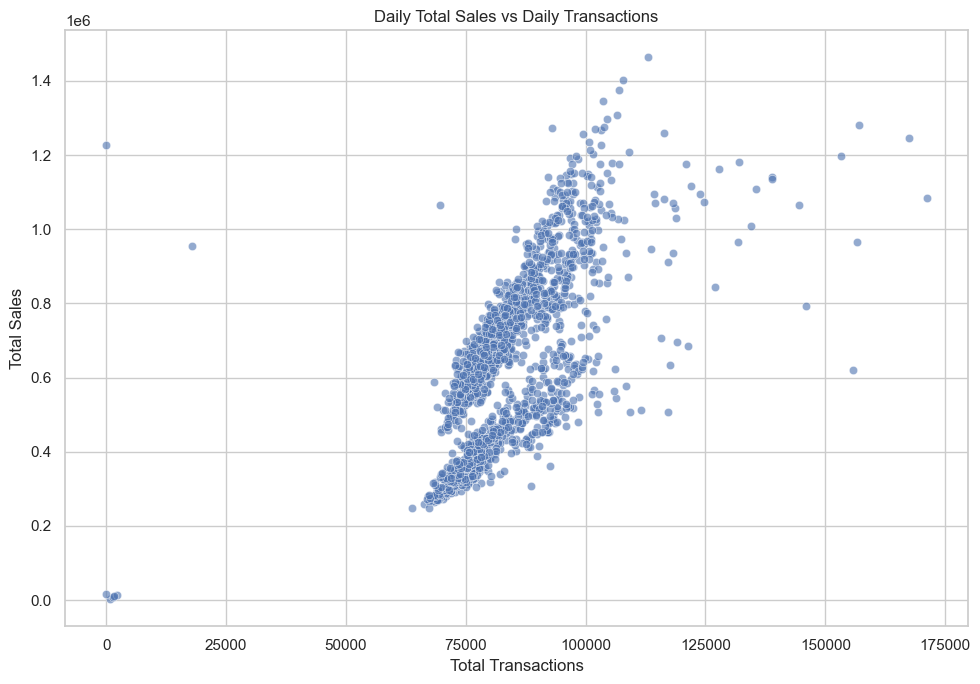

In [54]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=daily_transactions_sales,
    x="total_transactions",
    y="total_sales",
    alpha=0.6,
)

plt.title("Daily Total Sales vs Daily Transactions")
plt.xlabel("Total Transactions")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_vs_transactions.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


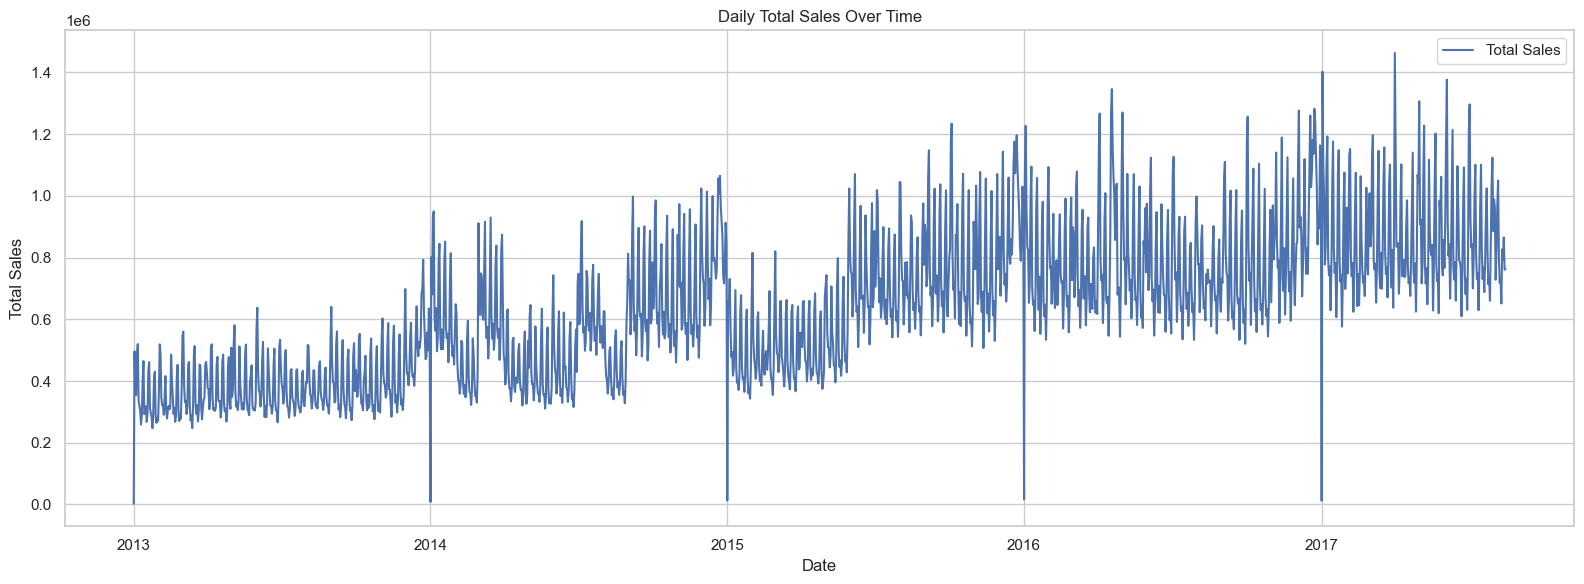

In [55]:
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=daily_transactions_sales,
    x="date",
    y="total_sales",
    label="Total Sales",
    linewidth=1.5,
)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_total_sales_for_transactions_analysis.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


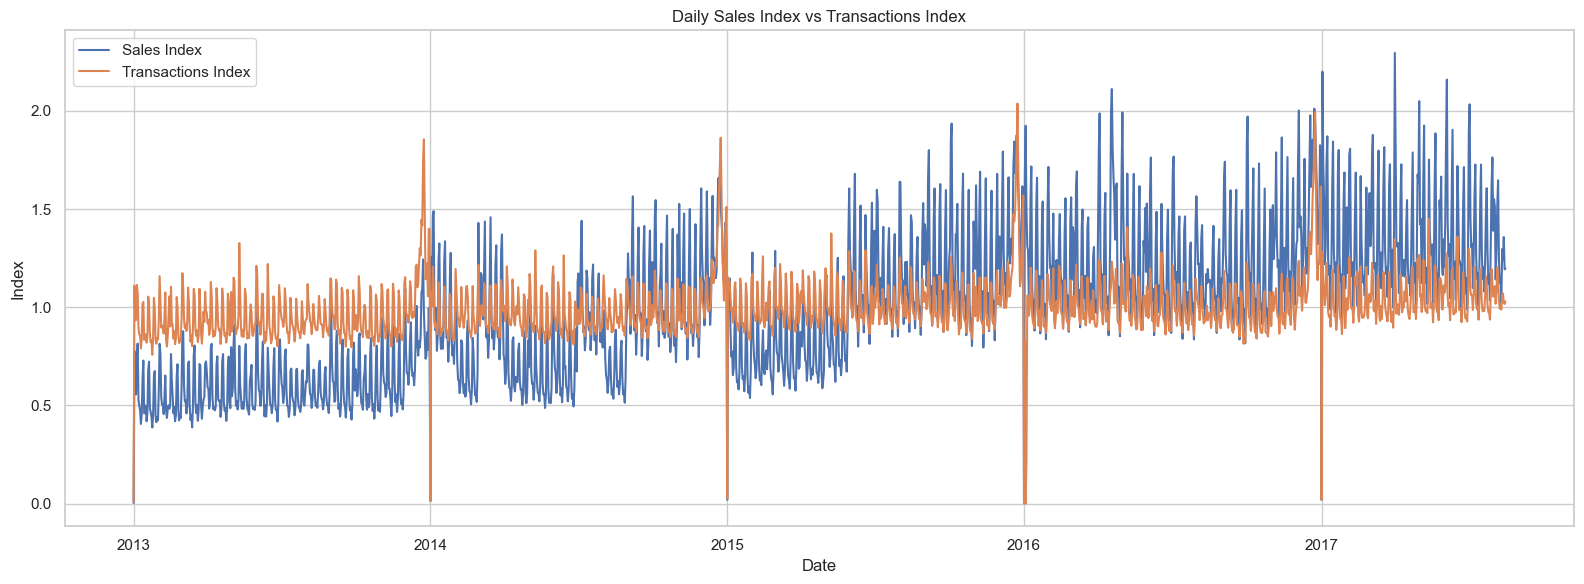

In [56]:
daily_transactions_sales_plot = daily_transactions_sales.copy()

daily_transactions_sales_plot["sales_index"] = (
    daily_transactions_sales_plot["total_sales"]
    / daily_transactions_sales_plot["total_sales"].mean()
)

daily_transactions_sales_plot["transactions_index"] = (
    daily_transactions_sales_plot["total_transactions"]
    / daily_transactions_sales_plot["total_transactions"].mean()
)

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=daily_transactions_sales_plot,
    x="date",
    y="sales_index",
    label="Sales Index",
    linewidth=1.5,
)

sns.lineplot(
    data=daily_transactions_sales_plot,
    x="date",
    y="transactions_index",
    label="Transactions Index",
    linewidth=1.5,
)

plt.title("Daily Sales Index vs Transactions Index")
plt.xlabel("Date")
plt.ylabel("Index")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_index_vs_transactions_index.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
store_transactions_summary = store_day_sales_transactions.groupby(
    "store_nbr", as_index=False
).agg(
    observed_store_days=("date", "nunique"),
    days_with_transaction_record=("has_transaction_record", "sum"),
    total_sales=("total_sales", "sum"),
    total_transactions=("transactions", "sum"),
    mean_daily_sales=("total_sales", "mean"),
    mean_daily_transactions=("transactions", "mean"),
    median_daily_transactions=("transactions", "median"),
    max_daily_transactions=("transactions", "max"),
    mean_sales_per_transaction=("sales_per_transaction", "mean"),
    median_sales_per_transaction=("sales_per_transaction", "median"),
    mean_promoted_families_pct=("promoted_families_pct", "mean"),
    mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
)

store_transactions_summary["transaction_record_coverage_pct"] = (
    store_transactions_summary["days_with_transaction_record"]
    / store_transactions_summary["observed_store_days"]
)

store_transactions_summary = store_transactions_summary.merge(
    store_metadata,
    on="store_nbr",
    how="left",
)

store_transactions_summary = store_transactions_summary.sort_values(
    "total_transactions",
    ascending=False,
).reset_index(drop=True)

display(store_transactions_summary.head(15))

store_transactions_summary.to_csv(
    EDA_TABLES_DIR / "store_transactions_summary.csv",
    index=False,
)


,store_nbr,observed_store_days,days_with_transaction_record,total_sales,total_transactions,mean_daily_sales,mean_daily_transactions,median_daily_transactions,max_daily_transactions,mean_sales_per_transaction,median_sales_per_transaction,mean_promoted_families_pct,mean_zero_sales_families_pct,transaction_record_coverage_pct,city,state,store_type,cluster
0,44,1684,1677,6.208755e+07,7273093.0,36869.093379,4336.966607,4170.0,8359.0,8.373386,8.691377,0.255668,0.179479,0.995843,Quito,Pichincha,A,5
1,47,1684,1677,5.094831e+07,6535810.0,30254.340891,3897.322600,3685.0,7727.0,7.659031,7.939006,0.265134,0.189538,0.995843,Quito,Pichincha,A,14
2,45,1684,1677,5.449801e+07,6201115.0,32362.238965,3697.742993,3515.0,7305.0,8.598246,8.889614,0.260221,0.193587,0.995843,Quito,Pichincha,A,11
3,46,1684,1677,4.189606e+07,5990113.0,24878.896747,3571.921884,3230.0,8001.0,6.823225,6.839022,0.272007,0.193209,0.995843,Quito,Pichincha,A,14
4,3,1684,1676,5.048191e+07,5366350.0,29977.381345,3201.879475,3100.5,6085.0,9.280688,9.921570,0.246869,0.181404,0.995249,Quito,Pichincha,D,8
5,48,1684,1677,3.593313e+07,5107785.0,21337.963346,3045.787120,2705.0,7044.0,6.809844,6.750667,0.269848,0.213219,0.995843,Quito,Pichincha,A,14
6,8,1684,1676,3.049429e+07,4637971.0,18108.246394,2767.285800,2740.5,5261.0,6.548804,6.620716,0.237998,0.199309,0.995249,Quito,Pichincha,D,8
7,49,1684,1677,4.342010e+07,4574103.0,25783.904860,2727.550984,2671.0,6600.0,9.112129,9.880080,0.249478,0.193479,0.995843,Quito,Pichincha,A,11
8,50,1684,1677,2.865302e+07,4384444.0,17014.857853,2614.456768,2448.0,5456.0,6.488841,6.698720,0.255074,0.206525,0.995843,Ambato,Tungurahua,A,14
9,11,1684,1676,2.832556e+07,3972488.0,16820.402899,2370.219570,2300.0,5018.0,7.083071,7.181921,0.208108,0.241039,0.995249,Cayambe,Pichincha,B,6


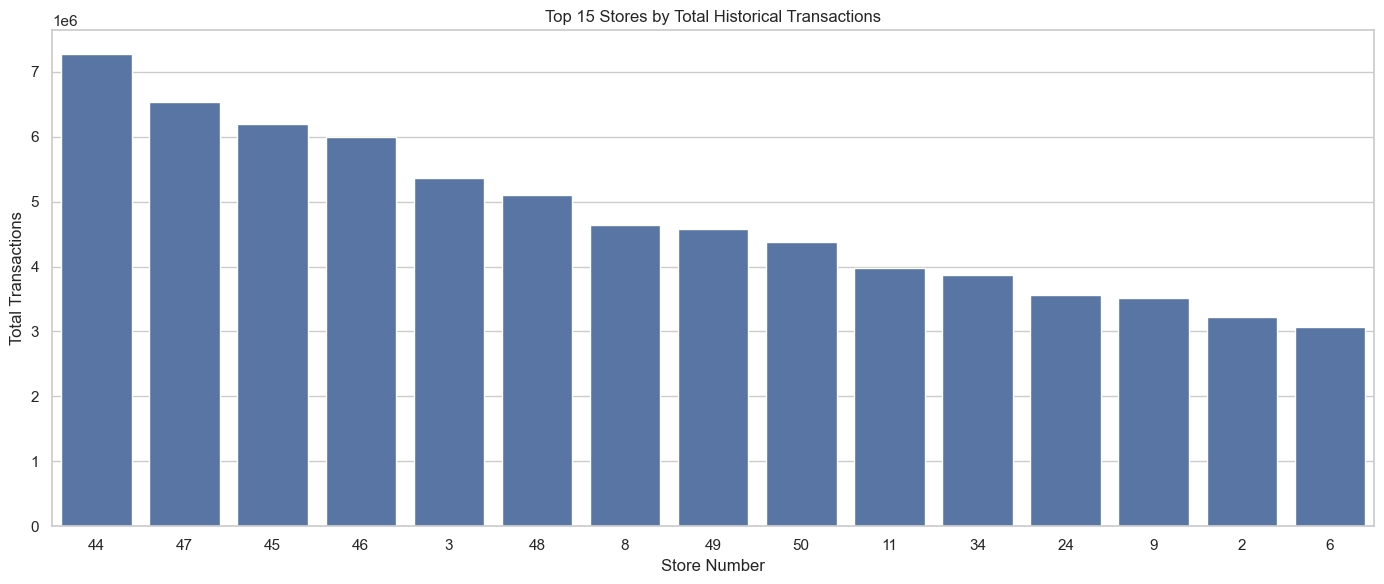

In [58]:
plt.figure(figsize=(14, 6))

top_transaction_stores = store_transactions_summary.head(15).copy()

sns.barplot(
    data=top_transaction_stores,
    x="store_nbr",
    y="total_transactions",
    order=top_transaction_stores["store_nbr"].astype(str),
)

plt.title("Top 15 Stores by Total Historical Transactions")
plt.xlabel("Store Number")
plt.ylabel("Total Transactions")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "top_15_stores_by_total_transactions.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
sales_per_transaction_summary = store_transactions_summary.sort_values(
    "mean_sales_per_transaction", ascending=False
).loc[
    :,
    [
        "store_nbr",
        "total_sales",
        "total_transactions",
        "mean_daily_sales",
        "mean_daily_transactions",
        "mean_sales_per_transaction",
        "median_sales_per_transaction",
        "transaction_record_coverage_pct",
    ]
    + [
        column
        for column in ["city", "state", store_type_column, "cluster"]
        if column in store_transactions_summary.columns
    ],
]

display(sales_per_transaction_summary.head(15))

sales_per_transaction_summary.to_csv(
    EDA_TABLES_DIR / "sales_per_transaction_summary.csv",
    index=False,
)


,store_nbr,total_sales,total_transactions,mean_daily_sales,mean_daily_transactions,mean_sales_per_transaction,median_sales_per_transaction,transaction_record_coverage_pct,city,state,store_type,cluster
16,51,3.291149e+07,2873614.0,19543.639868,1713.544425,11.426927,12.111194,0.995843,Guayaquil,Guayas,A,17
51,42,8.945768e+06,802646.0,5312.213709,1114.786111,11.049398,10.934350,0.427553,Cuenca,Azuay,D,2
50,21,9.255506e+06,842891.0,5496.143652,1126.859626,10.904381,10.692128,0.444181,Santo Domingo,Santo Domingo de los Tsachilas,B,6
53,52,2.696170e+06,275393.0,1601.050910,2333.838983,9.851104,9.822271,0.070071,Manta,Manabi,A,11
49,29,9.725158e+06,981448.0,5775.034261,1122.938215,9.727457,9.627284,0.519002,Guayaquil,Guayas,E,10
4,3,5.048191e+07,5366350.0,29977.381345,3201.879475,9.280688,9.921570,0.995249,Quito,Pichincha,D,8
44,53,1.121617e+07,1180082.0,6660.431878,1011.209940,9.137967,9.245192,0.692993,Manta,Manabi,D,13
7,49,4.342010e+07,4574103.0,25783.904860,2727.550984,9.112129,9.880080,0.995843,Quito,Pichincha,A,11
33,28,1.838315e+07,1957594.0,10916.362728,1167.319022,9.037876,9.132100,0.995843,Guayaquil,Guayas,E,10
15,7,2.695205e+07,2995993.0,16004.780037,1788.652537,8.929264,9.731681,0.994656,Quito,Pichincha,D,8


In [ ]:
future_transactions_warning = pd.DataFrame(
    [
        {
            "dataset": "transactions_clean",
            "date_min": transactions_clean["date"].min(),
            "date_max": transactions_clean["date"].max(),
            "available_for_train_period": transactions_clean["date"].max()
            <= train_base["date"].max(),
            "available_for_test_period": transactions_clean["date"].max()
            >= test_base["date"].max(),
            "modeling_risk": "Direct use of future transactions would create leakage because transactions are not available for the test horizon.",
        }
    ]
)

display(future_transactions_warning)

future_transactions_warning.to_csv(
    EDA_SUMMARIES_DIR / "future_transactions_warning.csv",
    index=False,
)


,dataset,date_min,date_max,available_for_train_period,available_for_test_period,modeling_risk
0,transactions_clean,2013-01-01,2017-08-15,True,False,Direct use of future transactions would create...


In [ ]:
transactions_analysis_key_findings = pd.DataFrame(
    [
        {
            "finding": "daily_transactions_sales_pearson_correlation",
            "value": "daily_level",
            "metric": "pearson_correlation",
            "metric_value": transactions_sales_correlation_summary.loc[
                (transactions_sales_correlation_summary["level"] == "daily")
                & (
                    transactions_sales_correlation_summary["correlation_type"]
                    == "pearson"
                ),
                "correlation_value",
            ].iloc[0],
        },
        {
            "finding": "daily_transactions_sales_spearman_correlation",
            "value": "daily_level",
            "metric": "spearman_correlation",
            "metric_value": transactions_sales_correlation_summary.loc[
                (transactions_sales_correlation_summary["level"] == "daily")
                & (
                    transactions_sales_correlation_summary["correlation_type"]
                    == "spearman"
                ),
                "correlation_value",
            ].iloc[0],
        },
        {
            "finding": "highest_transactions_store",
            "value": store_transactions_summary.iloc[0]["store_nbr"],
            "metric": "total_transactions",
            "metric_value": store_transactions_summary.iloc[0]["total_transactions"],
        },
        {
            "finding": "highest_mean_sales_per_transaction_store",
            "value": sales_per_transaction_summary.iloc[0]["store_nbr"],
            "metric": "mean_sales_per_transaction",
            "metric_value": sales_per_transaction_summary.iloc[0][
                "mean_sales_per_transaction"
            ],
        },
        {
            "finding": "transactions_available_for_test_period",
            "value": "test_base",
            "metric": "available",
            "metric_value": future_transactions_warning[
                "available_for_test_period"
            ].iloc[0],
        },
    ]
)

display(transactions_analysis_key_findings)

transactions_analysis_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "transactions_analysis_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,daily_transactions_sales_pearson_correlation,daily_level,pearson_correlation,0.656308
1,daily_transactions_sales_spearman_correlation,daily_level,spearman_correlation,0.730979
2,highest_transactions_store,44,total_transactions,7273093.0
3,highest_mean_sales_per_transaction_store,51,mean_sales_per_transaction,11.426927
4,transactions_available_for_test_period,test_base,available,False


### Business conclusion

Transactions are strongly associated with historical sales and provide a useful proxy for store activity.

At both daily and store-day levels, higher transaction volume is associated with higher sales. This suggests that customer traffic or commercial activity explains an important part of demand behavior.

However, transaction records are not available for the future forecasting horizon. Using future transactions directly as model inputs would create leakage.

Transaction coverage is also not perfect across all store-day combinations. Some special low-activity days, such as January 1st, have limited transaction records and should be interpreted carefully.

For future modeling, transactions may be useful for historical diagnostics or lagged historical signals, but they should not be used as direct future-known variables.

From a business perspective, transactions help distinguish between stores with higher demand because of more customer activity and stores with higher sales value per transaction.


# 15.Anomaly and Outlier Review

This section reviews unusual sales patterns across dates, stores, and product families.

The objective is not to remove outliers automatically, but to identify which observations may represent real demand shocks, operational closures, promotional effects, or sparse-demand behavior.

For replenishment forecasting, outliers are important because extreme demand days can create stockout risk, while abnormal low-sales days can distort model learning if interpreted as regular demand.


In [ ]:
daily_anomaly_reference = daily_sales.copy()

daily_anomaly_reference["is_year_start"] = (
    daily_anomaly_reference["date"].dt.month == 1
) & (daily_anomaly_reference["date"].dt.day == 1)

daily_sales_q1 = daily_anomaly_reference["total_sales"].quantile(0.25)
daily_sales_q3 = daily_anomaly_reference["total_sales"].quantile(0.75)
daily_sales_iqr = daily_sales_q3 - daily_sales_q1

daily_sales_lower_bound = daily_sales_q1 - 1.5 * daily_sales_iqr
daily_sales_upper_bound = daily_sales_q3 + 1.5 * daily_sales_iqr

daily_sales_p01 = daily_anomaly_reference["total_sales"].quantile(0.01)
daily_sales_p99 = daily_anomaly_reference["total_sales"].quantile(0.99)

daily_anomaly_reference["iqr_anomaly_flag"] = np.select(
    [
        daily_anomaly_reference["total_sales"] < daily_sales_lower_bound,
        daily_anomaly_reference["total_sales"] > daily_sales_upper_bound,
    ],
    [
        "low_iqr_anomaly",
        "high_iqr_anomaly",
    ],
    default="regular",
)

daily_anomaly_reference["percentile_anomaly_flag"] = np.select(
    [
        daily_anomaly_reference["total_sales"] <= daily_sales_p01,
        daily_anomaly_reference["total_sales"] >= daily_sales_p99,
    ],
    [
        "bottom_1_pct",
        "top_1_pct",
    ],
    default="regular",
)

daily_anomaly_thresholds = pd.DataFrame(
    [
        {"metric": "daily_sales_q1", "value": daily_sales_q1},
        {"metric": "daily_sales_q3", "value": daily_sales_q3},
        {"metric": "daily_sales_iqr", "value": daily_sales_iqr},
        {"metric": "daily_sales_lower_iqr_bound", "value": daily_sales_lower_bound},
        {"metric": "daily_sales_upper_iqr_bound", "value": daily_sales_upper_bound},
        {"metric": "daily_sales_p01", "value": daily_sales_p01},
        {"metric": "daily_sales_p99", "value": daily_sales_p99},
    ]
)

display(daily_anomaly_thresholds)

daily_anomaly_reference.to_csv(
    EDA_TABLES_DIR / "daily_anomaly_reference.csv",
    index=False,
)

daily_anomaly_thresholds.to_csv(
    EDA_TABLES_DIR / "daily_anomaly_thresholds.csv",
    index=False,
)


,metric,value
0,daily_sales_q1,4.427115e+05
1,daily_sales_q3,7.859455e+05
2,daily_sales_iqr,3.432340e+05
3,daily_sales_lower_iqr_bound,-7.213951e+04
4,daily_sales_upper_iqr_bound,1.300796e+06
5,daily_sales_p01,2.728480e+05
6,daily_sales_p99,1.215894e+06


In [ ]:
daily_high_anomaly_candidates = (
    daily_anomaly_reference.loc[
        (daily_anomaly_reference["iqr_anomaly_flag"] == "high_iqr_anomaly")
        | (daily_anomaly_reference["percentile_anomaly_flag"] == "top_1_pct")
    ]
    .sort_values("total_sales", ascending=False)
    .loc[
        :,
        [
            "date",
            "total_sales",
            "total_promotion_units",
            "rows_with_promotion_pct",
            "zero_sales_pct",
            "iqr_anomaly_flag",
            "percentile_anomaly_flag",
            "is_year_start",
        ],
    ]
)

daily_low_anomaly_candidates = (
    daily_anomaly_reference.loc[
        (daily_anomaly_reference["iqr_anomaly_flag"] == "low_iqr_anomaly")
        | (daily_anomaly_reference["percentile_anomaly_flag"] == "bottom_1_pct")
        | (daily_anomaly_reference["is_year_start"])
    ]
    .sort_values("total_sales", ascending=True)
    .loc[
        :,
        [
            "date",
            "total_sales",
            "total_promotion_units",
            "rows_with_promotion_pct",
            "zero_sales_pct",
            "iqr_anomaly_flag",
            "percentile_anomaly_flag",
            "is_year_start",
        ],
    ]
)

display(daily_high_anomaly_candidates.head(20))
display(daily_low_anomaly_candidates.head(20))

daily_high_anomaly_candidates.to_csv(
    EDA_TABLES_DIR / "daily_high_anomaly_candidates.csv",
    index=False,
)

daily_low_anomaly_candidates.to_csv(
    EDA_TABLES_DIR / "daily_low_anomaly_candidates.csv",
    index=False,
)


,date,total_sales,total_promotion_units,rows_with_promotion_pct,zero_sales_pct,iqr_anomaly_flag,percentile_anomaly_flag,is_year_start
1547,2017-04-01,1.463084e+06,7450,0.400673,0.156004,high_iqr_anomaly,top_1_pct,False
1458,2017-01-02,1.402306e+06,11812,0.479798,0.135802,high_iqr_anomaly,top_1_pct,False
1611,2017-06-04,1.376512e+06,10512,0.439955,0.119529,high_iqr_anomaly,top_1_pct,False
1200,2016-04-18,1.345921e+06,4075,0.322110,0.173401,high_iqr_anomaly,top_1_pct,False
1577,2017-05-01,1.306699e+06,12733,0.497755,0.109428,high_iqr_anomaly,top_1_pct,False
1639,2017-07-02,1.296379e+06,13882,0.451178,0.115600,regular,top_1_pct,False
1449,2016-12-23,1.282146e+06,21531,0.533109,0.152076,regular,top_1_pct,False
1430,2016-12-04,1.276195e+06,15186,0.466330,0.141414,regular,top_1_pct,False
1199,2016-04-17,1.271834e+06,4986,0.314815,0.191919,regular,top_1_pct,False
1213,2016-05-01,1.270121e+06,12056,0.383838,0.175084,regular,top_1_pct,False


,date,total_sales,total_promotion_units,rows_with_promotion_pct,zero_sales_pct,iqr_anomaly_flag,percentile_anomaly_flag,is_year_start
0,2013-01-01,2511.618999,0,0.000000,0.990460,regular,bottom_1_pct,True
364,2014-01-01,8602.065404,0,0.000000,0.971942,regular,bottom_1_pct,True
1457,2017-01-01,12082.500997,170,0.008418,0.984287,regular,bottom_1_pct,True
728,2015-01-01,12773.616980,12,0.002806,0.987093,regular,bottom_1_pct,True
1092,2016-01-01,16433.394000,159,0.005612,0.983726,regular,bottom_1_pct,True
23,2013-01-24,247245.690995,0,0.000000,0.528620,regular,bottom_1_pct,False
72,2013-03-14,247541.420096,0,0.000000,0.516835,regular,bottom_1_pct,False
9,2013-01-10,258982.003049,0,0.000000,0.518519,regular,bottom_1_pct,False
28,2013-01-29,264488.818077,0,0.000000,0.524130,regular,bottom_1_pct,False
177,2013-06-27,266525.458966,0,0.000000,0.498316,regular,bottom_1_pct,False


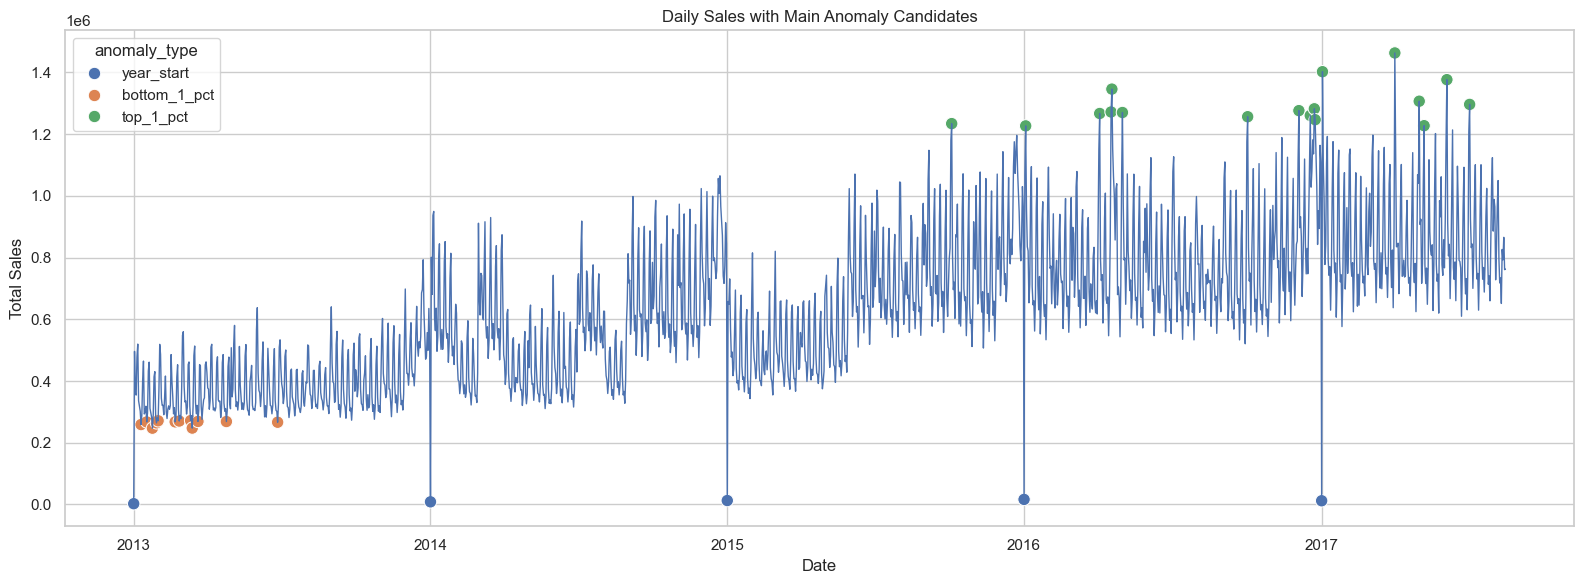

In [65]:
daily_anomaly_plot_data = daily_anomaly_reference.copy()

daily_anomaly_plot_data["anomaly_type"] = np.select(
    [
        daily_anomaly_plot_data["is_year_start"],
        daily_anomaly_plot_data["percentile_anomaly_flag"] == "top_1_pct",
        daily_anomaly_plot_data["percentile_anomaly_flag"] == "bottom_1_pct",
    ],
    [
        "year_start",
        "top_1_pct",
        "bottom_1_pct",
    ],
    default="regular",
)

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=daily_anomaly_plot_data,
    x="date",
    y="total_sales",
    linewidth=1,
)

sns.scatterplot(
    data=daily_anomaly_plot_data.loc[
        daily_anomaly_plot_data["anomaly_type"] != "regular"
    ],
    x="date",
    y="total_sales",
    hue="anomaly_type",
    s=80,
)

plt.title("Daily Sales with Main Anomaly Candidates")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.savefig(
    EDA_FIGURES_DIR / "daily_sales_with_anomaly_candidates.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [ ]:
row_level_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
    "city",
    "state",
    "store_type",
    "type",
    "cluster",
    "is_calendar_event",
    "has_non_transferred_event",
    "dcoilwtico",
]

available_row_level_columns = [
    column for column in row_level_columns if column in train_base.columns
]

row_level_sales_anomaly_candidates = (
    train_base.sort_values("sales", ascending=False)
    .loc[:, available_row_level_columns]
    .head(30)
)

display(row_level_sales_anomaly_candidates)

row_level_sales_anomaly_candidates.to_csv(
    EDA_TABLES_DIR / "row_level_sales_anomaly_candidates.csv",
    index=False,
)


,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,is_calendar_event,has_non_transferred_event,dcoilwtico
2163393,2016-05-02,2,GROCERY I,124717.000,59,Quito,Pichincha,D,13,True,True,44.75
2446182,2016-10-07,39,MEATS,89576.360,0,Cuenca,Azuay,B,6,True,True,49.76
2144385,2016-04-21,20,GROCERY I,87438.516,53,Quito,Pichincha,B,6,True,True,43.18
2139864,2016-04-18,45,GROCERY I,76090.000,38,Quito,Pichincha,A,11,True,True,39.74
2152701,2016-04-26,2,GROCERY I,63434.000,30,Quito,Pichincha,D,13,True,True,42.52
2145210,2016-04-21,45,GROCERY I,53874.000,44,Quito,Pichincha,A,11,True,True,43.18
562761,2013-11-12,44,GROCERY I,46271.000,0,Quito,Pichincha,A,5,True,True,93.12
1257444,2014-12-08,35,GROCERY I,45361.000,3,Playas,Guayas,C,3,True,True,63.13
1916784,2015-12-14,35,GROCERY I,40351.460,7,Playas,Guayas,C,3,False,False,36.31
2758812,2017-04-02,9,GROCERY I,38422.625,73,Quito,Pichincha,B,6,False,False,50.54


In [ ]:
store_day_anomaly_base = store_daily_sales.copy()

store_day_anomaly_base["store_sales_p01"] = store_day_anomaly_base.groupby("store_nbr")[
    "total_sales"
].transform(lambda x: x.quantile(0.01))

store_day_anomaly_base["store_sales_p99"] = store_day_anomaly_base.groupby("store_nbr")[
    "total_sales"
].transform(lambda x: x.quantile(0.99))

store_day_anomaly_base["store_day_anomaly_flag"] = np.select(
    [
        store_day_anomaly_base["total_sales"]
        <= store_day_anomaly_base["store_sales_p01"],
        store_day_anomaly_base["total_sales"]
        >= store_day_anomaly_base["store_sales_p99"],
    ],
    [
        "store_bottom_1_pct",
        "store_top_1_pct",
    ],
    default="regular",
)

store_day_anomaly_candidates = store_day_anomaly_base.loc[
    store_day_anomaly_base["store_day_anomaly_flag"] != "regular"
].sort_values(["store_nbr", "date"])

store_day_anomaly_summary = (
    store_day_anomaly_candidates.groupby(
        ["store_nbr", "store_day_anomaly_flag"], as_index=False
    )
    .agg(
        anomaly_days=("date", "nunique"),
        mean_anomaly_sales=("total_sales", "mean"),
        max_anomaly_sales=("total_sales", "max"),
        mean_promotion_units=("total_promotion_units", "mean"),
        mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
    )
    .sort_values(["store_day_anomaly_flag", "anomaly_days"], ascending=[True, False])
)

display(store_day_anomaly_candidates.head(30))
display(store_day_anomaly_summary.head(30))

store_day_anomaly_candidates.to_csv(
    EDA_TABLES_DIR / "store_day_anomaly_candidates.csv",
    index=False,
)

store_day_anomaly_summary.to_csv(
    EDA_TABLES_DIR / "store_day_anomaly_summary.csv",
    index=False,
)


,date,store_nbr,total_sales,mean_family_sales,median_family_sales,max_family_sales,total_promotion_units,promoted_families,zero_sales_families,total_families,promoted_families_pct,zero_sales_families_pct,city,state,store_type,cluster,store_sales_p01,store_sales_p99,store_day_anomaly_flag
0,2013-01-01,1,0.000000,0.000000,0.000,0.000,0,0,33,33,0.000000,1.000000,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
2160,2013-02-10,1,1199.135000,36.337424,1.000,385.000,0,0,14,33,0.000000,0.424242,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
2214,2013-02-11,1,1344.749998,40.750000,2.000,458.000,0,0,16,33,0.000000,0.484848,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
2538,2013-02-17,1,1747.081010,52.941849,1.000,630.000,0,0,15,33,0.000000,0.454545,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
7830,2013-05-26,1,1621.783000,49.144939,2.000,590.000,0,0,16,33,0.000000,0.484848,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
8208,2013-06-02,1,1729.610000,52.412424,1.000,639.000,0,0,15,33,0.000000,0.454545,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
10476,2013-07-14,1,1841.979000,55.817545,6.000,699.000,0,0,15,33,0.000000,0.454545,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
11232,2013-07-28,1,1795.154000,54.398606,1.000,690.000,0,0,15,33,0.000000,0.454545,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
11610,2013-08-04,1,1837.975005,55.696212,2.000,704.000,0,0,15,33,0.000000,0.454545,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct
12366,2013-08-18,1,1843.360000,55.859394,1.000,689.000,0,0,14,33,0.000000,0.424242,Quito,Pichincha,D,13,1850.543658,15314.64006,store_bottom_1_pct


,store_nbr,store_day_anomaly_flag,anomaly_days,mean_anomaly_sales,max_anomaly_sales,mean_promotion_units,mean_zero_sales_families_pct
102,52,store_bottom_1_pct,1566,0.000000,0.000000,0.000000,1.000000
42,22,store_bottom_1_pct,1011,0.000000,0.000000,0.000000,1.000000
82,42,store_bottom_1_pct,962,0.000000,0.000000,0.000000,1.000000
40,21,store_bottom_1_pct,934,0.000000,0.000000,0.000000,1.000000
56,29,store_bottom_1_pct,808,0.000000,0.000000,0.000000,1.000000
38,20,store_bottom_1_pct,773,0.000000,0.000000,0.000000,1.000000
104,53,store_bottom_1_pct,515,0.000000,0.000000,0.000000,1.000000
70,36,store_bottom_1_pct,131,0.000000,0.000000,0.000000,1.000000
34,18,store_bottom_1_pct,115,0.000000,0.000000,0.000000,1.000000
46,24,store_bottom_1_pct,106,0.000000,0.000000,0.000000,1.000000


In [ ]:
family_day_anomaly_base = family_daily_sales.copy()

family_day_anomaly_base["family_sales_p01"] = family_day_anomaly_base.groupby("family")[
    "total_sales"
].transform(lambda x: x.quantile(0.01))

family_day_anomaly_base["family_sales_p99"] = family_day_anomaly_base.groupby("family")[
    "total_sales"
].transform(lambda x: x.quantile(0.99))

family_day_anomaly_base["family_day_anomaly_flag"] = np.select(
    [
        family_day_anomaly_base["total_sales"]
        <= family_day_anomaly_base["family_sales_p01"],
        family_day_anomaly_base["total_sales"]
        >= family_day_anomaly_base["family_sales_p99"],
    ],
    [
        "family_bottom_1_pct",
        "family_top_1_pct",
    ],
    default="regular",
)

family_day_anomaly_candidates = family_day_anomaly_base.loc[
    family_day_anomaly_base["family_day_anomaly_flag"] != "regular"
].sort_values(["family", "date"])

family_day_anomaly_summary = (
    family_day_anomaly_candidates.groupby(
        ["family", "family_day_anomaly_flag"], as_index=False
    )
    .agg(
        anomaly_days=("date", "nunique"),
        mean_anomaly_sales=("total_sales", "mean"),
        max_anomaly_sales=("total_sales", "max"),
        mean_promotion_units=("total_promotion_units", "mean"),
        mean_zero_sales_stores_pct=("zero_sales_stores_pct", "mean"),
    )
    .sort_values(["family_day_anomaly_flag", "anomaly_days"], ascending=[True, False])
)

display(family_day_anomaly_candidates.head(30))
display(family_day_anomaly_summary.head(30))

family_day_anomaly_candidates.to_csv(
    EDA_TABLES_DIR / "family_day_anomaly_candidates.csv",
    index=False,
)

family_day_anomaly_summary.to_csv(
    EDA_TABLES_DIR / "family_day_anomaly_summary.csv",
    index=False,
)


,date,family,total_sales,mean_store_sales,median_store_sales,max_store_sales,total_promotion_units,promoted_stores,zero_sales_stores,total_stores,promoted_stores_pct,zero_sales_stores_pct,family_sales_p01,family_sales_p99,family_day_anomaly_flag
0,2013-01-01,AUTOMOTIVE,0.0,0.000000,0.0,0.0,0,0,54,54,0.000000,1.000000,161.0,629.0,family_bottom_1_pct
66,2013-01-03,AUTOMOTIVE,161.0,2.981481,2.0,22.0,0,0,12,54,0.000000,0.222222,161.0,629.0,family_bottom_1_pct
759,2013-01-24,AUTOMOTIVE,156.0,2.888889,2.0,40.0,0,0,17,54,0.000000,0.314815,161.0,629.0,family_bottom_1_pct
1452,2013-02-14,AUTOMOTIVE,161.0,2.981481,2.0,14.0,0,0,14,54,0.000000,0.259259,161.0,629.0,family_bottom_1_pct
2079,2013-03-05,AUTOMOTIVE,139.0,2.574074,2.0,13.0,0,0,15,54,0.000000,0.277778,161.0,629.0,family_bottom_1_pct
2310,2013-03-12,AUTOMOTIVE,149.0,2.759259,2.0,10.0,0,0,14,54,0.000000,0.259259,161.0,629.0,family_bottom_1_pct
8184,2013-09-06,AUTOMOTIVE,159.0,2.944444,2.0,13.0,0,0,12,54,0.000000,0.222222,161.0,629.0,family_bottom_1_pct
8547,2013-09-17,AUTOMOTIVE,142.0,2.629630,2.0,17.0,0,0,16,54,0.000000,0.296296,161.0,629.0,family_bottom_1_pct
8613,2013-09-19,AUTOMOTIVE,159.0,2.944444,2.0,18.0,0,0,15,54,0.000000,0.277778,161.0,629.0,family_bottom_1_pct
8811,2013-09-25,AUTOMOTIVE,155.0,2.870370,2.0,15.0,0,0,13,54,0.000000,0.240741,161.0,629.0,family_bottom_1_pct


,family,family_day_anomaly_flag,anomaly_days,mean_anomaly_sales,max_anomaly_sales,mean_promotion_units,mean_zero_sales_stores_pct
8,BOOKS,family_bottom_1_pct,1397,0.000000,0.000000,0.000000,1.000000
2,BABY CARE,family_bottom_1_pct,793,0.000000,0.000000,0.000000,1.000000
38,LADIESWEAR,family_bottom_1_pct,668,0.000000,0.000000,0.000000,1.000000
62,SCHOOL AND OFFICE SUPPLIES,family_bottom_1_pct,668,0.000000,0.000000,0.000000,1.000000
12,CELEBRATION,family_bottom_1_pct,665,0.000000,0.000000,0.000000,1.000000
54,PLAYERS AND ELECTRONICS,family_bottom_1_pct,665,0.000000,0.000000,0.000000,1.000000
52,PET SUPPLIES,family_bottom_1_pct,658,0.000000,0.000000,0.000000,1.000000
36,HOME CARE,family_bottom_1_pct,637,0.000000,0.000000,0.000000,1.000000
46,MAGAZINES,family_bottom_1_pct,604,0.000000,0.000000,0.000000,1.000000
30,HOME AND KITCHEN I,family_bottom_1_pct,514,0.000000,0.000000,0.000000,1.000000


In [ ]:
zero_sales_extreme_days = (
    daily_sales.sort_values("zero_sales_pct", ascending=False)
    .loc[
        :,
        [
            "date",
            "total_sales",
            "zero_sales_rows",
            "total_rows",
            "zero_sales_pct",
            "total_promotion_units",
            "rows_with_promotion_pct",
        ],
    ]
    .head(20)
)

promotion_extreme_days = (
    daily_sales.sort_values("total_promotion_units", ascending=False)
    .loc[
        :,
        [
            "date",
            "total_sales",
            "total_promotion_units",
            "rows_with_promotion_pct",
            "zero_sales_pct",
        ],
    ]
    .head(20)
)

display(zero_sales_extreme_days)
display(promotion_extreme_days)

zero_sales_extreme_days.to_csv(
    EDA_TABLES_DIR / "zero_sales_extreme_days.csv",
    index=False,
)

promotion_extreme_days.to_csv(
    EDA_TABLES_DIR / "promotion_extreme_days.csv",
    index=False,
)


,date,total_sales,zero_sales_rows,total_rows,zero_sales_pct,total_promotion_units,rows_with_promotion_pct
0,2013-01-01,2511.618999,1765,1782,0.990460,0,0.000000
728,2015-01-01,12773.616980,1759,1782,0.987093,12,0.002806
1457,2017-01-01,12082.500997,1754,1782,0.984287,170,0.008418
1092,2016-01-01,16433.394000,1753,1782,0.983726,159,0.005612
364,2014-01-01,8602.065404,1732,1782,0.971942,0,0.000000
26,2013-01-27,430411.991233,970,1782,0.544332,0,0.000000
47,2013-02-17,399588.910014,968,1782,0.543210,0,0.000000
46,2013-02-16,485660.494008,960,1782,0.538721,0,0.000000
54,2013-02-24,452726.126103,958,1782,0.537598,0,0.000000
19,2013-01-20,461092.386047,956,1782,0.536476,0,0.000000


,date,total_sales,total_promotion_units,rows_with_promotion_pct,zero_sales_pct
1433,2016-12-07,8.676537e+05,26861,0.496633,0.177890
1453,2016-12-28,9.515337e+05,23634,0.504489,0.155443
1447,2016-12-21,1.181307e+06,23427,0.499439,0.147587
1642,2017-07-05,8.443016e+05,23049,0.525814,0.150393
1460,2017-01-04,9.900935e+05,22918,0.489338,0.153199
1455,2016-12-30,1.163643e+06,21974,0.531425,0.152637
1398,2016-11-02,9.690336e+05,21832,0.488777,0.167789
1440,2016-12-14,8.297632e+05,21728,0.464085,0.180696
1449,2016-12-23,1.282146e+06,21531,0.533109,0.152076
1405,2016-11-09,7.902768e+05,21413,0.474186,0.191919


In [ ]:
anomaly_review_key_findings = pd.DataFrame(
    [
        {
            "finding": "highest_total_sales_day",
            "value": daily_sales.sort_values("total_sales", ascending=False).iloc[0][
                "date"
            ],
            "metric": "total_sales",
            "metric_value": daily_sales["total_sales"].max(),
        },
        {
            "finding": "lowest_total_sales_day",
            "value": daily_sales.sort_values("total_sales", ascending=True).iloc[0][
                "date"
            ],
            "metric": "total_sales",
            "metric_value": daily_sales["total_sales"].min(),
        },
        {
            "finding": "highest_zero_sales_pct_day",
            "value": zero_sales_extreme_days.iloc[0]["date"],
            "metric": "zero_sales_pct",
            "metric_value": zero_sales_extreme_days.iloc[0]["zero_sales_pct"],
        },
        {
            "finding": "highest_promotion_units_day",
            "value": promotion_extreme_days.iloc[0]["date"],
            "metric": "total_promotion_units",
            "metric_value": promotion_extreme_days.iloc[0]["total_promotion_units"],
        },
        {
            "finding": "row_level_max_sales_observation",
            "value": str(row_level_sales_anomaly_candidates.iloc[0]["date"])
            + " | store "
            + str(row_level_sales_anomaly_candidates.iloc[0]["store_nbr"])
            + " | "
            + str(row_level_sales_anomaly_candidates.iloc[0]["family"]),
            "metric": "sales",
            "metric_value": row_level_sales_anomaly_candidates.iloc[0]["sales"],
        },
        {
            "finding": "daily_top_1_pct_anomaly_days",
            "value": "daily_sales",
            "metric": "days",
            "metric_value": (
                daily_anomaly_reference["percentile_anomaly_flag"] == "top_1_pct"
            ).sum(),
        },
        {
            "finding": "daily_bottom_1_pct_anomaly_days",
            "value": "daily_sales",
            "metric": "days",
            "metric_value": (
                daily_anomaly_reference["percentile_anomaly_flag"] == "bottom_1_pct"
            ).sum(),
        },
    ]
)

display(anomaly_review_key_findings)

anomaly_review_key_findings.to_csv(
    EDA_SUMMARIES_DIR / "anomaly_review_key_findings.csv",
    index=False,
)


,finding,value,metric,metric_value
0,highest_total_sales_day,2017-04-01 00:00:00,total_sales,1.463084e+06
1,lowest_total_sales_day,2013-01-01 00:00:00,total_sales,2.511619e+03
2,highest_zero_sales_pct_day,2013-01-01 00:00:00,zero_sales_pct,9.904602e-01
3,highest_promotion_units_day,2016-12-07 00:00:00,total_promotion_units,2.686100e+04
4,row_level_max_sales_observation,2016-05-02 00:00:00 | store 2 | GROCERY I,sales,1.247170e+05
5,daily_top_1_pct_anomaly_days,daily_sales,days,1.700000e+01
6,daily_bottom_1_pct_anomaly_days,daily_sales,days,1.700000e+01


In [ ]:
store_zero_activity_summary = (
    store_day_anomaly_base.assign(
        is_zero_sales_day=store_day_anomaly_base["total_sales"] == 0
    )
    .groupby("store_nbr", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        zero_sales_days=("is_zero_sales_day", "sum"),
        total_sales=("total_sales", "sum"),
        mean_daily_sales=("total_sales", "mean"),
        mean_zero_sales_families_pct=("zero_sales_families_pct", "mean"),
    )
)

store_zero_activity_summary["zero_sales_days_pct"] = (
    store_zero_activity_summary["zero_sales_days"]
    / store_zero_activity_summary["observed_days"]
)

store_zero_activity_summary = store_zero_activity_summary.merge(
    store_metadata,
    on="store_nbr",
    how="left",
)

store_zero_activity_summary = store_zero_activity_summary.sort_values(
    "zero_sales_days_pct",
    ascending=False,
).reset_index(drop=True)

family_zero_activity_summary = (
    family_day_anomaly_base.assign(
        is_zero_sales_day=family_day_anomaly_base["total_sales"] == 0
    )
    .groupby("family", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        zero_sales_days=("is_zero_sales_day", "sum"),
        total_sales=("total_sales", "sum"),
        mean_daily_sales=("total_sales", "mean"),
        mean_zero_sales_stores_pct=("zero_sales_stores_pct", "mean"),
    )
)

family_zero_activity_summary["zero_sales_days_pct"] = (
    family_zero_activity_summary["zero_sales_days"]
    / family_zero_activity_summary["observed_days"]
)

family_zero_activity_summary = family_zero_activity_summary.sort_values(
    "zero_sales_days_pct",
    ascending=False,
).reset_index(drop=True)

display(store_zero_activity_summary.head(15))
display(family_zero_activity_summary.head(15))

store_zero_activity_summary.to_csv(
    EDA_TABLES_DIR / "store_zero_activity_summary.csv",
    index=False,
)

family_zero_activity_summary.to_csv(
    EDA_TABLES_DIR / "family_zero_activity_summary.csv",
    index=False,
)


,store_nbr,observed_days,zero_sales_days,total_sales,mean_daily_sales,mean_zero_sales_families_pct,zero_sales_days_pct,city,state,store_type,cluster
0,52,1684,1566,2.696170e+06,1601.050910,0.935399,0.929929,Manta,Manabi,A,11
1,22,1684,1011,4.090202e+06,2428.860891,0.685489,0.600356,Puyo,Pastaza,C,7
2,42,1684,962,8.945768e+06,5312.213709,0.622166,0.571259,Cuenca,Azuay,D,2
3,21,1684,934,9.255506e+06,5496.143652,0.613007,0.554632,Santo Domingo,Santo Domingo de los Tsachilas,B,6
4,29,1684,808,9.725158e+06,5775.034261,0.572177,0.479810,Guayaquil,Guayas,E,10
5,20,1684,773,1.292095e+07,7672.775886,0.544717,0.459026,Quito,Pichincha,B,6
6,53,1684,515,1.121617e+07,6660.431878,0.432376,0.305819,Manta,Manabi,D,13
7,36,1684,131,1.532243e+07,9098.830817,0.346955,0.077791,Libertad,Guayas,E,10
8,18,1684,115,1.325938e+07,7873.738533,0.318362,0.068290,Quito,Pichincha,B,16
9,24,1684,106,2.376773e+07,14113.855524,0.261481,0.062945,Guayaquil,Guayas,D,1


,family,observed_days,zero_sales_days,total_sales,mean_daily_sales,mean_zero_sales_stores_pct,zero_sales_days_pct
0,BOOKS,1684,1397,6.438000e+03,3.823040,0.969550,0.829572
1,BABY CARE,1684,793,1.005100e+04,5.968527,0.941310,0.470903
2,SCHOOL AND OFFICE SUPPLIES,1684,668,2.693160e+05,159.926366,0.740829,0.396675
3,LADIESWEAR,1684,668,6.511590e+05,386.673990,0.598465,0.396675
4,CELEBRATION,1684,665,7.611770e+05,452.005344,0.436340,0.394893
5,PLAYERS AND ELECTRONICS,1684,665,5.626080e+05,334.090261,0.448865,0.394893
6,PET SUPPLIES,1684,658,3.565840e+05,211.748219,0.546153,0.390736
7,HOME CARE,1684,637,1.602274e+07,9514.693587,0.409090,0.378266
8,MAGAZINES,1684,604,2.663590e+05,158.170428,0.565387,0.358670
9,HOME AND KITCHEN II,1684,514,1.520670e+06,903.010689,0.347134,0.305226


### Business conclusion

Outliers and anomalies are an important part of the demand forecasting problem.

High-sales days appear to represent real demand peaks rather than automatic data errors. These peaks are often associated with high-volume product families, promotional activity, calendar effects, or exceptional commercial conditions. They should not be removed automatically because they may represent the most operationally important stockout-risk periods.

Low-sales days require a different interpretation. January 1st behaves as a clear operational closure or very low-activity calendar day, with almost all store-family combinations reporting zero sales.

Store-level and family-level lower-tail anomalies also reveal structural sparsity. Some stores and product families have long periods with zero sales, meaning that the lower percentile rule captures intermittent demand rather than isolated abnormal observations.

For future modeling, the goal should not be to blindly remove outliers. The next stages should preserve real demand shocks while helping the model distinguish regular demand from special calendar effects, promotions, closures, and sparse-demand behavior.


# 16.Business Insights Summary

This section consolidates the main findings from the exploratory business analysis.

The objective is to translate descriptive patterns into business implications and future modeling considerations.

Each finding is classified as either:

- descriptive evidence: directly observed in the data;
- analytical hypothesis: plausible interpretation that requires validation;
- modeling implication: relevant consideration for future forecasting.


In [ ]:
def get_metric_value_from_findings(dataframe_name, finding_name, default=np.nan):
    dataframe = globals().get(dataframe_name)

    if dataframe is None or dataframe.empty:
        return default

    if "finding" not in dataframe.columns or "metric_value" not in dataframe.columns:
        return default

    matching_rows = dataframe.loc[dataframe["finding"] == finding_name, "metric_value"]

    if matching_rows.empty:
        return default

    return matching_rows.iloc[0]


def get_metric_value_from_summary(dataframe_name, metric_name, default=np.nan):
    dataframe = globals().get(dataframe_name)

    if dataframe is None or dataframe.empty:
        return default

    if "metric" not in dataframe.columns or "value" not in dataframe.columns:
        return default

    matching_rows = dataframe.loc[dataframe["metric"] == metric_name, "value"]

    if matching_rows.empty:
        return default

    return matching_rows.iloc[0]


business_findings_summary = pd.DataFrame(
    [
        {
            "area": "Dataset structure",
            "finding": "The forecasting problem is a balanced daily store-family prediction task.",
            "evidence": "Train and test are balanced at date + store_nbr + family grain.",
            "business_impact": "Replenishment decisions must be made across many store-family combinations, not only at total sales level.",
            "modeling_implication": "Future validation and features should preserve date-store-family granularity.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Historical trend",
            "finding": "Historical sales show a clear upward trend from 2013 to 2017.",
            "evidence": "Daily, weekly, and monthly sales trends increase over the historical period.",
            "business_impact": "Long-term static averages may underestimate recent demand levels.",
            "modeling_implication": "Time-aware validation and trend-sensitive features will be needed.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Calendar seasonality",
            "finding": "Weekend demand is materially higher than weekday demand.",
            "evidence": "Sunday and Saturday show the highest average daily sales.",
            "business_impact": "Inventory pressure is higher around weekends.",
            "modeling_implication": "Calendar features such as day of week and weekend indicators are strong candidates.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Monthly seasonality",
            "finding": "December is the strongest demand month and February is the weakest.",
            "evidence": "Monthly seasonality summary identifies December as highest and February as lowest average sales month.",
            "business_impact": "Year-end periods require stronger replenishment planning.",
            "modeling_implication": "Month and seasonal indicators should be considered in feature engineering.",
            "interpretation_type": "descriptive evidence",
            "priority": "medium",
        },
        {
            "area": "Stores",
            "finding": "Demand is highly concentrated across stores.",
            "evidence": f"Top 10 stores sales share: {get_metric_value_from_findings('store_analysis_key_findings', 'top_10_stores_sales_share_pct'):.4f}",
            "business_impact": "Forecasting errors in high-volume stores can create large absolute replenishment errors.",
            "modeling_implication": "Store identity and store metadata should be included in future modeling.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Product families",
            "finding": "Demand is highly concentrated across product families.",
            "evidence": f"Top 5 families sales share: {get_metric_value_from_findings('family_analysis_key_findings', 'top_5_families_sales_share_pct'):.4f}",
            "business_impact": "Forecast errors in high-volume families can create major inventory gaps.",
            "modeling_implication": "Family-level behavior should guide model evaluation and feature design.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Sparse demand",
            "finding": "Some stores and families show structural zero-sales behavior.",
            "evidence": "Several low-volume stores and families show long periods with zero sales.",
            "business_impact": "Intermittent demand makes replenishment less predictable for specific segments.",
            "modeling_implication": "Zero-sales patterns should be handled explicitly rather than treated as random noise.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Promotions",
            "finding": "Promotions are strongly associated with higher sales.",
            "evidence": f"Daily promotion-sales Pearson correlation: {get_metric_value_from_findings('promotion_analysis_key_findings', 'daily_promotion_sales_pearson_correlation'):.4f}",
            "business_impact": "Promotional pressure can materially change replenishment needs.",
            "modeling_implication": "onpromotion should be included as a candidate future-known variable.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Promotion distribution shift",
            "finding": "The future horizon has a higher promotion share than the historical average.",
            "evidence": f"Train promotion share: {get_metric_value_from_findings('promotion_analysis_key_findings', 'train_rows_with_promotion_pct'):.4f}; test promotion share: {get_metric_value_from_findings('promotion_analysis_key_findings', 'test_rows_with_promotion_pct'):.4f}",
            "business_impact": "The forecast period may have stronger demand pressure than an average historical period.",
            "modeling_implication": "Model validation should check robustness under high-promotion periods.",
            "interpretation_type": "modeling implication",
            "priority": "high",
        },
        {
            "area": "Holidays and events",
            "finding": "Non-transferred event days show higher average sales than regular days.",
            "evidence": f"Event vs non-event mean sales ratio: {get_metric_value_from_findings('holiday_analysis_key_findings', 'non_transferred_event_sales_ratio'):.4f}",
            "business_impact": "Calendar events may increase demand pressure on specific dates.",
            "modeling_implication": "Holiday and event indicators should be used as contextual features.",
            "interpretation_type": "descriptive evidence",
            "priority": "medium",
        },
        {
            "area": "Oil",
            "finding": "Oil price shows negative historical correlation with sales, but interpretation is macro-contextual.",
            "evidence": f"Daily oil-sales Pearson correlation: {get_metric_value_from_findings('oil_analysis_key_findings', 'daily_oil_sales_pearson_correlation'):.4f}",
            "business_impact": "Oil may capture broad macroeconomic context but does not directly explain store-level demand.",
            "modeling_implication": "Oil can be tested as a contextual feature, but its value must be validated through time-based evaluation.",
            "interpretation_type": "analytical hypothesis",
            "priority": "medium",
        },
        {
            "area": "Transactions",
            "finding": "Transactions are strongly associated with historical sales but are not future-available.",
            "evidence": f"Store-day transaction-sales Pearson correlation: {get_metric_value_from_findings('transactions_analysis_key_findings', 'daily_transactions_sales_pearson_correlation'):.4f}",
            "business_impact": "Transactions help explain historical store activity and traffic.",
            "modeling_implication": "Direct future transactions must not be used; only lagged historical transaction signals may be considered.",
            "interpretation_type": "modeling implication",
            "priority": "high",
        },
        {
            "area": "Anomalies",
            "finding": "High-sales days are operationally relevant demand peaks, not automatic errors.",
            "evidence": f"Highest sales day: {get_metric_value_from_findings('anomaly_review_key_findings', 'highest_total_sales_day')}",
            "business_impact": "Underestimating demand peaks can increase stockout risk.",
            "modeling_implication": "Outliers should be reviewed and contextualized rather than blindly removed.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
        {
            "area": "Closures",
            "finding": "January 1st behaves as a special closure or very low-activity day.",
            "evidence": f"Highest zero-sales day share: {get_metric_value_from_findings('anomaly_review_key_findings', 'highest_zero_sales_pct_day')}",
            "business_impact": "Closure-like days should not be interpreted as regular demand drops.",
            "modeling_implication": "Special calendar closure indicators should be considered.",
            "interpretation_type": "descriptive evidence",
            "priority": "high",
        },
    ]
)

display(business_findings_summary)

business_findings_summary.to_csv(
    EDA_SUMMARIES_DIR / "business_findings_summary.csv",
    index=False,
)


,area,finding,evidence,business_impact,modeling_implication,interpretation_type,priority
0,Dataset structure,The forecasting problem is a balanced daily st...,Train and test are balanced at date + store_nb...,Replenishment decisions must be made across ma...,Future validation and features should preserve...,descriptive evidence,high
1,Historical trend,Historical sales show a clear upward trend fro...,"Daily, weekly, and monthly sales trends increa...",Long-term static averages may underestimate re...,Time-aware validation and trend-sensitive feat...,descriptive evidence,high
2,Calendar seasonality,Weekend demand is materially higher than weekd...,Sunday and Saturday show the highest average d...,Inventory pressure is higher around weekends.,Calendar features such as day of week and week...,descriptive evidence,high
3,Monthly seasonality,December is the strongest demand month and Feb...,Monthly seasonality summary identifies Decembe...,Year-end periods require stronger replenishmen...,Month and seasonal indicators should be consid...,descriptive evidence,medium
4,Stores,Demand is highly concentrated across stores.,Top 10 stores sales share: 0.4017,Forecasting errors in high-volume stores can c...,Store identity and store metadata should be in...,descriptive evidence,high
5,Product families,Demand is highly concentrated across product f...,Top 5 families sales share: 0.7872,Forecast errors in high-volume families can cr...,Family-level behavior should guide model evalu...,descriptive evidence,high
6,Sparse demand,Some stores and families show structural zero-...,Several low-volume stores and families show lo...,Intermittent demand makes replenishment less p...,Zero-sales patterns should be handled explicit...,descriptive evidence,high
7,Promotions,Promotions are strongly associated with higher...,Daily promotion-sales Pearson correlation: nan,Promotional pressure can materially change rep...,onpromotion should be included as a candidate ...,descriptive evidence,high
8,Promotion distribution shift,The future horizon has a higher promotion shar...,Train promotion share: nan; test promotion sha...,The forecast period may have stronger demand p...,Model validation should check robustness under...,modeling implication,high
9,Holidays and events,Non-transferred event days show higher average...,Event vs non-event mean sales ratio: nan,Calendar events may increase demand pressure o...,Holiday and event indicators should be used as...,descriptive evidence,medium


# 17.Candidate Variables for Future Modeling

This section defines candidate variables for the next feature engineering and modeling stages.

The objective is not to create features in this notebook, but to document which signals appear useful based on the EDA.

Variables are classified according to:

- source;
- availability in the future forecasting horizon;
- expected modeling value;
- leakage risk;
- recommended next action.


In [73]:
modeling_candidates_summary = pd.DataFrame(
    [
        {
            "variable_group": "Calendar",
            "candidate_variable": "day_of_week",
            "source": "date",
            "available_in_test": True,
            "expected_value": "Captures weekly replenishment patterns.",
            "leakage_risk": "none",
            "recommended_next_action": "Create in feature engineering notebook.",
        },
        {
            "variable_group": "Calendar",
            "candidate_variable": "month",
            "source": "date",
            "available_in_test": True,
            "expected_value": "Captures monthly and seasonal demand patterns.",
            "leakage_risk": "none",
            "recommended_next_action": "Create in feature engineering notebook.",
        },
        {
            "variable_group": "Calendar",
            "candidate_variable": "is_weekend",
            "source": "date",
            "available_in_test": True,
            "expected_value": "Captures higher weekend demand.",
            "leakage_risk": "none",
            "recommended_next_action": "Create in feature engineering notebook.",
        },
        {
            "variable_group": "Calendar",
            "candidate_variable": "is_year_start",
            "source": "date",
            "available_in_test": True,
            "expected_value": "Captures January 1st closure-like behavior.",
            "leakage_risk": "none",
            "recommended_next_action": "Create and validate carefully.",
        },
        {
            "variable_group": "Store",
            "candidate_variable": "store_nbr",
            "source": "stores / train_base",
            "available_in_test": True,
            "expected_value": "Captures store-level structural demand differences.",
            "leakage_risk": "low",
            "recommended_next_action": "Use as categorical feature.",
        },
        {
            "variable_group": "Store metadata",
            "candidate_variable": "city, state, store_type, cluster",
            "source": "stores_clean",
            "available_in_test": True,
            "expected_value": "Captures store profile and geographic demand differences.",
            "leakage_risk": "low",
            "recommended_next_action": "Use as categorical features.",
        },
        {
            "variable_group": "Product",
            "candidate_variable": "family",
            "source": "train_base / test_base",
            "available_in_test": True,
            "expected_value": "Captures product-family demand structure.",
            "leakage_risk": "low",
            "recommended_next_action": "Use as categorical feature.",
        },
        {
            "variable_group": "Promotion",
            "candidate_variable": "onpromotion",
            "source": "train_base / test_base",
            "available_in_test": True,
            "expected_value": "Strong candidate because promotions are associated with higher demand.",
            "leakage_risk": "low if future promotion plan is known",
            "recommended_next_action": "Use directly and test promotion interactions.",
        },
        {
            "variable_group": "Holiday",
            "candidate_variable": "is_calendar_event",
            "source": "holidays_daily_clean",
            "available_in_test": True,
            "expected_value": "Captures event-day demand changes.",
            "leakage_risk": "low",
            "recommended_next_action": "Use as contextual calendar feature.",
        },
        {
            "variable_group": "Holiday",
            "candidate_variable": "has_non_transferred_event",
            "source": "holidays_daily_clean",
            "available_in_test": True,
            "expected_value": "Separates effective events from transferred events.",
            "leakage_risk": "low",
            "recommended_next_action": "Use as contextual calendar feature.",
        },
        {
            "variable_group": "Holiday",
            "candidate_variable": "holiday_type_* and holiday_locale_*",
            "source": "holidays_daily_clean",
            "available_in_test": True,
            "expected_value": "Captures differences between event types and scope.",
            "leakage_risk": "medium due to date-level aggregation of local/regional events",
            "recommended_next_action": "Use carefully and validate contribution.",
        },
        {
            "variable_group": "Oil",
            "candidate_variable": "dcoilwtico",
            "source": "oil_daily_clean",
            "available_in_test": True,
            "expected_value": "May capture macroeconomic context.",
            "leakage_risk": "low if available for forecast horizon",
            "recommended_next_action": "Test as contextual feature; do not assume causality.",
        },
        {
            "variable_group": "Historical sales",
            "candidate_variable": "sales_lags",
            "source": "train_base historical sales",
            "available_in_test": "derived recursively or from past history",
            "expected_value": "Captures recent demand behavior.",
            "leakage_risk": "high if computed using future sales",
            "recommended_next_action": "Create only with past information in feature engineering notebook.",
        },
        {
            "variable_group": "Historical sales",
            "candidate_variable": "rolling_sales_statistics",
            "source": "train_base historical sales",
            "available_in_test": "derived from past history",
            "expected_value": "Captures local trend and demand stability.",
            "leakage_risk": "high if rolling windows include current/future target",
            "recommended_next_action": "Create with strict temporal shifting.",
        },
        {
            "variable_group": "Transactions",
            "candidate_variable": "transactions",
            "source": "transactions_clean",
            "available_in_test": False,
            "expected_value": "Strong historical proxy for store activity.",
            "leakage_risk": "high",
            "recommended_next_action": "Do not use as direct future feature; consider only lagged historical signals.",
        },
        {
            "variable_group": "Zero-sales behavior",
            "candidate_variable": "historical_zero_sales_rate",
            "source": "train_base historical sales",
            "available_in_test": "derived from past history",
            "expected_value": "Captures sparse/intermittent demand behavior.",
            "leakage_risk": "medium if calculated using full history including validation period",
            "recommended_next_action": "Create with train-only or time-safe windows.",
        },
    ]
)

display(modeling_candidates_summary)

modeling_candidates_summary.to_csv(
    EDA_SUMMARIES_DIR / "modeling_candidates_summary.csv",
    index=False,
)


,variable_group,candidate_variable,source,available_in_test,expected_value,leakage_risk,recommended_next_action
0,Calendar,day_of_week,date,True,Captures weekly replenishment patterns.,none,Create in feature engineering notebook.
1,Calendar,month,date,True,Captures monthly and seasonal demand patterns.,none,Create in feature engineering notebook.
2,Calendar,is_weekend,date,True,Captures higher weekend demand.,none,Create in feature engineering notebook.
3,Calendar,is_year_start,date,True,Captures January 1st closure-like behavior.,none,Create and validate carefully.
4,Store,store_nbr,stores / train_base,True,Captures store-level structural demand differe...,low,Use as categorical feature.
5,Store metadata,"city, state, store_type, cluster",stores_clean,True,Captures store profile and geographic demand d...,low,Use as categorical features.
6,Product,family,train_base / test_base,True,Captures product-family demand structure.,low,Use as categorical feature.
7,Promotion,onpromotion,train_base / test_base,True,Strong candidate because promotions are associ...,low if future promotion plan is known,Use directly and test promotion interactions.
8,Holiday,is_calendar_event,holidays_daily_clean,True,Captures event-day demand changes.,low,Use as contextual calendar feature.
9,Holiday,has_non_transferred_event,holidays_daily_clean,True,Separates effective events from transferred ev...,low,Use as contextual calendar feature.


# 18.Analytical Risks Before Modeling

This section documents the main analytical risks identified during EDA.

The objective is to prevent common forecasting mistakes before moving into feature engineering and model training.


In [74]:
analytical_risks_summary = pd.DataFrame(
    [
        {
            "risk_area": "Leakage",
            "risk": "Transactions are not available for the future forecasting horizon.",
            "evidence": "transactions_clean ends on the last train date and does not cover test.",
            "business_consequence": "A model using future transactions would look unrealistically accurate and fail in deployment.",
            "mitigation": "Use transactions only for diagnostics or lagged historical features.",
            "priority": "critical",
        },
        {
            "risk_area": "Promotion shift",
            "risk": "Promotion share is much higher in test than in the historical average.",
            "evidence": "Test promotion row share is more than double the train average.",
            "business_consequence": "Forecast horizon may have stronger demand pressure than typical historical periods.",
            "mitigation": "Validate model robustness on high-promotion periods.",
            "priority": "high",
        },
        {
            "risk_area": "Sparse demand",
            "risk": "Some stores and families have long zero-sales periods.",
            "evidence": "Store and family zero-activity summaries show structural sparsity.",
            "business_consequence": "Standard models may overfit zeros or underpredict intermittent demand peaks.",
            "mitigation": "Create time-safe zero-sales features and evaluate by family/store segments.",
            "priority": "high",
        },
        {
            "risk_area": "Closures",
            "risk": "January 1st behaves as a closure-like day.",
            "evidence": "More than 97% of store-family rows show zero sales on January 1st.",
            "business_consequence": "The model may confuse closures with normal demand drops.",
            "mitigation": "Create special calendar indicators and review validation periods.",
            "priority": "high",
        },
        {
            "risk_area": "Outliers",
            "risk": "High-sales days may represent real demand shocks.",
            "evidence": "Top daily and row-level sales observations coincide with promotions, events, and high-volume families.",
            "business_consequence": "Removing outliers blindly may remove critical stockout-risk periods.",
            "mitigation": "Preserve outliers unless there is clear evidence of data error.",
            "priority": "high",
        },
        {
            "risk_area": "Aggregation",
            "risk": "Aggregated sales hide store-family heterogeneity.",
            "evidence": "Stores and product families show very different demand volumes and volatility.",
            "business_consequence": "A model optimized only on aggregate behavior may fail operationally.",
            "mitigation": "Evaluate performance by store, family, and high-volume segments.",
            "priority": "high",
        },
        {
            "risk_area": "Holiday interpretation",
            "risk": "Holiday features were aggregated at date level.",
            "evidence": "Local and regional events are not fully assigned to individual store locations.",
            "business_consequence": "Event effects may be diluted or misassigned for specific stores.",
            "mitigation": "Use holiday variables as contextual signals and validate their contribution.",
            "priority": "medium",
        },
        {
            "risk_area": "Oil interpretation",
            "risk": "WTI oil price is not the same as domestic consumer fuel cost.",
            "evidence": "Oil-sales correlation may be influenced by trend, macro context, and fuel subsidy policy.",
            "business_consequence": "Misinterpreting oil as a direct demand driver could create weak business conclusions.",
            "mitigation": "Treat oil as contextual and validate through time-based modeling.",
            "priority": "medium",
        },
        {
            "risk_area": "Incomplete period",
            "risk": "August 2017 train data is incomplete.",
            "evidence": "Train ends on 2017-08-15 while monthly plots include partial August.",
            "business_consequence": "Monthly trend charts can falsely suggest a final demand drop.",
            "mitigation": "Use complete-month views for monthly conclusions.",
            "priority": "medium",
        },
        {
            "risk_area": "Metric interpretation",
            "risk": "Global metrics may hide poor performance on critical segments.",
            "evidence": "Demand is concentrated in top stores and families.",
            "business_consequence": "A model can look good globally while failing important replenishment cases.",
            "mitigation": "Report global metrics plus segment-level diagnostics.",
            "priority": "high",
        },
    ]
)

display(analytical_risks_summary)

analytical_risks_summary.to_csv(
    EDA_SUMMARIES_DIR / "analytical_risks_summary.csv",
    index=False,
)


,risk_area,risk,evidence,business_consequence,mitigation,priority
0,Leakage,Transactions are not available for the future ...,transactions_clean ends on the last train date...,A model using future transactions would look u...,Use transactions only for diagnostics or lagge...,critical
1,Promotion shift,Promotion share is much higher in test than in...,Test promotion row share is more than double t...,Forecast horizon may have stronger demand pres...,Validate model robustness on high-promotion pe...,high
2,Sparse demand,Some stores and families have long zero-sales ...,Store and family zero-activity summaries show ...,Standard models may overfit zeros or underpred...,Create time-safe zero-sales features and evalu...,high
3,Closures,January 1st behaves as a closure-like day.,More than 97% of store-family rows show zero s...,The model may confuse closures with normal dem...,Create special calendar indicators and review ...,high
4,Outliers,High-sales days may represent real demand shocks.,Top daily and row-level sales observations coi...,Removing outliers blindly may remove critical ...,Preserve outliers unless there is clear eviden...,high
5,Aggregation,Aggregated sales hide store-family heterogeneity.,Stores and product families show very differen...,A model optimized only on aggregate behavior m...,"Evaluate performance by store, family, and hig...",high
6,Holiday interpretation,Holiday features were aggregated at date level.,Local and regional events are not fully assign...,Event effects may be diluted or misassigned fo...,Use holiday variables as contextual signals an...,medium
7,Oil interpretation,WTI oil price is not the same as domestic cons...,Oil-sales correlation may be influenced by tre...,Misinterpreting oil as a direct demand driver ...,Treat oil as contextual and validate through t...,medium
8,Incomplete period,August 2017 train data is incomplete.,Train ends on 2017-08-15 while monthly plots i...,Monthly trend charts can falsely suggest a fin...,Use complete-month views for monthly conclusions.,medium
9,Metric interpretation,Global metrics may hide poor performance on cr...,Demand is concentrated in top stores and famil...,A model can look good globally while failing i...,Report global metrics plus segment-level diagn...,high


# 19.Notebook Closing Criteria

This final section validates whether the EDA notebook produced the expected business and analytical outputs.

The notebook can be considered complete if it provides:

- reproducible input validation;
- sales behavior analysis over time;
- store-level and product-family analysis;
- promotion, holiday, oil, and transaction analysis;
- anomaly and outlier review;
- business findings;
- candidate variables for future modeling;
- analytical risks before feature engineering.


In [ ]:
expected_eda_outputs = [
    EDA_TABLES_DIR / "eda_input_validation_summary.csv",
    EDA_TABLES_DIR / "eda_dataset_overview_summary.csv",
    EDA_TABLES_DIR / "sales_overview_summary.csv",
    EDA_TABLES_DIR / "grain_validation_summary.csv",
    EDA_TABLES_DIR / "future_horizon_summary.csv",
    EDA_TABLES_DIR / "daily_sales_summary.csv",
    EDA_TABLES_DIR / "weekly_sales_summary.csv",
    EDA_TABLES_DIR / "monthly_sales_summary.csv",
    EDA_TABLES_DIR / "day_of_week_sales_summary.csv",
    EDA_TABLES_DIR / "monthly_seasonality_summary.csv",
    EDA_TABLES_DIR / "store_sales_summary.csv",
    EDA_TABLES_DIR / "family_sales_summary.csv",
    EDA_TABLES_DIR / "promotion_sales_summary.csv",
    EDA_TABLES_DIR / "holiday_event_sales_summary.csv",
    EDA_TABLES_DIR / "oil_sales_summary.csv",
    EDA_TABLES_DIR / "transactions_sales_correlation_summary.csv",
    EDA_TABLES_DIR / "daily_high_anomaly_candidates.csv",
    EDA_TABLES_DIR / "daily_low_anomaly_candidates.csv",
    EDA_SUMMARIES_DIR / "business_findings_summary.csv",
    EDA_SUMMARIES_DIR / "modeling_candidates_summary.csv",
    EDA_SUMMARIES_DIR / "analytical_risks_summary.csv",
]

eda_output_inventory = pd.DataFrame(
    [
        {
            "output_path": str(output_path),
            "exists": output_path.exists(),
            "file_size_kb": (
                round(output_path.stat().st_size / 1024, 2)
                if output_path.exists()
                else np.nan
            ),
        }
        for output_path in expected_eda_outputs
    ]
)

display(eda_output_inventory)

eda_output_inventory.to_csv(
    EDA_SUMMARIES_DIR / "eda_output_inventory.csv",
    index=False,
)

missing_expected_outputs = eda_output_inventory.loc[
    ~eda_output_inventory["exists"],
    "output_path",
].tolist()

if missing_expected_outputs:
    print("Some expected EDA outputs are missing:")
    for output_path in missing_expected_outputs:
        print(f"- {output_path}")
else:
    print("All expected EDA outputs are available.")


,output_path,exists,file_size_kb
0,....,True,1.00
1,....,True,0.33
2,....,True,0.48
3,....,True,0.22
4,....,True,0.25
5,....,True,179.44
6,....,True,23.72
7,....,True,5.72
8,....,True,0.94
9,....,True,1.50


All expected EDA outputs are available.


In [ ]:
eda_notebook_closing_summary = pd.DataFrame(
    [
        {
            "closing_criterion": "Clean inputs from notebook 01 were loaded and validated.",
            "status": "completed",
        },
        {
            "closing_criterion": "The forecasting grain was validated as date + store_nbr + family.",
            "status": "completed",
        },
        {
            "closing_criterion": "Historical trend, seasonality, stores, families, promotions, holidays, oil, transactions, and anomalies were analyzed.",
            "status": "completed",
        },
        {
            "closing_criterion": "Business findings were summarized with modeling implications.",
            "status": "completed",
        },
        {
            "closing_criterion": "Candidate variables for future modeling were documented.",
            "status": "completed",
        },
        {
            "closing_criterion": "Analytical risks before feature engineering were documented.",
            "status": "completed",
        },
        {
            "closing_criterion": "EDA outputs were saved under reports/eda_business_analysis.",
            "status": (
                "completed" if not missing_expected_outputs else "review_required"
            ),
        },
    ]
)

display(eda_notebook_closing_summary)

eda_notebook_closing_summary.to_csv(
    EDA_SUMMARIES_DIR / "eda_notebook_closing_summary.csv",
    index=False,
)


,closing_criterion,status
0,Clean inputs from notebook 01 were loaded and ...,completed
1,The forecasting grain was validated as date + ...,completed
2,"Historical trend, seasonality, stores, familie...",completed
3,Business findings were summarized with modelin...,completed
4,Candidate variables for future modeling were d...,completed
5,Analytical risks before feature engineering we...,completed
6,EDA outputs were saved under reports/eda_busin...,completed


### Final notebook conclusion

The EDA confirms that store sales forecasting for replenishment is a multi-level demand problem.

Historical sales are shaped by temporal trend, weekly and monthly seasonality, strong store-level differences, highly concentrated product-family demand, promotions, calendar events, macroeconomic context, and structural zero-sales behavior.

The analysis also identifies important modeling risks, especially transaction leakage, promotion distribution shift, closure-like days, sparse demand, and segment-level heterogeneity.

The next notebook should focus on time-safe feature engineering and validation design, preserving the `date + store_nbr + family` forecasting grain and avoiding any future information leakage.
